# Analyse des données de systèmes éducatifs pour *Academy*

## 1. Analyse générale des données

### 1.1. Importation des données

- Importation des librairies python

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

- Importation des fichiers de la Banque Mondiale

In [7]:
data = pd.read_csv("EdStatsData.csv")
dataPays = pd.read_csv("EdStatsCountry.csv")
dataSeries = pd.read_csv("EdStatsSeries.csv")
dataPaysSeries = pd.read_csv("EdStatsCountry-Series.csv")
dataNote = pd.read_csv("EdStatsFootNote.csv")

___

### 1.2. Analyse de la qualité des données

#### 1.2.1. Analyse du fichier Data

- Nombre de cellules vides

In [12]:
dataNull = data.isnull().sum().sum()
print("Le tableau Data contient", f"{dataNull:,}".replace(","," "), "valeurs nulles.")

Le tableau Data contient 53 455 179 valeurs nulles.


- Nombre d'individus dupliquées

In [14]:
dataDuplicated = data.loc[data.duplicated(keep=False, subset=["Indicator Code", "Country Name"]),:].shape[0]
print("En se basant sur les codes d'indicateur pour chaque pays, ont voit que le tableau data contient", dataDuplicated, "lignes dupliquées")

En se basant sur les codes d'indicateur pour chaque pays, ont voit que le tableau data contient 0 lignes dupliquées


- Nombre de lignes et de colonnes

In [16]:
print("Le tableau data contient", f"{data.shape[0]:,}".replace(","," "), "lignes et", data.shape[1], "colonnes.")

Le tableau data contient 886 930 lignes et 70 colonnes.


- Types des différentes colonnes

In [18]:
def typeCol(df):
    types = [dtype.name for dtype in df.dtypes.unique()]
    for type in types :
        if (type == "object"):
            strCol = df.select_dtypes(include="object").shape[1]
            print(f"Nombre de colonnes de chaînes de caractères : {strCol}")
        elif (type == "float64"):
            floatCol = df.select_dtypes(include="float").shape[1]
            print(f"Nombre de colonnes de nombres flottants : {floatCol}")
        else:
            print(f"Type inconnu : {type}")

typeCol(data)

Nombre de colonnes de chaînes de caractères : 4
Nombre de colonnes de nombres flottants : 66


- Aperçu des premières lignes :

In [20]:
data.head()

,Country Name,Country Code,Indicator Name,Indicator Code,1970,1971,1972,1973,1974,1975,...,2060,2065,2070,2075,2080,2085,2090,2095,2100,Unnamed: 69
0,Arab World,ARB,"Adjusted net enrolment rate, lower secondary, ...",UIS.NERA.2,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Arab World,ARB,"Adjusted net enrolment rate, lower secondary, ...",UIS.NERA.2.F,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Arab World,ARB,"Adjusted net enrolment rate, lower secondary, ...",UIS.NERA.2.GPI,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Arab World,ARB,"Adjusted net enrolment rate, lower secondary, ...",UIS.NERA.2.M,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Arab World,ARB,"Adjusted net enrolment rate, primary, both sex...",SE.PRM.TENR,54.822121,54.894138,56.209438,57.267109,57.991138,59.36554,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


___

#### 1.2.2. Analyse du fichier Country

- Nombre de cellules vides

In [24]:
dataPaysNull = dataPays.isnull().sum().sum()
print("Le tableau Country contient", f"{dataPaysNull:,}".replace(","," "), "valeurs nulles.")

Le tableau Country contient 2 354 valeurs nulles.


- Nombre d'individus dupliquées

In [26]:
dataPaysDuplicated = dataPays.loc[dataPays.duplicated(keep=False, subset=["Country Code"]),:].shape[0]
print("En se basant sur le code de chaque pays, ont voit que le tableau Country contient", dataPaysDuplicated, "lignes dupliquées")

En se basant sur le code de chaque pays, ont voit que le tableau Country contient 0 lignes dupliquées


- Nombre de lignes et de colonnes

In [28]:
print("Le tableau Country contient", f"{dataPays.shape[0]:,}".replace(","," "), "lignes et", dataPays.shape[1], "colonnes.")

Le tableau Country contient 241 lignes et 32 colonnes.


- Types des différentes colonnes

In [30]:
typeCol(dataPays)

Nombre de colonnes de chaînes de caractères : 28
Nombre de colonnes de nombres flottants : 4


- Aperçu des premières lignes

In [32]:
dataPays.head()

,Country Code,Short Name,Table Name,Long Name,2-alpha code,Currency Unit,Special Notes,Region,Income Group,WB-2 code,...,IMF data dissemination standard,Latest population census,Latest household survey,Source of most recent Income and expenditure data,Vital registration complete,Latest agricultural census,Latest industrial data,Latest trade data,Latest water withdrawal data,Unnamed: 31
0,ABW,Aruba,Aruba,Aruba,AW,Aruban florin,SNA data for 2000-2011 are updated from offici...,Latin America & Caribbean,High income: nonOECD,AW,...,NaN,2010,NaN,NaN,Yes,NaN,NaN,2012.0,NaN,NaN
1,AFG,Afghanistan,Afghanistan,Islamic State of Afghanistan,AF,Afghan afghani,Fiscal year end: March 20; reporting period fo...,South Asia,Low income,AF,...,General Data Dissemination System (GDDS),1979,"Multiple Indicator Cluster Survey (MICS), 2010/11","Integrated household survey (IHS), 2008",NaN,2013/14,NaN,2012.0,2000,NaN
2,AGO,Angola,Angola,People's Republic of Angola,AO,Angolan kwanza,"April 2013 database update: Based on IMF data,...",Sub-Saharan Africa,Upper middle income,AO,...,General Data Dissemination System (GDDS),1970,"Malaria Indicator Survey (MIS), 2011","Integrated household survey (IHS), 2008",NaN,2015,NaN,NaN,2005,NaN
3,ALB,Albania,Albania,Republic of Albania,AL,Albanian lek,NaN,Europe & Central Asia,Upper middle income,AL,...,General Data Dissemination System (GDDS),2011,"Demographic and Health Survey (DHS), 2008/09",Living Standards Measurement Study Survey (LSM...,Yes,2012,2010.0,2012.0,2006,NaN
4,AND,Andorra,Andorra,Principality of Andorra,AD,Euro,NaN,Europe & Central Asia,High income: nonOECD,AD,...,NaN,2011. Population figures compiled from adminis...,NaN,NaN,Yes,NaN,NaN,2006.0,NaN,NaN


___

#### 1.2.3. Analyse du fichier Series

- Nombre de cellules vides

In [36]:
dataSeriesNull = dataSeries.isnull().sum().sum()
print("Le tableau Series contient", f"{dataSeriesNull:,}".replace(","," "), "valeurs nulles.")

Le tableau Series contient 55 203 valeurs nulles.


- Nombre d'individus dupliquées

In [38]:
dataSeriesDuplicated = dataSeries.loc[dataSeries.duplicated(keep=False, subset=["Series Code"]),:].shape[0]
print("En se basant sur le code chaque Series, ont voit que le tableau Series contient", dataSeriesDuplicated, "lignes dupliquées")

En se basant sur le code chaque Series, ont voit que le tableau Series contient 0 lignes dupliquées


- Nombre de lignes et de colonnes

In [40]:
print("Le tableau Series contient", f"{dataSeries.shape[0]:,}".replace(","," "), "lignes et", dataSeries.shape[1], "colonnes.")

Le tableau Series contient 3 665 lignes et 21 colonnes.


- Types des différentes colonnes

In [42]:
typeCol(dataSeries)

Nombre de colonnes de chaînes de caractères : 15
Nombre de colonnes de nombres flottants : 6


- Types des différentes colonnes

In [44]:
dataSeries.head()

,Series Code,Topic,Indicator Name,Short definition,Long definition,Unit of measure,Periodicity,Base Period,Other notes,Aggregation method,...,Notes from original source,General comments,Source,Statistical concept and methodology,Development relevance,Related source links,Other web links,Related indicators,License Type,Unnamed: 20
0,BAR.NOED.1519.FE.ZS,Attainment,Barro-Lee: Percentage of female population age...,Percentage of female population age 15-19 with...,Percentage of female population age 15-19 with...,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,Robert J. Barro and Jong-Wha Lee: http://www.b...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,BAR.NOED.1519.ZS,Attainment,Barro-Lee: Percentage of population age 15-19 ...,Percentage of population age 15-19 with no edu...,Percentage of population age 15-19 with no edu...,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,Robert J. Barro and Jong-Wha Lee: http://www.b...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,BAR.NOED.15UP.FE.ZS,Attainment,Barro-Lee: Percentage of female population age...,Percentage of female population age 15+ with n...,Percentage of female population age 15+ with n...,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,Robert J. Barro and Jong-Wha Lee: http://www.b...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,BAR.NOED.15UP.ZS,Attainment,Barro-Lee: Percentage of population age 15+ wi...,Percentage of population age 15+ with no educa...,Percentage of population age 15+ with no educa...,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,Robert J. Barro and Jong-Wha Lee: http://www.b...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,BAR.NOED.2024.FE.ZS,Attainment,Barro-Lee: Percentage of female population age...,Percentage of female population age 20-24 with...,Percentage of female population age 20-24 with...,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,Robert J. Barro and Jong-Wha Lee: http://www.b...,NaN,NaN,NaN,NaN,NaN,NaN,NaN


___

#### 1.2.4. Analyse du fichier Country-Series

- Nombre de cellules vides

In [48]:
dataPaysSeriesNull = dataPaysSeries.isnull().sum().sum()
print("Le tableau Country-Series contient", f"{dataPaysSeriesNull:,}".replace(","," "), "valeurs nulles.")

Le tableau Country-Series contient 613 valeurs nulles.


- Nombre d'individus dupliquées

In [50]:
dataPaysSeriesDuplicated = dataPaysSeries.loc[dataPaysSeries.duplicated(keep=False, subset=["CountryCode","SeriesCode"]),:].shape[0]
print("En se basant sur le code pays et le code series, ont voit que le tableau Country-Series contient", dataSeriesDuplicated, "lignes dupliquées")

En se basant sur le code pays et le code series, ont voit que le tableau Country-Series contient 0 lignes dupliquées


- Nombre de lignes et de colonnes

In [52]:
print("Le tableau Country-Series contient", f"{dataPaysSeries.shape[0]:,}".replace(","," "), "lignes et", dataPaysSeries.shape[1], "colonnes.")

Le tableau Country-Series contient 613 lignes et 4 colonnes.


- Types des différentes colonnes

In [54]:
typeCol(dataPaysSeries)

Nombre de colonnes de chaînes de caractères : 3
Nombre de colonnes de nombres flottants : 1


- Aperçu des premières lignes

In [56]:
dataPaysSeries.head()

,CountryCode,SeriesCode,DESCRIPTION,Unnamed: 3
0,ABW,SP.POP.TOTL,Data sources : United Nations World Population...,NaN
1,ABW,SP.POP.GROW,Data sources: United Nations World Population ...,NaN
2,AFG,SP.POP.GROW,Data sources: United Nations World Population ...,NaN
3,AFG,NY.GDP.PCAP.PP.CD,Estimates are based on regression.,NaN
4,AFG,SP.POP.TOTL,Data sources : United Nations World Population...,NaN


___

#### 1.2.5. Analyse du fichier FootNote

- Nombre de cellules vides

In [60]:
dataNoteNull = dataNote.isnull().sum().sum()
print("Le tableau FootNote contient", f"{dataNoteNull:,}".replace(","," "), "valeurs nulles.")

Le tableau FootNote contient 643 638 valeurs nulles.


- Nombre d'individus dupliquées

In [62]:
dataNoteDuplicated = dataNote.loc[dataNote.duplicated(keep=False, subset=["CountryCode","SeriesCode","Year"]),:].shape[0]
print("En se basant sur le code pays, le code series et l'année, ont voit que le tableau FootNote contient", dataSeriesDuplicated, "lignes dupliquées")

En se basant sur le code pays, le code series et l'année, ont voit que le tableau FootNote contient 0 lignes dupliquées


- Nombre de lignes et de colonnes

In [64]:
print("Le tableau FootNote contient", f"{dataNote.shape[0]:,}".replace(","," "), "lignes et", dataNote.shape[1], "colonnes.")

Le tableau FootNote contient 643 638 lignes et 5 colonnes.


- Types des différentes colonnes

In [66]:
typeCol(dataNote)

Nombre de colonnes de chaînes de caractères : 4
Nombre de colonnes de nombres flottants : 1


- Aperçu des premières lignes

In [68]:
dataNote.head()

,CountryCode,SeriesCode,Year,DESCRIPTION,Unnamed: 4
0,ABW,SE.PRE.ENRL.FE,YR2001,Country estimation.,NaN
1,ABW,SE.TER.TCHR.FE,YR2005,Country estimation.,NaN
2,ABW,SE.PRE.TCHR.FE,YR2000,Country estimation.,NaN
3,ABW,SE.SEC.ENRL.GC,YR2004,Country estimation.,NaN
4,ABW,SE.PRE.TCHR,YR2006,Country estimation.,NaN


___

## 2. Sélection des données pertinentes

### 2.1. Identification de la problématique et des besoins du projet

#### Rappel du contexte

- **Problématique** : La start-up ***Academy*** souhaite s'étendre à l'international en proposant ses contenus éducatifs en ligne à des pays qui pourraient avoir un fort potentiel en termes de clients. Mark, mon manager, me demande de mener une analyse.<br>

- **Objectif principal** : L'objectif du projet est de trouver des pays ayant un fort potentiel de clients pour academy, qui propose du contenu **pour les lycéens et les étudiants universitaires**. L'analyse doit aider à déterminer si les données de la Banque mondiale peuvent fournir des informations pertinentes pour aider dans cette expansion internationale.<br>

#### Critères de sélection des indicateurs

Les indicateurs à rechercher doivent être en rapport avec des informations **économiques** et **démographiques** qui pourraient indiquer une **demande potentielle** pour les services éducatifs (par exemple : taux de scolarisation, dépenses publiques en éducation, taux d'obtention de diplômes, nombre d'étudiants inscrits, etc.).

### 2.2. Nettoyage et filtre du dataset

On cherche ici à choisir des indicateurs pertinents pour notre étude. Pour cela, l'exploration du fichier ***EdStatsSeries*** nous permettra de trouver des indicateurs en accord avec l'objectif et les besoins que nous nous sommes fixés, et celle du fichier ***EdStatsData*** nous donnera un apperçu des données exploitables.

- Suppression des lignes vides

De nombreux indicateurs ne contiennent aucune données de mesure sur notre tableau ***EdStatsData***, et ne seront donc pas exploitables pour nos analyses. On peut dors et déjà les supprimer de notre dataset.

In [80]:
print(f"Avant d'enlever toutes les lignes vides, notre tableau conntenait {f"{data.shape[0]:,}".replace(","," ")} lignes.")

# Suppression de la dernière colonne vide
data_clean = data.drop(data.columns[-1], axis=1)

# Récupération des colonnes contenant l'ensemble des valeurs
colonnes_subset = data_clean.columns[4:]

# Supression de toutes les lignes où toutes les cellules sont vides 
data_clean = data_clean.dropna(how="all", subset=colonnes_subset)

print(f"Après cette opération, notre tableau contient {f"{data_clean.shape[0]:,}".replace(","," ")} lignes.")

Avant d'enlever toutes les lignes vides, notre tableau conntenait 886 930 lignes.
Après cette opération, notre tableau contient 357 405 lignes.


- Tri des indicateurs par leurs effectifs

De nombreux indicateurs sont particulièrement spécifiques, et n'apparaissent pas suffisamment de fois, comme les indicateurs spécifiques à un seul ou trop peu de pays. Pour réaliser nos études statistiques, cela ne pourra pas être des indicateurs pertinents. On applique donc un tri des indicateurs par effectif.

In [83]:
# Effectif des modalités de la colonne "Indicator code"
n = data_clean["Indicator Code"].value_counts()

# Ajout d'une colonne "n" au DataFrame
data_clean["n"] = data_clean["Indicator Code"].map(n)

# Tri du DataFrame en fonction de la colonne "n"
data_clean = data_clean.sort_values(by=["n", "Indicator Code"], ascending=False)

On obtient un dataset classant les indicateurs en fonction de leurs effectifs et de leur code, du plus présent au moins présent. Cela nous aidera à sélectionner les indicateurs avec le plus de cas de figure.

- Suppression des indicateurs non pertinents dans notre cas d'étude

Après exploration de notre tableau nouvellement trié, on se rend rapidement compte que de nombreux indicateurs ne sont pas pertinents à notre étude. On cherche en effet ceux qui concernent le lycée (ou `upper secondary`), et l'universitaire (ou `tertiary`). Tous les autres niveaux pourront ainsi être exclus. <br>
<br>
Notre étude ne se limitant pas non plus aux genres masculin ou féminin, revenant fréquemment dans nos indicateurs, on pourra les exclure et se concentrer sur les indicateurs contenant les deux genres, soit `both sexes`.

In [87]:
# Exclusion des lignes dont la colonne "Indicator Name" contient certains termes
mask = ~data_clean["Indicator Name"].str.contains("male|female|primary|lower|GPI", case=False, na=False)

# Application du filtre
data_clean = data_clean[mask]

#Exportation de data_clean
data_clean.to_csv("data_clean.csv", index=False)

On obtient un tableau nettoyé et classé avec l'ensemble des indicateurs que l'on pourra choisir d'exploiter dans notre étude, à notre appréciation en fonction de notre connaissance du sujet et de nos objectifs définis plus haut.

### 2.3. Sélection des indicateurs

#### Liste des indicateurs retenus

<table>
    <tr>
        <th>Indicateur</th>
        <th>Description</th>
    </tr>
    <tr>
        <td><strong>Internet users (per 100 people)</strong></td>
        <td>Indicateur clé pour l'accès aux services en ligne, car plus le taux d'utilisateurs d'Internet est élevé, plus le potentiel pour l'éducation en ligne est grand.</td>
    </tr>
    <tr>
        <td><strong>GNI, PPP (current international \$)</strong></td>
        <td>Le revenu national brut (ajusté en parité de pouvoir d'achat) indique le niveau de richesse du pays et sa capacité à dépenser pour des services éducatifs.</td>
    </tr>
    <tr>
        <td><strong>Gross enrolment ratio, upper secondary, both sexes (%)</strong></td>
        <td>Permet de voir le taux de scolarisation dans le secondaire, qui est une des cibles principales d'academy.</td>
    </tr>
    <tr>
        <td><strong>Gross enrolment ratio, tertiary, both sexes (%)</strong></td>
        <td>Indique l'accès à l'enseignement supérieur, qui est un marché potentiel pour academy.</td>
    </tr>
    <tr>
        <td><strong>Personal computers (per 100 people)</strong></td>
        <td>Comme pour l'accès à Internet, cet indicateur aide à mesurer l'accès aux technologies nécessaires pour les cours en ligne.</td>
    </tr>
    <tr>
        <td><strong>Percentage of enrolment in upper secondary education in private institutions (%)</strong></td>
        <td>Donne une idée du développement du secteur privé dans l'éducation, ce qui pourrait être un indicateur de marché pour des formations en ligne payantes.</td>
    </tr>
    <tr>
        <td><strong>Percentage of enrolment in tertiary education in private institutions (%)</strong></td>
        <td>Indicateur similaire au précédent mais pour le supérieur, montrant la propension à payer pour l'éducation dans ce pays.</td>
    </tr>
    <tr>
        <td><strong>Government expenditure on education as % of GDP (%)</strong></td>
        <td>Donne une idée de l'engagement du gouvernement envers l'éducation, un facteur important pour l'infrastructure éducative.</td>
    </tr>
    <tr>
        <td><strong>Government expenditure on tertiary education as % of GDP (%)</strong></td>
        <td>Permet de voir l'investissement public dans l'enseignement supérieur.</td>
    </tr>
    <tr>
        <td><strong>Government expenditure on secondary education as % of GDP (%)</strong></td>
        <td>Similaire au précédent, mais pour le secondaire, pour comprendre le soutien gouvernemental dans les niveaux ciblés par academy.</td>
    </tr>
    <tr>
        <td><strong>Expenditure on education as % of total government expenditure (%)</strong></td>
        <td>Mesure le poids de l'éducation dans le budget global du gouvernement, ce qui indique les priorités nationales.</td>
    </tr>
    <tr>
        <td><strong>Government expenditure per upper secondary student (PPP\$)</strong></td>
        <td>Indique les ressources allouées par étudiant dans le secondaire, montrant l’investissement éducatif pour ce niveau.</td>
    </tr>
    <tr>
        <td><strong>Government expenditure per tertiary student (PPP\$)</strong></td>
        <td>Idem pour le supérieur, ce qui peut être un indicateur de la qualité de l'enseignement supérieur dans le pays.</td>
    </tr>
</table> 

#### Filtrage des indicateurs retenus

In [93]:
data2 = data_clean[data_clean["Indicator Code"].isin(["IT.NET.USER.P2", "NY.GNP.MKTP.PP.CD", "SE.SEC.ENRR.UP", "SE.TER.ENRR", 
                                                    "IT.CMP.PCMP.P2", "UIS.PRP.3", "SE.TER.PRIV.ZS", "SE.XPD.TOTL.GD.ZS", 
                                                    "UIS.XGDP.56.FSGOV", "UIS.XGDP.23.FSGOV", "SE.XPD.TOTL.GB.ZS", 
                                                    "UIS.XUNIT.PPP.3.FSGOV", "UIS.XUNIT.PPP.56.FSGOV"])]

On obtient un tableau avec l'ensemble des indicateurs étudiées et leurs données associées pour chaque pays.
___

## 3. Création des dataframes à exploiter

### 3.1. Filtrage les années pertinentes

Pour que notre étude soit la plus pertinente possible, on essaie de s'intéresser aux années contenant le plus de données. Pour cela, on regarde rapidement quelles sont les colonnes avec le plus de données disponibles, et donc celles où les valeurs manquantes sont les moins présentes.

In [98]:
missing_data = data2.iloc[:, 4:-1].isnull().mean(axis=0)
missing_data.sort_values().head(15)

2004    0.304029
2002    0.315425
2005    0.329263
2010    0.333333
2011    0.333740
2001    0.352462
2003    0.352462
2009    0.355311
2008    0.361823
2006    0.363044
2000    0.371998
2012    0.372405
2007    0.376068
1999    0.380952
2013    0.400488
dtype: float64

Après vérification, il semble que les 15 années contenant le plus de données sont les années de 1999 à 2013. On va donc procéder à une sélection de ces années en particulier.

On souhaite aussi s'intéresser aux projections que font certains pays, pour voir ainsi lesquels souhaitent investir dans l'éducation dans le futur par exemple, et où il serait pertinent de poposer les services de *Academy*. On va donc répéter l'opération précédente en partant de 2014.

In [100]:
missing_data_proj = data2[[col for col in data2.columns if col.isdigit() and int(col) >= 2014]].isnull().mean(axis=0)
missing_data_proj.sort_values().head(10)

2014    0.492877
2015    0.654457
2016    0.817664
2090    1.000000
2085    1.000000
2080    1.000000
2075    1.000000
2070    1.000000
2065    1.000000
2060    1.000000
dtype: float64

À l'exception des années 2014 à 2016, on voit que toutes les projections pour ces indicateurs en particulier ne contiennent aucune donnée. Si on souhaite étudier les projections de nos indicateurs par pays, il faudra donc faire nos propres estimations.

**Conclusion :** On partira sur une étude des années 1999 à 2016, ce qui devrait nous permettre de voir distinctement l'évolution des indicateurs retenus. On estimera ensuite les valeurs de nos indicateurs jusqu'en 2030 afin d'en apprécier les projections.

In [102]:
mask = list(data2.columns[:4]) + [col for col in data2.columns if col.isdigit() and 1999 <= int(col) <= 2016]
filtered_data = data2[mask]
filtered_data.head()

,Country Name,Country Code,Indicator Name,Indicator Code,1999,2000,2001,2002,2003,2004,...,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016
1375,Arab World,ARB,Internet users (per 100 people),IT.NET.USER.P2,0.598582,1.139541,1.561288,2.693061,3.645881,7.006812,...,14.205902,18.593531,22.973689,26.747251,29.707761,34.014224,36.868602,NaN,NaN,NaN
5040,East Asia & Pacific,EAS,Internet users (per 100 people),IT.NET.USER.P2,3.406408,5.592680,7.252166,8.993588,10.547244,12.596964,...,20.766523,25.253566,29.513198,34.230838,37.365156,40.709345,44.577349,46.812103,49.787924,52.796321
8705,East Asia & Pacific (excluding high income),EAP,Internet users (per 100 people),IT.NET.USER.P2,0.853352,1.897116,2.779090,4.404990,5.762102,6.885265,...,14.382694,19.260138,23.769242,28.957572,32.385761,36.068349,39.708933,42.062234,45.210103,48.386621
12370,Euro area,EMU,Internet users (per 100 people),IT.NET.USER.P2,15.240451,22.524339,27.351403,35.191466,42.096423,47.484586,...,61.383050,64.843610,67.129830,71.036722,72.001164,74.092136,75.821560,77.002322,78.666346,80.446726
16035,Europe & Central Asia,ECS,Internet users (per 100 people),IT.NET.USER.P2,9.244020,13.184147,16.405569,23.057519,28.363374,32.359086,...,43.674382,47.359045,50.566038,56.119117,58.834630,63.486253,66.306669,68.944351,71.162003,73.914751


### 3.2. Réorganisation des données

In [104]:
# Liste des années étudiées
years = list(filtered_data.columns[4:])

# Dictionnaire pour stocker les DataFrames par année
df_year = {}

# Création d'un DataFrame pour chaque année
for year in years:
    df_year[year] = filtered_data.pivot_table(
        index="Country Name",  # Pays en lignes
        columns="Indicator Name",  # Indicateurs en colonnes
        values=year  # Valeurs pour l'année
    ).reset_index()

# list(df_year["2009"].columns[:])

df_year["2009"].head()

Indicator Name,Country Name,Expenditure on education as % of total government expenditure (%),"GNI, PPP (current international $)",Government expenditure on education as % of GDP (%),Government expenditure on secondary education as % of GDP (%),Government expenditure on tertiary education as % of GDP (%),Government expenditure per tertiary student (PPP$),Government expenditure per upper secondary student (PPP$),"Gross enrolment ratio, tertiary, both sexes (%)","Gross enrolment ratio, upper secondary, both sexes (%)",Internet users (per 100 people),Percentage of enrolment in tertiary education in private institutions (%),Percentage of enrolment in upper secondary education in private institutions (%),Personal computers (per 100 people)
0,Afghanistan,NaN,4.168437e+10,NaN,NaN,NaN,NaN,NaN,3.903390,26.050900,3.55,NaN,NaN,NaN
1,Albania,NaN,2.542120e+10,NaN,NaN,NaN,NaN,NaN,33.400749,72.855003,41.20,14.32697,8.80628,NaN
2,Algeria,NaN,4.300245e+11,NaN,NaN,NaN,NaN,NaN,29.818720,49.466370,11.23,NaN,0.25024,NaN
3,Andorra,NaN,NaN,3.16387,0.82665,0.11384,NaN,NaN,NaN,NaN,78.53,NaN,2.28471,NaN
4,Angola,NaN,1.172989e+11,NaN,NaN,NaN,NaN,NaN,NaN,19.258320,2.30,NaN,10.12886,NaN


### 3.3. Vérification et nettoyage des DataFrames

#### 3.3.1. Vérification structurelle des DataFrames

- **Dimensions des dataframes par colonnes :** On commence par vérifier si les dataframes contiennent toutes les colonnes attendues. On s'attend à trouver les 13 indicateurs plus une colonne pour les noms de pays.

In [108]:
for year in years:
    print(f"{year} : {df_year[year].shape[1]}")

1999 : 14
2000 : 14
2001 : 14
2002 : 14
2003 : 14
2004 : 14
2005 : 14
2006 : 14
2007 : 14
2008 : 14
2009 : 14
2010 : 13
2011 : 13
2012 : 13
2013 : 13
2014 : 13
2015 : 11
2016 : 7


On s'aperçoit que la méthode `.pivot_table()` n'a pas sauvegardé les indicateurs dont l'année ne contenait aucune donnée pour l'ensemble des pays. Par souci d'uniformisation, on va chercher à rajouter les colonnes manquantes à nos dataframes.

In [110]:
# Liste complète des colonnes
complete_columns = list(df_year["2009"].columns)

# Ajout des colonnes manquantes dans chaque DataFrame du dictionnaire
for year, df in df_year.items():
    # Identification des colonnes manquantes
    missing_columns = [col for col in complete_columns if col not in df.columns]
    # Ajout des colonnes manquantes avec des valeurs NaN
    for col in missing_columns:
        df[col] = np.nan
    # Réorganisation des colonnes
    df_year[year] = df[complete_columns]
    
for year in years:
    print(f"{year} : {df_year[year].shape[1]}")

1999 : 14
2000 : 14
2001 : 14
2002 : 14
2003 : 14
2004 : 14
2005 : 14
2006 : 14
2007 : 14
2008 : 14
2009 : 14
2010 : 14
2011 : 14
2012 : 14
2013 : 14
2014 : 14
2015 : 14
2016 : 14


Nos dataframes ont maintenant tous les mêmes colonnes, organisées uniformément.

In [112]:
df_year["2016"].head()

Indicator Name,Country Name,Expenditure on education as % of total government expenditure (%),"GNI, PPP (current international $)",Government expenditure on education as % of GDP (%),Government expenditure on secondary education as % of GDP (%),Government expenditure on tertiary education as % of GDP (%),Government expenditure per tertiary student (PPP$),Government expenditure per upper secondary student (PPP$),"Gross enrolment ratio, tertiary, both sexes (%)","Gross enrolment ratio, upper secondary, both sexes (%)",Internet users (per 100 people),Percentage of enrolment in tertiary education in private institutions (%),Percentage of enrolment in upper secondary education in private institutions (%),Personal computers (per 100 people)
0,Afghanistan,NaN,6.588225e+10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.595726,NaN,NaN,NaN
1,Albania,NaN,3.357241e+10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,66.363445,NaN,NaN,NaN
2,Algeria,NaN,5.854272e+11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,42.945527,NaN,NaN,NaN
3,Andorra,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,97.930637,NaN,NaN,NaN
4,Angola,NaN,1.758245e+11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13.000000,NaN,NaN,NaN


- **Dimensions des dataframes par lignes** : On souhaite ensuite vérifier si les dataframes contiennent tous les mêmes pays. On réitère la même opération que précédemment mais cette fois-ci pour les lignes.

In [114]:
for year in years:
    print(f"{year} : {df_year[year].shape[0]}")

1999 : 226
2000 : 230
2001 : 230
2002 : 232
2003 : 231
2004 : 232
2005 : 231
2006 : 232
2007 : 233
2008 : 232
2009 : 233
2010 : 233
2011 : 233
2012 : 234
2013 : 231
2014 : 233
2015 : 230
2016 : 226


Après vérification, on s'apperçoit que les dataframes ne contiennent pas le même nombre de ligne, et donc le même nombre de pays. Pour y remédier, il va falloir recenser l'ensemble des pays présents dans chaque dataframe, et créer une ligne vide si pour chaque année un pays viendrait à manquer.

In [116]:
# Liste pour collecter tous les pays
countries = set()

for df in df_year.values():
    countries.update(df["Country Name"].unique())  # Ajoute les pays uniques à l'ensemble

# Conversion de l'ensemble en liste triée
countries = sorted(countries)
print (f"Nombre total de pays : {len(countries)}")

Nombre total de pays : 237


In [117]:
# Ajout des pays manquants à chaque DataFrame
for year, df in df_year.items():
    # Identification les pays manquants
    missing_countries = set(countries) - set(df["Country Name"])
    
    # Création un DataFrame pour les pays manquants
    missing_rows = pd.DataFrame({
        "Country Name": list(missing_countries),  # Pays manquants
        "Indicator Name": [np.nan] * len(missing_countries)  # Valeurs par défaut
    })
    
    # Ajout des colonnes NaN pour les années si nécessaire
    for col in df.columns.difference(["Country Name", "Indicator Name"]):
        missing_rows[col] = np.nan
    
    # Ajout des lignes manquantes au DataFrame
    df_year[year] = pd.concat([df, missing_rows], ignore_index=True)

    # Suppression de la colonne Indicator Name
    if 'Indicator Name' in df_year[year].columns:  # Vérifie si la colonne existe
        df_year[year].drop(columns='Indicator Name', inplace=True)

Tous nos dataframes devraient maintenant avoir la même structure.

In [119]:
for year in years:
    print(f"{year} : {df_year[year].shape}")

1999 : (237, 14)
2000 : (237, 14)
2001 : (237, 14)
2002 : (237, 14)
2003 : (237, 14)
2004 : (237, 14)
2005 : (237, 14)
2006 : (237, 14)
2007 : (237, 14)
2008 : (237, 14)
2009 : (237, 14)
2010 : (237, 14)
2011 : (237, 14)
2012 : (237, 14)
2013 : (237, 14)
2014 : (237, 14)
2015 : (237, 14)
2016 : (237, 14)


#### 3.3.2. Vérification des valeurs manquantes

Voyons tout d'abord la quantité de valeurs manquantes dans nos dataframes.

In [122]:
for year in years:
    missing_data = round(df_year[year].iloc[:,2:].isnull().mean().mean(),2)
    print(f"{year} : {missing_data}")

1999 : 0.5
2000 : 0.5
2001 : 0.48
2002 : 0.45
2003 : 0.48
2004 : 0.44
2005 : 0.46
2006 : 0.49
2007 : 0.5
2008 : 0.49
2009 : 0.48
2010 : 0.47
2011 : 0.47
2012 : 0.5
2013 : 0.52
2014 : 0.59
2015 : 0.72
2016 : 0.84


- **Ajout des années de projection à notre dictionnaire**

Avant d'envisager le remplacement des valeurs vides de mon tableau, on souhaite rajouter des dataframes vides avec la même structure que les dataframes précédents afin d'inclure les projections des indicateurs de 2017 à 2030.

On va donc rajouter ces dataframes à notre dictionnaire.

In [124]:
# Années à ajouter
projection_years = [str(year) for year in range(2017, 2031)]

# Ajout des DataFrames pour les années 2017 à 2030
for year in projection_years:
    df_year[year] = df_year["2016"].copy()
        
    # Remplacement de toutes les valeurs par NaN
    df_year[year].iloc[:, 2:] = np.NaN  # Remplace les colonnes de données (en supposant que les 2 premières sont fixes, ex. 'Country', 'Indicator Name')

# Afficher les clés du dictionnaire pour vérifier les années ajoutées
print(df_year.keys())

dict_keys(['1999', '2000', '2001', '2002', '2003', '2004', '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024', '2025', '2026', '2027', '2028', '2029', '2030'])


- **Concaténation des dataframes**

Afin d'étudier l'évolution des indicateurs au cours du temps, il nous faut des estimations des valeurs manquantes de notre tableau. Pour cela, on va essayer d'estimer ces valeurs à l'aide d'une méthode de régression linéaire.

Pour faciliter la prédiction des données manquantes par régression linéaire, les dataframes de notre dictionnaire devront être concaténés. On devra rajouter une colonne `Year` à chaque dataframe afin de différencier les données de chaque pays par leurs années.

In [126]:
# Ajout de la colonne Year dans chaque DataFrame
for year, df in df_year.items():
    df["Year"] = int(year)

On peut maintenant concaténer l'ensemble des dataframes dans un unique dataframe.

In [128]:
# Concaténation des DataFrames
merged_df = pd.concat(df_year.values(), keys=df_year.keys())

# Réorganisation les colonnes pour placer 'Year' en premier
cols = ["Year"] + [col for col in merged_df.columns if col != "Year"]
merged_df = merged_df[cols]

# Suppression du MultiIndex
merged_df = merged_df.reset_index(drop=True)

- **Remplissage des valeurs manquantes par régression linéaire**

On commence par importer le modèle de régression linéaire `OLS` issu de la bibliothèque `statsmodels` :

In [130]:
# Import d'une méthode de régression linéaire
import statsmodels.api as sm

Voici un exemple de données disponibles à présent pour un pays, en l'occurence l'Albanie :

In [132]:
merged_df.loc[merged_df["Country Name"]=="Albania",:].head()

,Year,Country Name,Expenditure on education as % of total government expenditure (%),"GNI, PPP (current international $)",Government expenditure on education as % of GDP (%),Government expenditure on secondary education as % of GDP (%),Government expenditure on tertiary education as % of GDP (%),Government expenditure per tertiary student (PPP$),Government expenditure per upper secondary student (PPP$),"Gross enrolment ratio, tertiary, both sexes (%)","Gross enrolment ratio, upper secondary, both sexes (%)",Internet users (per 100 people),Percentage of enrolment in tertiary education in private institutions (%),Percentage of enrolment in upper secondary education in private institutions (%),Personal computers (per 100 people)
0,1999,Albania,9.68246,1.172813e+10,3.37669,NaN,NaN,NaN,NaN,14.805040,42.998322,0.081437,NaN,NaN,0.602783
237,2000,Albania,10.13703,1.280375e+10,3.28719,NaN,NaN,NaN,NaN,15.603730,43.697090,0.114097,NaN,1.88192,0.756442
475,2001,Albania,10.58193,1.408616e+10,3.34271,NaN,NaN,NaN,NaN,15.974960,45.356331,0.325798,NaN,2.54333,0.912941
712,2002,Albania,9.88692,1.486245e+10,3.05522,NaN,NaN,NaN,NaN,16.431709,48.959530,0.390081,NaN,3.24589,1.103078
949,2003,Albania,10.57360,1.597008e+10,3.06470,NaN,NaN,NaN,NaN,16.805559,51.771450,0.971900,0.0,4.72422,1.296542


Dans cet exemple, 2 cas de figure se présentent pour effectuer nos prédictions et estimations :

- Le cas où une seule valeur est disponible par indicateur.

Dans ce cas de figure, on va utiliser la valeur unique disponible pour extrapoler cette même valeur aux années manquantes.
Cela revient à supposer que la valeur reste constante (modèle naïf).

- Le cas où plusieures valeurs sont disponibles.

Dans ce cas là, on pourra utiliser le modèle de régression linéaire.

In [134]:
# Obtention de la liste des indicateurs (toutes les colonnes sauf "Country Name" et "Year")
indicators = merged_df.columns.difference(["Country Name", "Year"])

# Parcours de chaque pays
for country in merged_df["Country Name"].unique():
    # Filtrage des données pour le pays étudié
    country_data = merged_df[merged_df["Country Name"] == country]

    # Parcours de chaque indicateur
    for indicator in indicators:
        # Extraction des années disponibles avec des valeurs associées
        data_ind = country_data[["Year", indicator]].dropna()
        
        if len(data_ind) == 1:  # Cas avec une seule donnée
            # Récupération de la seule valeur disponible
            single_year = data_ind["Year"].values[0]
            single_value = data_ind[indicator].values[0]
            
            # Identifier les années manquantes
            missing_mask = country_data[indicator].isnull()
            x_missing = country_data.loc[missing_mask, "Year"].values
            
            # Remplacer les NaN par la valeur unique
            merged_df.loc[(merged_df["Country Name"] == country) & (merged_df["Year"].isin(x_missing)), indicator] = single_value

        elif len(data_ind) >= 2:  # Cas avec suffisamment de données pour OLS
            # Préparation des données pour l'entraînement
            x_train = data_ind["Year"].values  # Années disponibles
            y_train = data_ind[indicator].values  # Valeurs associées
            
            # Ajout d'une constante pour le modèle OLS (intercept)
            x_train_int = sm.add_constant(x_train)  # Ajoute une colonne pour l'intercept
            
            # Construction et entraînement du modèle
            model = sm.OLS(y_train, x_train_int).fit()
            
            # Identification des années manquantes
            missing_mask = country_data[indicator].isnull()
            x_missing = country_data.loc[missing_mask, "Year"].values
            
            # Prédiction des valeurs manquantes
            if len(x_missing) > 0:
                # Ajout d'une constante pour les années manquantes
                x_missing_int = sm.add_constant(x_missing)
                y_pred = model.predict(x_missing_int)
                
                # Remplacement des NaN par les prédictions
                merged_df.loc[(merged_df["Country Name"] == country) & (merged_df["Year"].isin(x_missing)), indicator] = y_pred

On peut maintenant apprécier un dataframe enrichi de nos prédictions et estimations sur les modèles naïfs et de régression linéaire.

In [136]:
merged_df.loc[merged_df["Country Name"]=="Albania",:].head()

,Year,Country Name,Expenditure on education as % of total government expenditure (%),"GNI, PPP (current international $)",Government expenditure on education as % of GDP (%),Government expenditure on secondary education as % of GDP (%),Government expenditure on tertiary education as % of GDP (%),Government expenditure per tertiary student (PPP$),Government expenditure per upper secondary student (PPP$),"Gross enrolment ratio, tertiary, both sexes (%)","Gross enrolment ratio, upper secondary, both sexes (%)",Internet users (per 100 people),Percentage of enrolment in tertiary education in private institutions (%),Percentage of enrolment in upper secondary education in private institutions (%),Personal computers (per 100 people)
0,1999,Albania,9.68246,1.172813e+10,3.37669,0.70164,0.77585,1275.984863,393.93927,14.805040,42.998322,0.081437,-7.233222,1.581713,0.602783
237,2000,Albania,10.13703,1.280375e+10,3.28719,0.70164,0.77585,1275.984863,393.93927,15.603730,43.697090,0.114097,-5.361620,1.881920,0.756442
475,2001,Albania,10.58193,1.408616e+10,3.34271,0.70164,0.77585,1275.984863,393.93927,15.974960,45.356331,0.325798,-3.490018,2.543330,0.912941
712,2002,Albania,9.88692,1.486245e+10,3.05522,0.70164,0.77585,1275.984863,393.93927,16.431709,48.959530,0.390081,-1.618415,3.245890,1.103078
949,2003,Albania,10.57360,1.597008e+10,3.06470,0.70164,0.77585,1275.984863,393.93927,16.805559,51.771450,0.971900,0.000000,4.724220,1.296542


Les seules valeurs nulles restantes sont en théorie celles dont les indicateurs ne contiennent aucune donnée nationale pour l'ensemble des années étudiées.

In [138]:
print(f"Il reste {round(merged_df.iloc[:,2:].isnull().mean().mean() * 100,2)}% de valeurs d'indicateurs vides dans notre dataframe.")

Il reste 21.49% de valeurs d'indicateurs vides dans notre dataframe.


#### 3.3.3. Vérification des doublons

In [140]:
duplicate_rows = merged_df.duplicated().sum()
print(f"Nombre de doublons : {duplicate_rows}")

Nombre de doublons : 0


Après vérification, on s'apperçoit qu'aucune ligne de notre dataframe n'est dupliqué.

#### 3.3.4. Vérification des types de données

In [143]:
print(merged_df.dtypes)

Year                                                                                  int64
Country Name                                                                         object
Expenditure on education as % of total government expenditure (%)                   float64
GNI, PPP (current international $)                                                  float64
Government expenditure on education as % of GDP (%)                                 float64
Government expenditure on secondary education as % of GDP (%)                       float64
Government expenditure on tertiary education as % of GDP (%)                        float64
Government expenditure per tertiary student (PPP$)                                  float64
Government expenditure per upper secondary student (PPP$)                           float64
Gross enrolment ratio, tertiary, both sexes (%)                                     float64
Gross enrolment ratio, upper secondary, both sexes (%)                          

Les indicateurs du dataframe sont bien des flottants, et pourront être utilisés pour nos analyses postérieurement.

#### 3.3.5. Vérification des valeurs aberrantes

En visualisant le tableau des indicateurs de l'Albanie, on s'est rendu compte que certains indicateurs pouvaient avoir des valeurs aberrantes, comme un nombre d'utilisateurs d'Internet négatif, ou supérieur à 100 alors que cet indicateur est sur une base de 100 personnes. 

Cela provient du fait que notre estimation par régression linéaire ne tient pas compte des valeurs maximales et minimales possibles de nos indicateurs. On va donc essayer d'appliquer des seuils à nos différents indicateurs afin d'éviter des valeurs impossibles à atteindre.

On commence par étudier les extrémums de chacun de nos indicateurs.

In [147]:
def min_max():
    for col in merged_df.columns:
        if df[col].dtype == "float64":  # Vérification que la colonne est un indicateur
            min_val = round(merged_df[col].min(), 2)
            max_val = round(merged_df[col].max(), 2)
            print(f"{col} :")
            print(f"min = {min_val}")
            print(f"max = {max_val}")
            print("_"*83)

min_max()

Expenditure on education as % of total government expenditure (%) :
min = -47.16
max = 119.67
___________________________________________________________________________________
GNI, PPP (current international $) :
min = -57379035248.28
max = 182403179739772.0
___________________________________________________________________________________
Government expenditure on education as % of GDP (%) :
min = -15.26
max = 36.39
___________________________________________________________________________________
Government expenditure on secondary education as % of GDP (%) :
min = -5.64
max = 16.58
___________________________________________________________________________________
Government expenditure on tertiary education as % of GDP (%) :
min = -5.14
max = 13.28
___________________________________________________________________________________
Government expenditure per tertiary student (PPP$) :
min = -30902.52
max = 170552.03
________________________________________________________________

Après vérification, tous nos indicateurs devront être bornés entre 0 et 100, étant exprimés en pourcents. 

Seuls le Revenu National Brut, les dépenses publiques par étudiant de l'enseignement supérieur et les dépenses publiques par élève de l'enseignement secondaire supérieur, exprimés en dollars, devront être bornés différemment, avec un seuil minimal à 0.

In [149]:
ind_percent = ["Expenditure on education as % of total government expenditure (%)", 
               "Government expenditure on education as % of GDP (%)",
               "Government expenditure on secondary education as % of GDP (%)",
               "Government expenditure on tertiary education as % of GDP (%)",
               "Gross enrolment ratio, tertiary, both sexes (%)",
               "Gross enrolment ratio, upper secondary, both sexes (%)",
               "Internet users (per 100 people)",
               "Percentage of enrolment in tertiary education in private institutions (%)",
               "Percentage of enrolment in upper secondary education in private institutions (%)",
               "Personal computers (per 100 people)"]
ind_dollar = ["GNI, PPP (current international $)",
              "Government expenditure per tertiary student (PPP$)",
              "Government expenditure per upper secondary student (PPP$)"]

# Borne les indicateurs en pourcentage
for col in ind_percent:
    merged_df[col] = merged_df[col].clip(lower=0, upper=100)

# Borne les indicateurs en dollar
for col in ind_dollar:
    merged_df[col] = merged_df[col].clip(lower=0)

min_max()

Expenditure on education as % of total government expenditure (%) :
min = 0.0
max = 100.0
___________________________________________________________________________________
GNI, PPP (current international $) :
min = 0.0
max = 182403179739772.0
___________________________________________________________________________________
Government expenditure on education as % of GDP (%) :
min = 0.0
max = 36.39
___________________________________________________________________________________
Government expenditure on secondary education as % of GDP (%) :
min = 0.0
max = 16.58
___________________________________________________________________________________
Government expenditure on tertiary education as % of GDP (%) :
min = 0.0
max = 13.28
___________________________________________________________________________________
Government expenditure per tertiary student (PPP$) :
min = 0.0
max = 170552.03
___________________________________________________________________________________
Governmen

Tous nos indicateurs semblent bien bornés maintenant grâce à la méthode `.clip()`.

## 4. Analyse du jeu de données

### 4.1. Préparation des individus

Lors de notre phase de nettoyage, on a pu remarquer que tous les individus ne représentaient pas forcément des pays, et que certaines lignes pouvaient concerner des zones géographiques. Il sera donc pertinent pour nos analyses d'exclure les individus qui ne sont pas des pays, et qui pourraient fausser nos résultats.

#### 4.1.1. Suppression des lignes non pertinentes

Afin de faciliter la manipulation de notre dataframe, on va commencer par lui donner un nom plus synthétique.

In [156]:
df = merged_df

Pour ce qui est de l'identification des individus qui sont des pays et ce qui n'en sont pas, on va se baser sur le référenciel de l'ONU. On pourra faire des adaptations si nécessaire dans le cas où certains pays de notre dataframe ne sont pas pris en compte avec cette liste.

In [158]:
# Liste des pays membres de l'ONU + observateurs
onu_countries = ['Afghanistan', 'Albania', 'Algeria', 'Andorra', 'Angola', 'Antigua and Barbuda', 'Argentina', 'Armenia',
                 'Australia', 'Austria', 'Azerbaijan', 'Bahamas', 'Bahrain', 'Bangladesh', 'Barbados', 'Belarus', 'Belgium',
                 'Belize', 'Benin', 'Bhutan', 'Bolivia', 'Bosnia and Herzegovina', 'Botswana', 'Brazil', 'Brunei Darussalam',
                 'Bulgaria', 'Burkina Faso', 'Burundi', 'Cabo Verde', 'Cambodia', 'Cameroon', 'Canada', 
                 'Central African Republic', 'Chad', 'Chile', 'China', 'Colombia','Comoros', 'Congo, Dem. Rep.',
                 'Congo, Rep.', 'Costa Rica', "Cote d'Ivoire", 'Croatia', 'Cuba', 'Cyprus', 'Czech Republic', 'Denmark',
                 'Djibouti', 'Dominica', 'Dominican Republic', 'Ecuador', 'Egypt', 'El Salvador', 'Equatorial Guinea',
                 'Eritrea', 'Estonia', 'Eswatini', 'Ethiopia', 'Fiji', 'Finland', 'France', 'Gabon', 'Gambia', 'Georgia',
                 'Germany', 'Ghana', 'Greece', 'Grenada', 'Guatemala', 'Guinea', 'Guinea-Bissau', 'Guyana', 'Haiti',
                 'Honduras', 'Hungary', 'Iceland', 'India', 'Indonesia', 'Iran, Islamic Rep.', 'Iraq', 'Ireland', 'Israel',
                 'Italy', 'Jamaica', 'Japan', 'Jordan', 'Kazakhstan', 'Kenya', 'Kiribati', 'Korea, Dem. People’s Rep.',
                 'Korea, Rep.', 'Kuwait', 'Kyrgyz Republic', 'Lao PDR', 'Latvia', 'Lebanon', 'Lesotho', 'Liberia', 'Libya',
                 'Lithuania', 'Luxembourg', 'Madagascar', 'Malawi', 'Malaysia', 'Maldives', 'Mali', 'Malta',
                 'Marshall Islands', 'Mauritania', 'Mauritius', 'Mexico', 'Micronesia, Fed. Sts.', 'Moldova', 'Monaco',
                 'Mongolia', 'Montenegro', 'Morocco', 'Mozambique', 'Myanmar', 'Namibia', 'Nauru', 'Nepal', 'Netherlands',
                 'New Zealand', 'Nicaragua', 'Niger', 'Nigeria', 'North Macedonia', 'Norway', 'Oman', 'Pakistan', 'Palau',
                 'Panama', 'Papua New Guinea', 'Paraguay', 'Peru', 'Philippines', 'Poland', 'Portugal', 'Qatar', 'Romania',
                 'Russian Federation', 'Rwanda', 'Saint Kitts and Nevis', 'Saint Lucia', 'Saint Vincent and the Grenadines',
                 'Samoa', 'San Marino', 'Sao Tome and Principe', 'Saudi Arabia', 'Senegal', 'Serbia', 'Seychelles',
                 'Sierra Leone', 'Singapore', 'Slovak Republic', 'Slovenia', 'Solomon Islands', 'Somalia', 'South Africa', 
                 'South Sudan', 'Spain', 'Sri Lanka', 'Sudan', 'Suriname', 'Sweden', 'Switzerland', 'Syrian Arab Republic',
                 'Tajikistan', 'Tanzania', 'Thailand', 'Timor-Leste', 'Togo', 'Tonga', 'Trinidad and Tobago', 'Tunisia',
                 'Turkey', 'Turkmenistan', 'Tuvalu', 'Uganda','Ukraine', 'United Arab Emirates', 'United Kingdom',
                 'United States', 'Uruguay','Uzbekistan', 'Vanuatu', 'Vatican City', 'Venezuela, RB', 'Vietnam',
                 'Yemen, Rep.','Zambia', 'Zimbabwe', 'State of Palestine'
                ]

Pour ce qui est de la comparaison entre notre liste extraite du DataFrame et celle de l'ONU, on va transformer nos listes en ensembles, ou sets, qui n'ont pas d'ordres spécifiques ou de fonction de parcours, et qui facilitent la durée et la puissance d'exécution. Les sets sont en effet conçus pour faciliter les opérations mathématiques sur les ensembles.

In [160]:
# Liste extraite du DataFrame
df_list = df["Country Name"].unique()

# Conversion des deux listes en sets pour faciliter la comparaison
onu_set = set(onu_countries)
df_set = set(df_list)

# Ensemble des entités qui ne sont pas des pays
non_countries = df_set - onu_set

# Résultat final
print("Entités qui ne sont pas des pays reconnus par l'ONU :")
print(non_countries)

Entités qui ne sont pas des pays reconnus par l'ONU :
{'Euro area', 'British Virgin Islands', 'Sub-Saharan Africa', 'Curacao', 'Guam', 'Middle income', 'Virgin Islands (U.S.)', 'Bahamas, The', 'Macao SAR, China', 'Cayman Islands', 'Sint Maarten (Dutch part)', 'French Polynesia', 'Gambia, The', 'Latin America & Caribbean', 'European Union', 'Aruba', 'Puerto Rico', 'Greenland', 'World', 'East Asia & Pacific', 'Sub-Saharan Africa (excluding high income)', 'OECD members', 'Lower middle income', 'Middle East & North Africa', 'Faroe Islands', 'St. Kitts and Nevis', 'East Asia & Pacific (excluding high income)', 'Hong Kong SAR, China', 'Bermuda', 'Low income', 'Europe & Central Asia', 'Middle East & North Africa (excluding high income)', 'Egypt, Arab Rep.', 'Macedonia, FYR', 'Liechtenstein', 'Arab World', 'Latin America & Caribbean (excluding high income)', 'Turks and Caicos Islands', 'Upper middle income', 'High income', 'Heavily indebted poor countries (HIPC)', 'Least developed countries: U

On obtient bien une liste des individus qui ne sont pas des pays reconnus par l'ONU. Il ne nous reste plus qu'à appliquer ce set comme un filtre pour notre DataFrame.

In [162]:
# Filtre pour garder uniquement les pays reconnus
df_filtered = df[~df["Country Name"].isin(non_countries)]

print(f"Il reste {len(df_filtered["Country Name"].unique())} pays valides dans notre tableau.")

Il reste 184 pays valides dans notre tableau.


#### 4.1.2. Définition des groupes de pays et zones géographiques

On va maintenant associer à chaque pays une zone géographique à laquelle ils feront référence. L'objectif de cette association sera de se concentrer ultérieurement sur certaines zones géographiques directement pour faciliter les prises de décision d'*Academy* et éliminer directement les zones non pertinentes.

Pour cela, l'ajout d'une colonne `Region` sera nécessaire dans notre DataFrame. On travaillera à partir d'un dictionnaire associant une région à chaque pays.

In [165]:
# Dictionnaire des zones géographiques de chaque pays
regions = {
    "Albania": "Europe",
    "Algeria": "Africa (North Africa)",
    "Andorra": "Europe",
    "Angola": "Africa (Sub-Saharan Africa)",
    "Antigua and Barbuda": "Latin America & Caribbean",
    "Argentina": "Latin America & Caribbean",
    "Armenia": "Asia (Western Asia)",
    "Australia": "Oceania",
    "Austria": "Europe",
    "Azerbaijan": "Asia (Western Asia)",
    "Bahrain": "Middle East",
    "Bangladesh": "Asia (South Asia)",
    "Barbados": "Latin America & Caribbean",
    "Belarus": "Europe",
    "Belgium": "Europe",
    "Belize": "Latin America & Caribbean",
    "Benin": "Africa (Sub-Saharan Africa)",
    "Bhutan": "Asia (South Asia)",
    "Bolivia": "Latin America & Caribbean",
    "Bosnia and Herzegovina": "Europe",
    "Botswana": "Africa (Sub-Saharan Africa)",
    "Brazil": "Latin America & Caribbean",
    "Brunei Darussalam": "Asia (Southeast Asia)",
    "Bulgaria": "Europe",
    "Burkina Faso": "Africa (Sub-Saharan Africa)",
    "Burundi": "Africa (Sub-Saharan Africa)",
    "Cabo Verde": "Africa (Sub-Saharan Africa)",
    "Cambodia": "Asia (Southeast Asia)",
    "Cameroon": "Africa (Sub-Saharan Africa)",
    "Canada": "North America",
    "Central African Republic": "Africa (Sub-Saharan Africa)",
    "Chad": "Africa (Sub-Saharan Africa)",
    "Chile": "Latin America & Caribbean",
    "China": "Asia (East Asia)",
    "Colombia": "Latin America & Caribbean",
    "Comoros": "Africa (Sub-Saharan Africa)",
    "Congo, Dem. Rep.": "Africa (Sub-Saharan Africa)",
    "Congo, Rep.": "Africa (Sub-Saharan Africa)",
    "Costa Rica": "Latin America & Caribbean",
    "Cote d'Ivoire": "Africa (Sub-Saharan Africa)",
    "Croatia": "Europe",
    "Cuba": "Latin America & Caribbean",
    "Cyprus": "Middle East",
    "Czech Republic": "Europe",
    "Denmark": "Europe",
    "Djibouti": "Africa (Sub-Saharan Africa)",
    "Dominica": "Latin America & Caribbean",
    "Dominican Republic": "Latin America & Caribbean",
    "Ecuador": "Latin America & Caribbean",
    "El Salvador": "Latin America & Caribbean",
    "Equatorial Guinea": "Africa (Sub-Saharan Africa)",
    "Eritrea": "Africa (Sub-Saharan Africa)",
    "Estonia": "Europe",
    "Ethiopia": "Africa (Sub-Saharan Africa)",
    "Fiji": "Oceania",
    "Finland": "Europe",
    "France": "Europe",
    "Gabon": "Africa (Sub-Saharan Africa)",
    "Georgia": "Asia (Western Asia)",
    "Germany": "Europe",
    "Ghana": "Africa (Sub-Saharan Africa)",
    "Greece": "Europe",
    "Grenada": "Latin America & Caribbean",
    "Guatemala": "Latin America & Caribbean",
    "Guinea": "Africa (Sub-Saharan Africa)",
    "Guinea-Bissau": "Africa (Sub-Saharan Africa)",
    "Guyana": "Latin America & Caribbean",
    "Haiti": "Latin America & Caribbean",
    "Honduras": "Latin America & Caribbean",
    "Hungary": "Europe",
    "Iceland": "Europe",
    "India": "Asia (South Asia)",
    "Indonesia": "Asia (Southeast Asia)",
    "Iran, Islamic Rep.": "Middle East",
    "Iraq": "Middle East",
    "Ireland": "Europe",
    "Israel": "Middle East",
    "Italy": "Europe",
    "Jamaica": "Latin America & Caribbean",
    "Japan": "Asia (East Asia)",
    "Jordan": "Middle East",
    "Kazakhstan": "Asia (Central Asia)",
    "Kenya": "Africa (Sub-Saharan Africa)",
    "Kiribati": "Oceania",
    "Afghanistan": "Asia (South Asia)",
    "South Sudan": "Africa (Sub-Saharan Africa)",
    "Nauru": "Oceania",
    "Korea, Dem. People’s Rep.": "Asia (East Asia)",
    "Korea, Rep.": "Asia (East Asia)",
    "Kuwait": "Middle East",
    "Kyrgyz Republic": "Asia (Central Asia)",
    "Lao PDR": "Asia (Southeast Asia)",
    "Latvia": "Europe",
    "Lebanon": "Middle East",
    "Lesotho": "Africa (Sub-Saharan Africa)",
    "Liberia": "Africa (Sub-Saharan Africa)",
    "Libya": "Africa (North Africa)",
    "Lithuania": "Europe",
    "Luxembourg": "Europe",
    "Madagascar": "Africa (Sub-Saharan Africa)",
    "Malawi": "Africa (Sub-Saharan Africa)",
    "Malaysia": "Asia (Southeast Asia)",
    "Maldives": "Asia (South Asia)",
    "Mali": "Africa (Sub-Saharan Africa)",
    "Malta": "Europe",
    "Marshall Islands": "Oceania",
    "Mauritania": "Africa (Sub-Saharan Africa)",
    "Mauritius": "Africa (Sub-Saharan Africa)",
    "Mexico": "Latin America & Caribbean",
    "Micronesia, Fed. Sts.": "Oceania",
    "Moldova": "Europe",
    "Monaco": "Europe",
    "Mongolia": "Asia (East Asia)",
    "Montenegro": "Europe",
    "Morocco": "Africa (North Africa)",
    "Mozambique": "Africa (Sub-Saharan Africa)",
    "Myanmar": "Asia (Southeast Asia)",
    "Namibia": "Africa (Sub-Saharan Africa)",
    "Nepal": "Asia (South Asia)",
    "Netherlands": "Europe",
    "New Zealand": "Oceania",
    "Nicaragua": "Latin America & Caribbean",
    "Niger": "Africa (Sub-Saharan Africa)",
    "Nigeria": "Africa (Sub-Saharan Africa)",
    "Norway": "Europe",
    "Oman": "Middle East",
    "Pakistan": "Asia (South Asia)",
    "Palau": "Oceania",
    "Panama": "Latin America & Caribbean",
    "Papua New Guinea": "Oceania",
    "Paraguay": "Latin America & Caribbean",
    "Peru": "Latin America & Caribbean",
    "Philippines": "Asia (Southeast Asia)",
    "Poland": "Europe",
    "Portugal": "Europe",
    "Qatar": "Middle East",
    "Romania": "Europe",
    "Russian Federation": "Europe",
    "Rwanda": "Africa (Sub-Saharan Africa)",
    "Samoa": "Oceania",
    "San Marino": "Europe",
    "Sao Tome and Principe": "Africa (Sub-Saharan Africa)",
    "Saudi Arabia": "Middle East",
    "Senegal": "Africa (Sub-Saharan Africa)",
    "Serbia": "Europe",
    "Seychelles": "Africa (Sub-Saharan Africa)",
    "Sierra Leone": "Africa (Sub-Saharan Africa)",
    "Singapore": "Asia (Southeast Asia)",
    "Slovak Republic": "Europe",
    "Slovenia": "Europe",
    "Solomon Islands": "Oceania",
    "Somalia": "Africa (Sub-Saharan Africa)",
    "South Africa": "Africa (Sub-Saharan Africa)",
    "Spain": "Europe",
    "Sri Lanka": "Asia (South Asia)",
    "Sudan": "Africa (Sub-Saharan Africa)",
    "Suriname": "Latin America & Caribbean",
    "Sweden": "Europe",
    "Switzerland": "Europe",
    "Syrian Arab Republic": "Middle East",
    "Tajikistan": "Asia (Central Asia)",
    "Tanzania": "Africa (Sub-Saharan Africa)",
    "Thailand": "Asia (Southeast Asia)",
    "Timor-Leste": "Asia (Southeast Asia)",
    "Togo": "Africa (Sub-Saharan Africa)",
    "Tonga": "Oceania",
    "Trinidad and Tobago": "Latin America & Caribbean",
    "Tunisia": "Africa (North Africa)",
    "Turkey": "Middle East",
    "Turkmenistan": "Asia (Central Asia)",
    "Tuvalu": "Oceania",
    "Uganda": "Africa (Sub-Saharan Africa)",
    "Ukraine": "Europe",
    "United Arab Emirates": "Middle East",
    "United Kingdom": "Europe",
    "United States": "North America",
    "Uruguay": "Latin America & Caribbean",
    "Uzbekistan": "Asia (Central Asia)",
    "Vanuatu": "Oceania",
    "Venezuela, RB": "Latin America & Caribbean",
    "Vietnam": "Asia (Southeast Asia)",
    "Yemen, Rep.": "Middle East",
    "Zambia": "Africa (Sub-Saharan Africa)",
    "Zimbabwe": "Africa (Sub-Saharan Africa)",
}

On mappe ensuite notre DataFrame à partir du dictionnaire des régions créé. On s'assure par ailleurs que notre dictionnaire contient bien l'ensemble des pays de notre DataFrame.

In [167]:
df = df_filtered.copy()

# Ajout de la colonne "Region"
df["Region"] = df["Country Name"].map(regions)

# # Vérification des pays non mappés
unmapped_countries = df[df["Region"].isnull()]["Country Name"].unique()
print(f"Pays non mappés : {unmapped_countries}")

Pays non mappés : []


In [168]:
df["Region"].unique()

array(['Europe', 'Africa (North Africa)', 'Africa (Sub-Saharan Africa)',
       'Latin America & Caribbean', 'Asia (Western Asia)', 'Oceania',
       'Middle East', 'Asia (South Asia)', 'Asia (Southeast Asia)',
       'North America', 'Asia (East Asia)', 'Asia (Central Asia)'],
      dtype=object)

### 4.2. Analyse descriptive univariée

#### 4.2.1. Statistiques descriptives de chaque indicateur

**Calcul des statistiques descriptives**

On commence par résumer les statistiques descriptives pour chaque indicateur avant de pouvoir en donner une interprétation.
Nos estimations pouvant fausser nos résultats, on prendra 2013 comme année de référence pour nos analyses descriptives.

In [172]:
# Filtre du DataFrame pour l'année 2013
df_2013 = df[df["Year"] == 2013]

# Calcul des statistiques descriptives pour l'année 2013
for col in df_2013.select_dtypes(include=["float64"]).columns:
    print(f"{col} :")
    print(f"  Moyenne : {df_2013[col].mean()}")
    print(f"  Médiane : {df_2013[col].median()}")
    print(f"  Écart-type : {df_2013[col].std()}")
    print(f"  Minimum : {df_2013[col].min()}")
    print(f"  Maximum : {df_2013[col].max()}")
    print()

Expenditure on education as % of total government expenditure (%) :
  Moyenne : 14.576601722937536
  Médiane : 13.84629487991335
  Écart-type : 5.792391649733425
  Minimum : 0.0
  Maximum : 35.972577912467386

GNI, PPP (current international $) :
  Moyenne : 581116575862.314
  Médiane : 64455432297.04559
  Écart-type : 1959309873151.2004
  Minimum : 54591849.1025672
  Maximum : 17073716000000.0

Government expenditure on education as % of GDP (%) :
  Moyenne : 4.709216680768097
  Médiane : 4.58160018920898
  Écart-type : 2.4265609163687536
  Minimum : 0.0
  Maximum : 18.609549999235696

Government expenditure on secondary education as % of GDP (%) :
  Moyenne : 1.5885211917132183
  Médiane : 1.58756005764008
  Écart-type : 0.8683914909215648
  Minimum : 0.0
  Maximum : 4.791044402766829

Government expenditure on tertiary education as % of GDP (%) :
  Moyenne : 1.0486254923441407
  Médiane : 0.9687400162220006
  Écart-type : 0.8219947518070566
  Minimum : 0.0
  Maximum : 7.213567162392

**Interprétation  des résultats**

1. Expenditure on education as % of total government expenditure (%)

**Analyse :**
- Moyenne autour de 14.6 %, ce qui montre qu'en moyenne, les gouvernements allouent une part significative de leur budget à l'éducation.
- L'écart-type relativement élevé (5.79 %) suggère des disparités importantes entre les pays.
- Des valeurs minimales de 0 % peuvent indiquer des anomalies ou des pays qui n'investissent pas directement dans l'éducation.
- Un maximum à 36 % montre que certains pays priorisent fortement l'éducation.

**Priorité :** Se concentrer sur les pays proches ou au-dessus de la moyenne, car ils montrent un engagement clair envers l'éducation, ce qui pourrait indiquer un marché mature pour les services éducatifs.

2. GNI, PPP (current international \$)

**Analyse :**
- Une moyenne très élevée (581 milliards de dollars) avec une médiane beaucoup plus basse (64 milliards de dollars), indiquant que la distribution est fortement biaisée par des pays très riches.
- L'écart-type extrêmement élevé (1 959 milliards \$) reflète cette disparité entre pays.
- Minimum autour de 54 millions de dollars, indiquant des économies émergentes, et un maximum de 17 073 milliards de dollars pour les grandes économies mondiales.

**Priorité :** Prioriser les pays avec un GNI élevé (au-delà de la médiane) pour garantir un pouvoir d'achat suffisant chez les clients potentiels.

3. Government expenditure on education as % of GDP (%)

**Analyse :**
- Moyenne autour de 4.7 %, ce qui est proche des normes internationales.
- Écart-type de 2.42 %, indiquant une certaine variabilité entre pays.
- Les valeurs élevées (jusqu'à 18.6 %) montrent des pays très engagés dans l'investissement éducatif.
- Les minimums à 0 % peuvent indiquer des erreurs ou des pays avec des données manquantes.

**Priorité :** Identifier les pays avec des investissements supérieurs à la moyenne, car cela reflète une infrastructure éducative robuste, potentiellement prête pour des services numériques comme ceux d’*Academy*.

4. Government expenditure per tertiary and upper secondary student (PPP\$)

**Analyse :**
- Les dépenses moyennes par étudiant au niveau tertiaire (8 181 dollars) et secondaire (4 932 dollars) varient considérablement, comme l'indiquent les écarts-types élevés.
- Les minimums très bas (jusqu'à 55 \$) montrent des inégalités dans l'investissement éducatif.

**Priorité :** Cibler les pays où les dépenses par étudiant sont supérieures à la médiane, car ils sont plus susceptibles de disposer d’infrastructures éducatives et numériques adaptées aux offres de formation en ligne.

5. Gross enrolment ratio (tertiary and upper secondary, %)

**Analyse :**
- Les taux d'inscription moyens sont de 36.6 % pour l'enseignement supérieur et 68.6 % pour le secondaire, avec des maximums à 100 %, indiquant des systèmes éducatifs bien développés.
- Des écarts-types élevés reflètent des disparités régionales, avec des minimums bas, notamment au niveau tertiaire.

**Priorité :** Favoriser les pays avec des taux d'inscription élevés, notamment au niveau tertiaire, car ils représentent un public cible potentiel pour les services de formation en ligne.

6. Internet users (per 100 people)

**Analyse :**
- Moyenne de 40.5 %, mais l'écart-type élevé (29 %) reflète des disparités importantes.
- Les maximums proches de 100 % montrent des pays très connectés, mais les minimums à 0 % indiquent des zones sans accès à Internet.

**Priorité :** Prioriser les pays avec une pénétration Internet supérieure à la médiane (38 %) pour garantir que le public cible ait accès aux services numériques.

7. Percentage of enrolment in private institutions (%)

**Analyse :**
- Moyennes de 32.9 % pour l'enseignement supérieur et 21.6 % pour le secondaire, avec des écarts-types significatifs.
- Les valeurs maximales à 100 % montrent des pays où les institutions privées dominent.

**Priorité :** Les pays avec des taux élevés d'inscription dans des institutions privées pourraient être des cibles intéressantes, car le public est habitué à payer pour des services éducatifs.

8. Personal computers (per 100 people)

**Analyse :**
- Moyenne à 24.6 ordinateurs pour 100 habitants, avec un écart-type élevé (29.7).
- Les maximums proches de 100 % montrent des pays très équipés, tandis que les minimums faibles signalent un manque d'accès technologique.

**Priorité :** Cibler les pays bien équipés en matériel informatique, car cela garantit que les étudiants disposent des outils nécessaires pour accéder aux services en ligne.


**Synthèse des priorités :**

Marchés prioritaires :
- Pays avec un taux d'inscription élevé (secondaire et supérieur).
- Pays avec des investissements significatifs dans l'éducation (% PIB et dépenses par étudiant).
- Pays avec une forte connectivité Internet.

#### 4.2.2. Représentations visuelles univariées

##### A) Histogrammes

On commence par représenter nos indicateurs sous forme d'histogrammes. L'objectif ici est de visualiser la distribution des valeurs pour chaque indicateur.

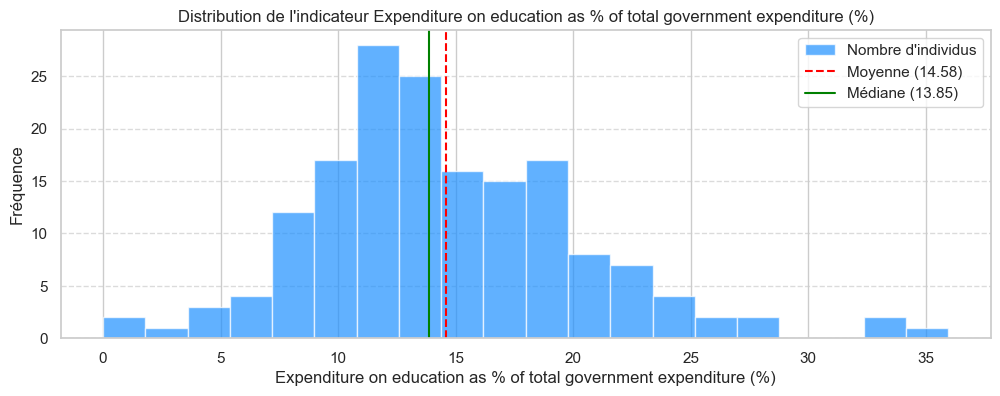

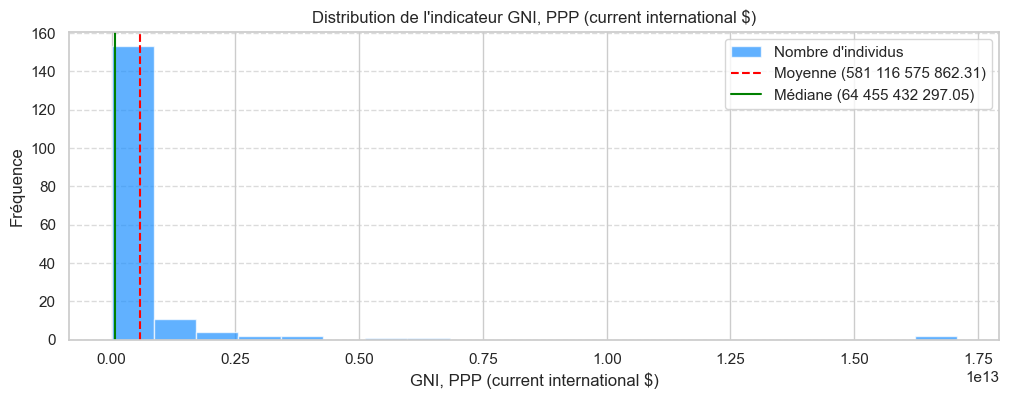

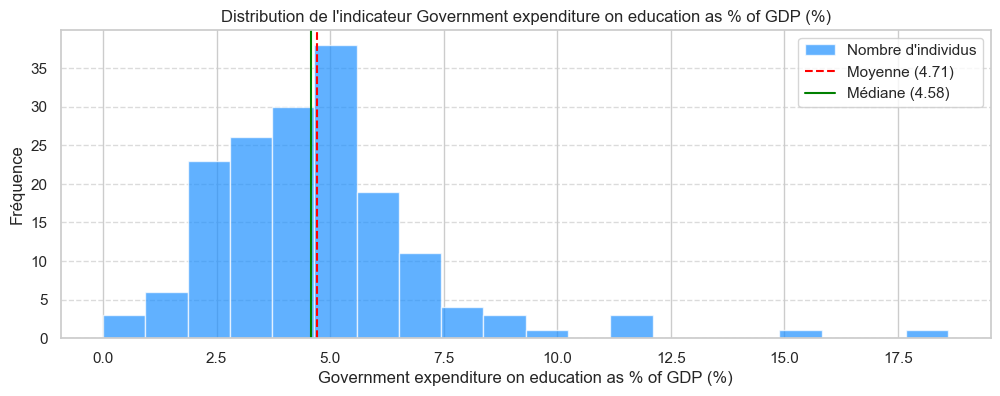

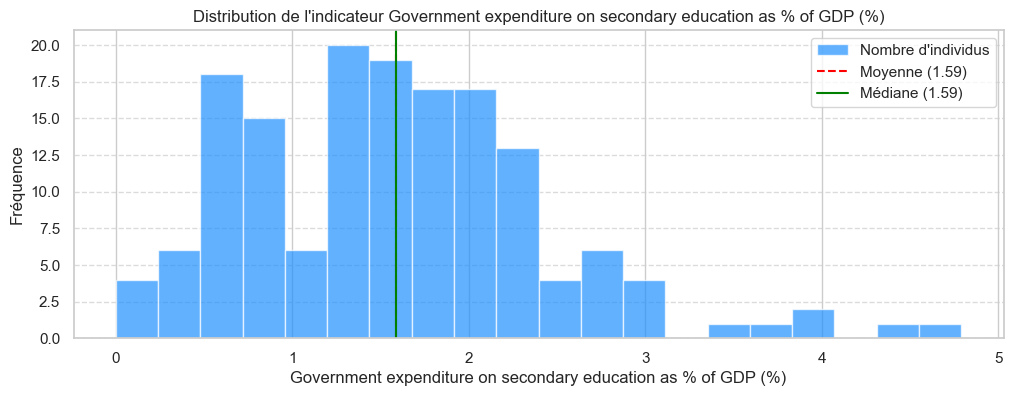

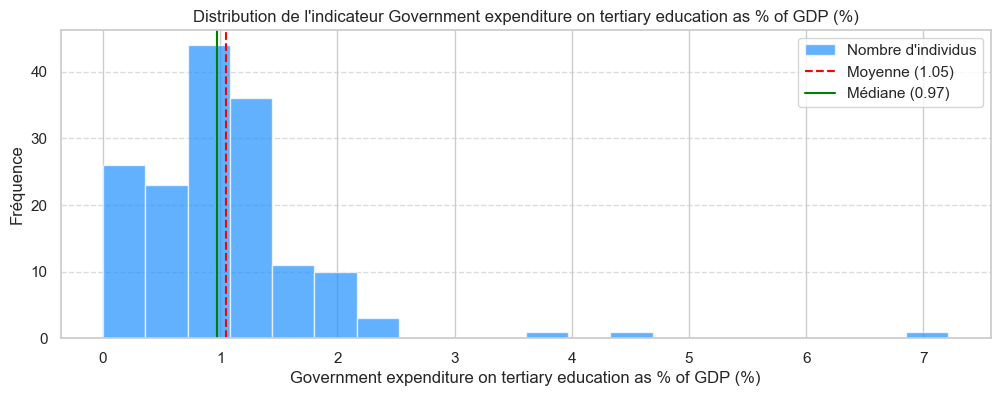

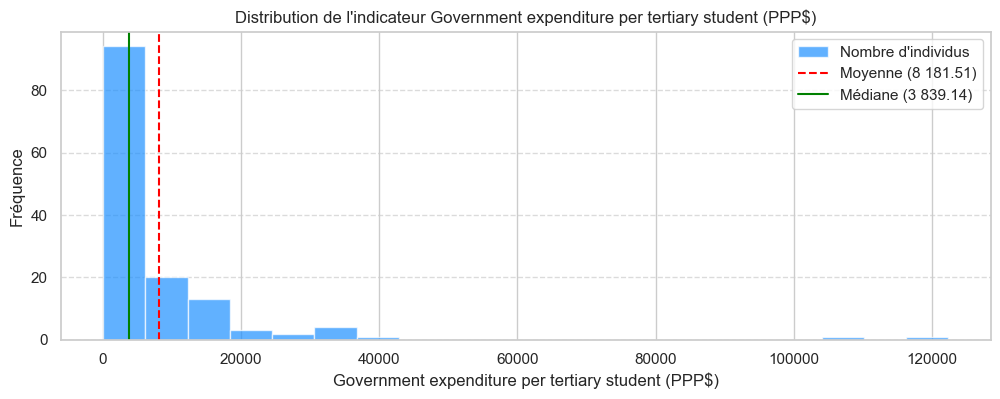

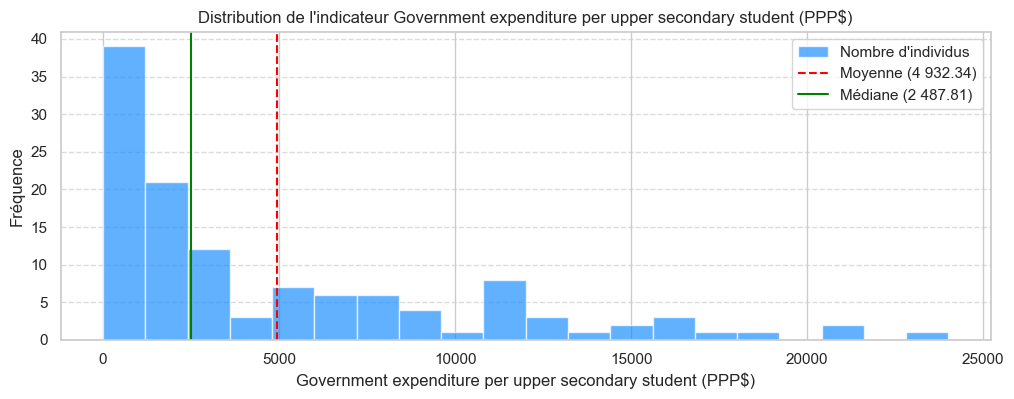

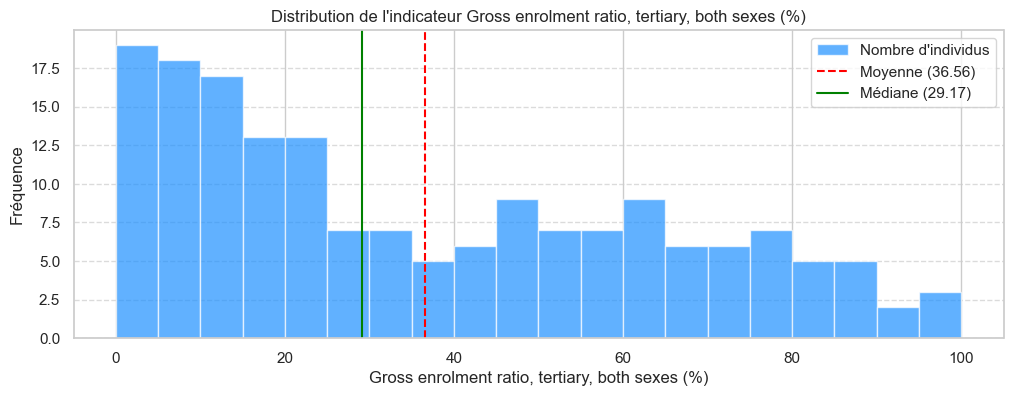

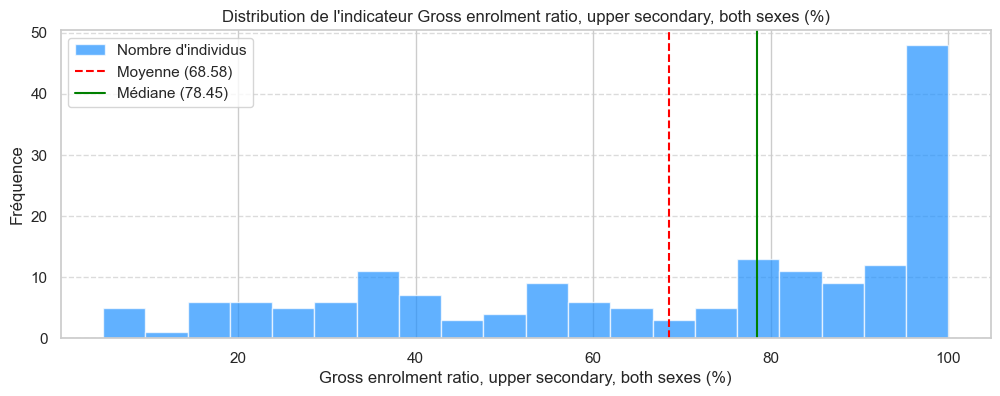

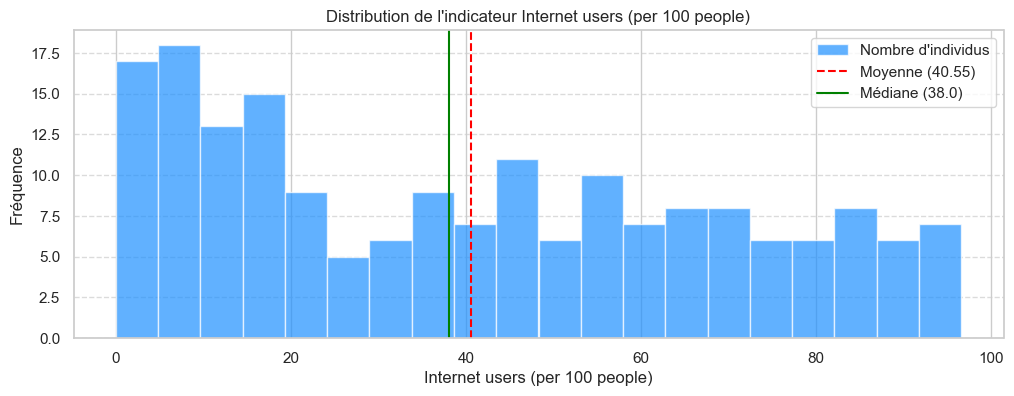

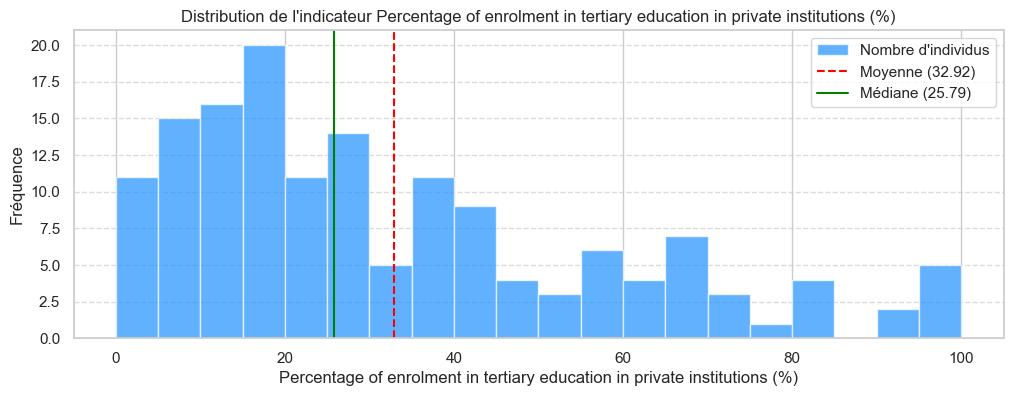

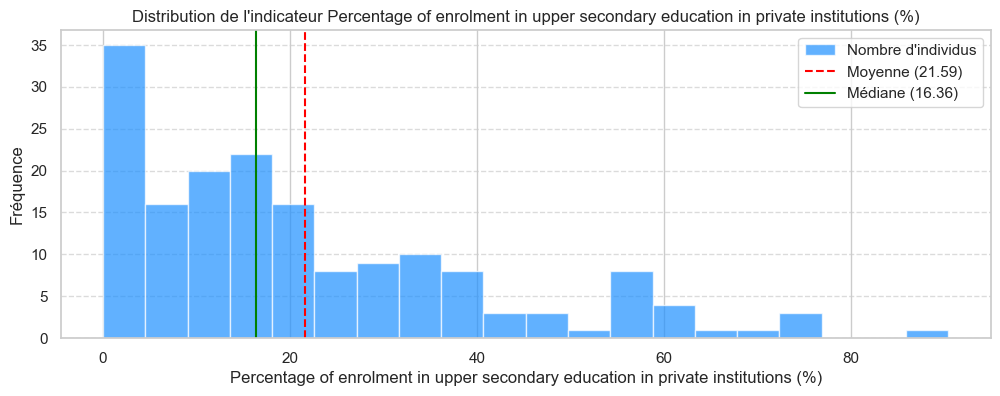

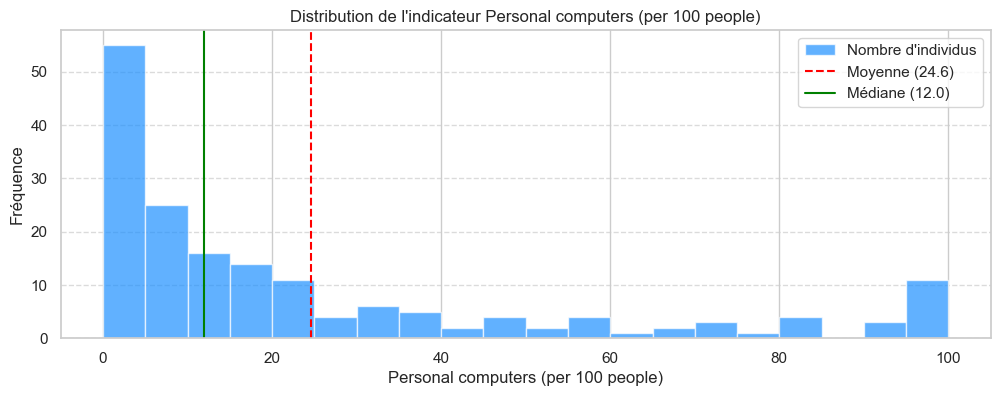

In [178]:
# Application d'un thème Seaborn
sns.set_theme(style="whitegrid")

# Histogramme pour chaque indicateur numérique avec indicateurs de médiane et moyenne
for col in df_2013.select_dtypes(include=["float64"]).columns:
    plt.figure(figsize=(12, 4))
    
    # Histogramme
    plt.hist(df_2013[col].dropna(), bins=20, alpha=0.7, color="dodgerblue", label="Nombre d'individus")
    
    # Calcul de la moyenne et de la médiane
    mean_val = round(df_2013[col].mean(),2)
    median_val = round(df_2013[col].median(),2)
    
    # Ligne verticale pour la moyenne
    plt.axvline(mean_val, color="red", linestyle="--", linewidth=1.5, label=f"Moyenne ({mean_val:,})".replace(","," "))
    
    # Ligne verticale pour la médiane
    plt.axvline(median_val, color="green", linestyle="-", linewidth=1.5, label=f"Médiane ({median_val:,})".replace(","," "))
    
    # Titre et axes
    plt.title(f"Distribution de l'indicateur {col}")
    plt.xlabel(col)
    plt.ylabel("Fréquence")
    plt.grid(axis="y", linestyle="--", alpha=0.7)
    
    # Ajout d'une légende
    plt.legend()
    
    # Affichage
    plt.show()

##### B) Boîtes à moustaches

En plus des histogrammes, il sera utile de présenter nos indicateurs sous forme de boxplots, afin d'identifier les valeurs aberrantes et comparer les distributions par zone géographique.

Pour la suite des visualisations, on se concentrera uniquement sur des indicateurs clés, concernant les taux d'inscription, les budget des gouvernements investis dans l'éducation, et la connectivité des populations à Internet.

In [181]:
key_indicators = ["Gross enrolment ratio, upper secondary, both sexes (%)",
                  "Gross enrolment ratio, tertiary, both sexes (%)",
                  "Government expenditure on education as % of GDP (%)",
                  "Internet users (per 100 people)"]

In [182]:
# Création d'une fonction get_boxplot pour visualiser chaque indicateur, groupé par région
def get_boxplot(col):
    plt.figure(figsize=(12, 6))
    sns.boxplot(x="Region", y=col, data=df_2013, hue="Region", palette="Set2")
    plt.title(f"Répartition de l'indicateur {col} par région")
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis="y", linestyle="--", alpha=0.7)
    plt.show()

- **Taux d'inscription dans l'enseignement secondaire**

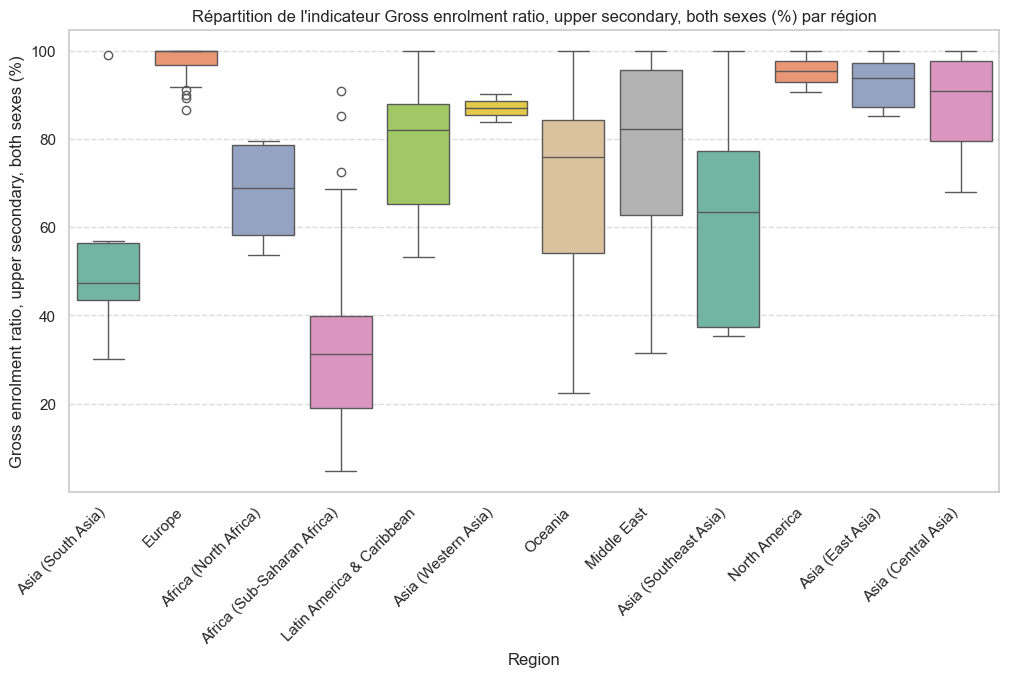

In [184]:
get_boxplot(key_indicators[0])

1) **Régions avec des taux d'inscription élevés :**

Europe :
- La médiane avoisine 100 %, ce qui reflète un accès quasi-universel à l'enseignement secondaire supérieur.
- Les boîtes sont courtes (faible dispersion), montrant une homogénéité élevée dans les pays européens.

North America :
- Une médiane élevée, proche de 95 %, avec peu de dispersion.
- Cela reflète une forte accessibilité et une homogénéité dans les politiques éducatives.

East Asia & Central Asia :
- Médiane élevée, autour de 90 %, avec une dispersion faible, mais plus importante pour l'Asie Centrale.
- Cela suggère un fort accès à l'éducation secondaire dans cette région.

2) **Régions avec des taux faibles :**

Sub-Saharan Africa :
- Médiane très basse, proche de 30 %, avec une large dispersion.
- Cela reflète de grandes disparités dans la région, où certains pays ont un accès quasi inexistant à l'enseignement secondaire supérieur.

South Asia :
- Médiane en dessous de 50 %, avec une certaine dispersion.
- Cela indique une mixité dans l'accès à l'enseignement secondaire, mais un accès plutôt bas.

3) **Régions avec des variations significatives :**

Latin America, Caribbean & Middle East :
- Médiane autour de 80 %, mais avec une large boîte et des moustaches longues.
- Cela indique des écarts entre les pays de cette région, certains ayant un accès quasi-universel, d'autres restant en retard.

Oceania & Southeast Asia:
- Médiane autour de 70 %, mais avec une large gamme de valeurs.
- Cela reflète des progrès éducatifs dans certains pays, mais des disparités entre eux.

4) **Implications :**

- **Régions matures pour Academy :** Europe, North America et East Asia

Ces régions ont des taux d'inscription élevés et homogènes, montrant une forte intégration des politiques éducatives.
Elles représentent des marchés matures, mais potentiellement saturés pour des solutions traditionnelles. *Academy* pourrait se concentrer sur des offres spécialisées (éducation numérique, apprentissage hybride).

- **Régions émergentes :** Latin America & Caribbean et Middle East

Ces régions montrent une progression dans l'accès à l'éducation secondaire, mais avec des écarts significatifs entre les pays.
Elles représentent un bon potentiel pour *Academy*, en proposant des solutions adaptées aux pays avec des taux d'inscription faibles.

- **Régions en développement :** Sub-Saharan Africa et North Africa

Ces régions ont des taux d'inscription faibles, reflétant des défis structurels (manque d'infrastructures, inégalités sociales).
*Academy* pourrait cibler ces régions avec des solutions abordables et accessibles, en complément des systèmes éducatifs existants.

5. **Recommandations pour *Academy* :**

- Focus sur les régions émergentes :

Latin America & Caribbean et Middle East montrent des taux d'inscription croissants avec des inégalités internes. Ces pays pourraient bénéficier de plateformes d'apprentissage numériques adaptées.

- Stratégies adaptées pour les régions en développement :

Explorer les possibilités dans Sub-Saharan Africa et North Africa, mais en tenant compte des défis logistiques (connexion Internet, matériel éducatif).
Des solutions mobiles ou à faible coût pourraient être particulièrement pertinentes.

- Offres spécialisées pour les marchés matures :

Proposer des contenus éducatifs innovants ou avancés pour les marchés saturés comme Europe et North America.
___

- **Taux d'inscription dans l'enseignement tertiaire**

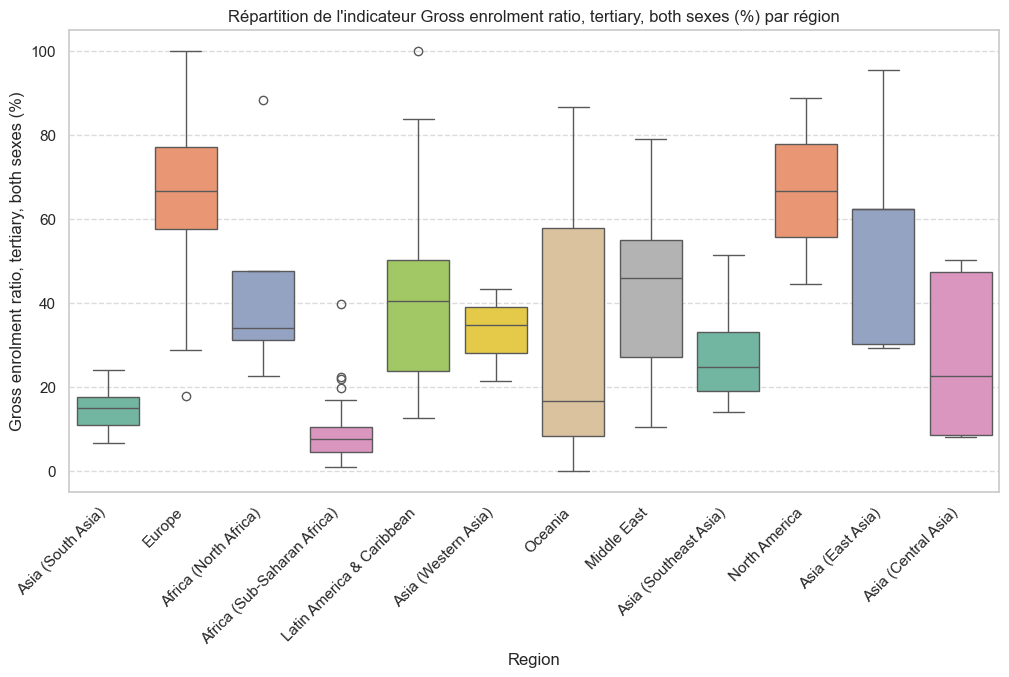

In [187]:
get_boxplot(key_indicators[1])

1. **Régions avec des taux d'inscription élevés :**

Europe :

- Médiane très élevée, avoisinant 70 %, avec une large dispersion.
- Reflète un taux d'inscription élevée dans la plupart des pays européens, où l'accès à l'enseignement supérieur est bien développé.

North America :

- Médiane également élevée, proche de 70 %, avec une faible dispersion.
- Cela montre un accès largement accessible à l'éducation tertiaire.

East Asia :

- Médiane élevée (environ 60 %), avec une dispersion légèrement plus importante.
- Cela montre que la majorité des pays de cette région ont un bon accès à l'enseignement supérieur.

2. **Régions avec des taux faibles :**

Africa (Sub-Saharan Africa) :

- Médiane très basse, proche de 10 %, avec une dispersion modérée.
- Reflète les défis structurels importants pour l'accès à l'enseignement supérieur.

South Asia :

Médiane autour de 15 %, indiquant des efforts en cours, mais un accès encore limité pour de nombreux pays.

3. **Régions avec une variabilité importante :**

Latin America & Caribbean :

- Médiane autour de 40 %, mais avec une large dispersion.
- Cela reflète des écarts importants entre les pays de la région.

Oceania :

- Médiane basse (environ 15 %), mais avec une forte variabilité.
- Cela pourrait refléter des spécificités locales.

4. **Implications :**

- **Régions matures pour *Academy* :** Europe, North America, et East Asia

Ces régions, avec des taux élevés et homogènes, représentent des marchés matures pour l'enseignement supérieur. *Academy* pourrait y introduire des produits éducatifs avancés ou spécialisés.

- **Régions émergentes :** Latin America & Caribbean

Cette région montre une progression dans l'accès à l'enseignement supérieur, mais avec des écarts significatifs entre les pays. *Academy* pourrait se concentrer sur les pays ayant des taux prometteurs.

- **Régions en développement :**

Sub-Saharan Africa : Les taux d'inscription très faibles montrent des besoins éducatifs majeurs. *Academy* pourrait proposer des solutions accessibles, comme des plateformes mobiles ou des cours en ligne abordables.

South Asia : Cette région représente un potentiel intéressant pour *Academy*, car l'accès à l'éducation tertiaire est en amélioration, bien qu'encore limité.

5. **Recommandations pour *Academy* :**

- Consolider les offres dans les marchés matures :

Focus sur Europe, Amérique du Nord, et Asie de l'Est avec des produits avancés ou spécialisés.

- Cibler les régions émergentes :

Exploiter les opportunités en Amérique Latine & Caraïbes et Océanie en proposant des solutions adaptées aux besoins locaux.

- Soutenir les régions en développement :

Développer des solutions éducatives accessibles pour des régions comme l'Afrique Sub-Saharienne, en tenant compte des défis structurels.
___

- **Dépenses publiques en éducation en pourcentage du PIB (%)**

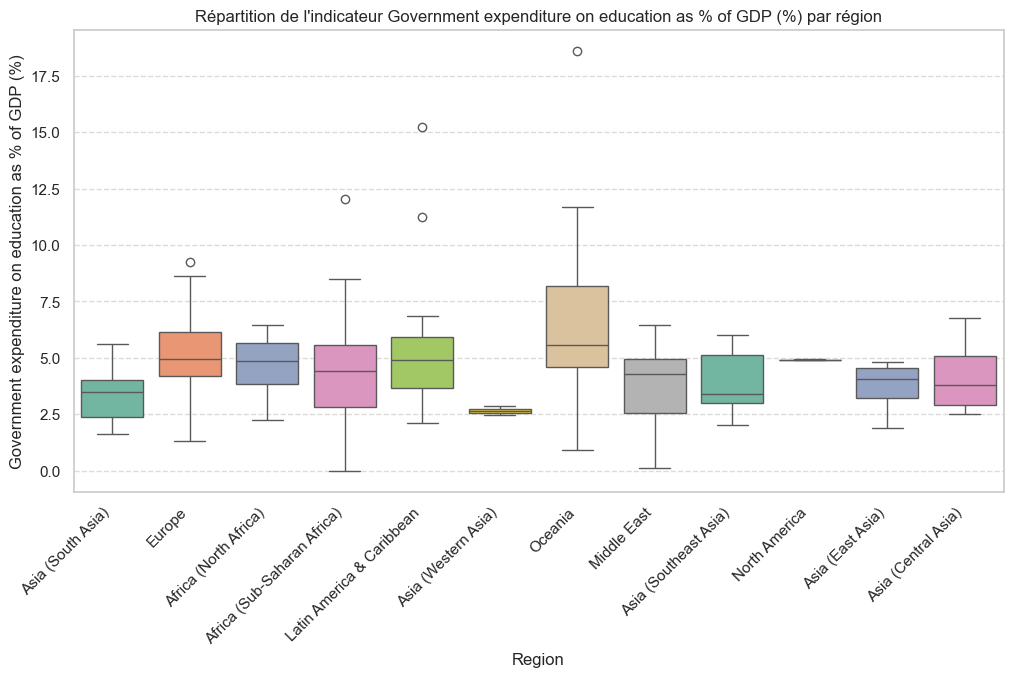

In [190]:
get_boxplot(key_indicators[2])

1. **Régions avec des dépenses élevées :**

Oceania :

- La médiane est la plus élevée, proche de 6 %, avec des valeurs allant jusqu'à 12 %.
- Une grande dispersion et des outliers au-delà de 15 % indiquent des disparités dans les efforts de financement parmi les pays de cette région.

Europe et Sub-Saharan Africa :

- Médianes relativement élevées (5 %) avec une dispersion modérée.
- Cela montre que certains pays de ces régions consacrent une part significative de leur PIB à l'éducation, malgré leurs défis économiques.

Latin America & Caribbean et North Africa : 

- Médianes proches de 5 %, similaires à Europe, mais avec une dispersion légèrement plus faible.

2. **Régions avec des dépenses modérées :**

Middle East :

- Médiane proche de 4 %, avec une faible dispersion.
- Les pays de cette région consacrent une part relativement modérée de leur PIB à l'éducation.

South Asia et Central Asia:

- Médianes autour de 3,5 %, avec une dispersion modérée.
- Cela indique un effort modéré dans ces régions.

3. **Régions avec des dépenses faibles :**

Western Asia :

- Médiane la plus basse, autour de 2,5 %, avec une faible dispersion.
- Cela indique un effort limité pour financer l'éducation dans cette région, probablement en raison de contraintes économiques.

Southeast Asia et East Asia :

- Médianes similaires à Western Asia (~2,5 % à 3 %), avec une faible dispersion.
- Ces régions consacrent également une part limitée de leur PIB à l'éducation.

4. **Implications :**

- **Régions avec un fort engagement financier :**

Oceania : Avec une médiane élevée (~6 %) et une grande dispersion, cette région montre un engagement significatif pour l'éducation. Cependant, les disparités suggèrent que certains pays investissent beaucoup plus que d'autres.

Europe et Sub-Saharan Africa : Ces régions consacrent une part notable de leur PIB à l'éducation (~5 %), montrant une priorité importante donnée à ce secteur. L'Afrique Sub-Saharienne, bien que confrontée à des défis structurels majeurs, démontre un fort engagement, ce qui souligne l’importance de l’éducation dans les stratégies de développement.

Latin America & Caribbean et North Africa : Avec des médianes proches de 5 %, ces régions montrent une certaine homogénéité et un effort stable pour financer l’éducation, bien qu’avec une dispersion plus faible que l’Europe.

- **Régions avec un engagement modéré :**

Middle East : Avec une médiane autour de 4 % et une faible dispersion, cette région semble maintenir un engagement modéré et cohérent envers le financement de l’éducation. Cela pourrait refléter des priorités concurrentes (infrastructures, sécurité, etc.) ou des contraintes budgétaires.

South Asia et Central Asia : Ces régions montrent des médianes d’environ 3,5 %, reflétant un effort modéré pour financer l’éducation. La dispersion modérée indique une certaine variabilité entre les pays. Cela suggère que certains pays investissent de manière significative, tandis que d’autres consacrent moins de ressources à l’éducation.

- **Régions avec un faible engagement financier :**

Western Asia :Avec une médiane autour de 2,5 %, cette région montre un engagement limité pour l’éducation, probablement en raison de priorités budgétaires différentes ou de contraintes économiques.

Southeast Asia et East Asia :
Ces régions présentent des médianes similaires à Western Asia (~2,5 % à 3 %), reflétant des priorités budgétaires limitées pour l’éducation.
La faible dispersion indique que la majorité des pays de ces régions consacrent une part comparable et relativement faible de leur PIB à l’éducation.

5. **Recommandations pour *Academy* :**

- Focus sur les régions avec des dépenses élevées :

L'Océanie, l'Europe, et l'Afrique Sub-Saharienne montrent un fort engagement financier. *Academy* pourrait collaborer avec ces régions pour introduire des solutions complémentaires ou ciblées, telles que l’apprentissage hybride ou des contenus spécialisés.

- Cibler les régions avec un engagement modéré :

Le Moyen-Orient, L'Asie du Sud, et L'Asie Centrale représentent des marchés stables mais variés. *Academy* pourrait offrir des solutions adaptées à ces contextes, telles que des programmes abordables ou une infrastructure numérique éducative.

- Opportunités dans les régions à faibles dépenses :

Dans des régions comme l'Asie de l'Ouest, du Sud et de l'Est, *Academy* pourrait développer des solutions économiques pour maximiser l’impact dans des environnements avec un financement limité.
___

- **Utilisateurs d'Internet (pour 100 personnes)**

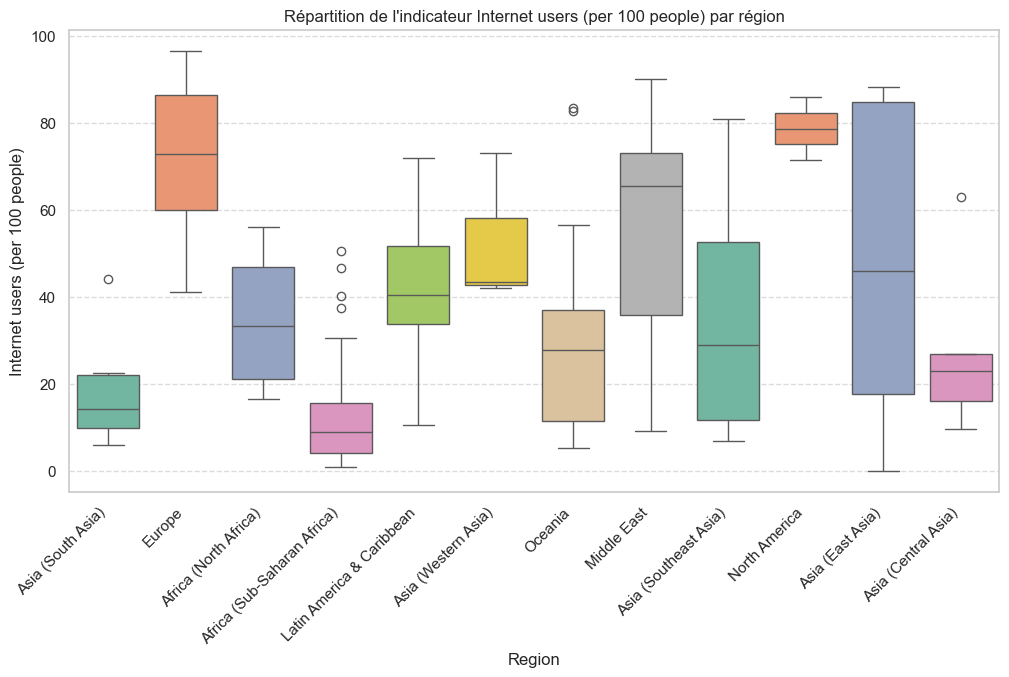

In [193]:
get_boxplot(key_indicators[3])

1. **Régions avec une forte adoption d'Internet :**

Europe :

- Médiane très élevée (~75 %), avec une dispersion modérée.
- Cela reflète une adoption élevée d'Internet dans la région.

North America :

- Médiane également élevée (~80 %), avec peu de variabilité.
- Cela reflète une forte connectivité et un accès généralisé à Internet.

Middle East :

- Médiane proche de 65 %, avec une forte dispersion.
- Cela reflète une adoption croissante mais encore modérée de l’Internet dans cette région.


2. **Régions avec une adoption modérée d'Internet :**

East Asia :

- Médiane proche de 45 %, avec une très forte dispersion.
- Cela montre une plutôt bonne adoption d’Internet dans la région, bien qu’avec de nombreuses disparités internes.

Latin America & Caribbean et Western Asia :

- Médiane autour de 40 %, avec une dispersion importante.
- Cela montre que certains pays de la région ont une connectivité bien développée, tandis que d'autres accusent un retard.

Southesast Asia et Oceania :

- Médianes proches de 30 %, indiquant une adoption en cours mais encore limitée.
- Les moustaches longues montrent une forte disparité entre les pays.


3. **Régions avec une faible adoption d'Internet :**

Sub-Saharan Africa :

- Médiane très basse (~10 %), avec une large dispersion et plusieurs outliers.
- Cela montre les défis importants liés à l’accès à Internet dans cette région.

South Asia et Central Asia :

- Médianes respectivement autour de 15 % et 25 %, avec peu de dispersion.
- Ces régions montrent également un faible accès à Internet, mais avec une progression plus homogène.

4. **Implications :**

- **Régions avec une forte connectivité :**

Europe et North America : Avec des médianes élevées (~75-80 %) et une dispersion modérée, ces régions représentent des marchés matures pour des solutions éducatives numériques avancées. Les infrastructures bien développées favorisent des services hautement interactifs.

Middle East : Une médiane proche de 65 % et une forte dispersion indiquent une connectivité croissante mais inégale.
Cela reflète des écarts significatifs entre les pays de la région, offrant des opportunités pour des solutions éducatives ciblées.

- **Régions en transition :**

East Asia : La médiane modérée (~45 %) mais une très forte dispersion montrent une adoption d’Internet en progression, mais inégale entre les pays.
*Academy* pourrait adapter ses solutions pour répondre aux besoins des pays les moins connectés.

Latin America & Caribbean et Western Asia : Avec des médianes autour de 40 % et des dispersions importantes, ces régions présentent un potentiel de croissance, mais des défis logistiques persistent dans les pays en retard.

Southeast Asia et Oceania : Des médianes proches de 30 % avec de longues moustaches montrent une connectivité limitée dans certains pays, mais des poches d’opportunités dans les plus avancés.

- **Régions avec une connectivité limitée :**

Sub-Saharan Africa :Avec une médiane très basse (~10 %) et une large dispersion, cette région montre des défis structurels importants liés à l’accès à Internet.

South Asia et Central Asia : Médianes de 15 % à 25 % et faible dispersion indiquent une connectivité limitée mais homogène.

5. **Recommandations pour Academy :**

- Focus sur les marchés matures :

L'Europe, l'Amérique du Nord, et le Moyen-Orient offrent des opportunités pour des produits éducatifs avancés et interactifs, capitalisant sur leur forte connectivité.

- Cibler les régions en transition :

Adapter les solutions pour l'Asie de l'Est, l'Amérique Latine & Caraïbes, et L'Asie de l'Ouest, où la connectivité progresse mais reste inégale entre les pays.

- Soutenir les régions à connectivité limitée :

Prioriser des plateformes hybrides ou à faible bande passante pour des régions comme l'Afrique Sub-Saharienne, l'Asie du Sud, et l'Asie Centrale, en ciblant leurs besoins spécifiques.
___

#### 4.2.3. Sélection des trois régions prioritaires pour *Academy*

En prenant en compte les quatre analyses, les trois régions sélectionnées sont basées sur l'adoption des technologies, les dépenses publiques en éducation, et les opportunités de croissance dans des marchés émergents ou matures.

1. **Europe**

Justification :
- Taux d'inscription élevés dans l'enseignement secondaire et tertiaire, avec une homogénéité remarquable.
- Adoption d'Internet élevée (~75 %) et infrastructures bien développées.
- Dépenses publiques significatives en éducation (~5 % du PIB), reflétant un fort engagement pour l'éducation.
- **Potentiel pour *Academy* :** Europe est un marché mature, idéal pour des solutions éducatives avancées, comme l'apprentissage hybride ou des outils numériques spécialisés. C’est une région où Academy peut innover avec des produits haut de gamme.

2. **Latin America & Caribbean**

Justification :
- Taux d'inscription modérés dans l'enseignement secondaire (\~80 %) et tertiaire (\~40 %), mais avec des disparités importantes, indiquant un potentiel de croissance.
- Adoption d'Internet en progression (~40 %), mais avec des écarts significatifs entre les pays.
- Dépenses publiques en éducation respectables (~5 % du PIB), bien que légèrement inférieures à celles de l'Europe.
- **Potentiel pour *Academy* :** Cette région est en transition. Academy pourrait se concentrer sur des pays prometteurs avec des taux d'inscription et d'adoption d'Internet en croissance. Les solutions éducatives numériques abordables et adaptables y seraient particulièrement pertinentes.

3. **Middle East**

Justification :
- Taux d'inscription variés, mais souvent modérés dans le secondaire et le tertiaire, indiquant un potentiel pour des améliorations éducatives.
- Adoption d'Internet croissante (~65 %), avec des disparités importantes entre les pays.
- Dépenses publiques modérées (~4 % du PIB), mais cohérentes, indiquant une stabilité régionale.
- **Potentiel pour *Academy* :** Le Moyen-Orient représente un marché émergent où Academy pourrait proposer des solutions numériques adaptées aux pays les moins connectés, tout en capitalisant sur les marchés avec une connectivité plus élevée.

**Pourquoi pas d'autres régions ?**

- **North America :** Bien que le marché soit mature, il est déjà saturé et présente peu d’opportunités de croissance pour une entreprise émergente comme Academy.

- **Sub-Saharan Africa :** Bien que cette région ait des besoins éducatifs importants, les faibles taux d'inscription, la connectivité limitée (\~10 %), et les faibles dépenses publiques (~3-4 % du PIB) rendent son développement plus complexe et risqué à court terme.

- **East Asia et Southeast Asia :** Ces régions présentent des opportunités, mais les disparités internes et la faible connectivité (~30-45 %) limitent l'impact immédiat des solutions numériques.

**Conclusion et Stratégie**

- **Europe :** Se concentrer sur des offres spécialisées dans les pays matures.
- **Latin America & Caribbean :** Cibler les pays émergents avec des solutions éducatives numériques abordables et adaptables.
- **Middle East :** Développer des solutions ciblées pour les pays connectés tout en soutenant ceux ayant une bonne évolution en matière de connectivité.

In [197]:
# Liste des régions à conserver
regions_to_keep = ["Europe", "Latin America & Caribbean", "Middle East"]

# Filtrage du DataFrame pour garder uniquement les régions sélectionnées
df_regions = df[df["Region"].isin(regions_to_keep)]

# Affichage du nombre de pays restants
for region in regions_to_keep:
    num_countries = df_regions[df_regions["Region"] == region]["Country Name"].nunique()
    print(f"{region} : {num_countries}")
print(f"Total : {df_regions["Country Name"].nunique()}")

# Affichage quelques lignes du DataFrame filtré
df_regions

Europe : 41
Latin America & Caribbean : 29
Middle East : 15
Total : 85


,Year,Country Name,Expenditure on education as % of total government expenditure (%),"GNI, PPP (current international $)",Government expenditure on education as % of GDP (%),Government expenditure on secondary education as % of GDP (%),Government expenditure on tertiary education as % of GDP (%),Government expenditure per tertiary student (PPP$),Government expenditure per upper secondary student (PPP$),"Gross enrolment ratio, tertiary, both sexes (%)","Gross enrolment ratio, upper secondary, both sexes (%)",Internet users (per 100 people),Percentage of enrolment in tertiary education in private institutions (%),Percentage of enrolment in upper secondary education in private institutions (%),Personal computers (per 100 people),Region
0,1999,Albania,9.682460,1.172813e+10,3.376690,0.701640,0.775850,1275.984863,393.939270,14.805040,42.998322,0.081437,0.000000,1.581713,0.602783,Europe
2,1999,Andorra,NaN,NaN,1.245302,0.134570,0.069133,NaN,NaN,NaN,NaN,7.635686,0.000000,7.764134,NaN,Europe
4,1999,Antigua and Barbuda,12.521430,1.112886e+09,3.237070,1.206810,0.487620,3387.596436,NaN,0.000000,80.307414,5.300681,100.000000,26.768594,5.380454,Latin America & Caribbean
6,1999,Argentina,15.880090,4.199618e+11,4.514080,1.668810,0.775080,3159.864990,4165.083984,47.976479,68.188538,3.284482,20.827366,29.629200,5.751131,Latin America & Caribbean
10,1999,Austria,11.246640,2.171441e+11,6.137950,2.746160,1.603980,14068.289062,7621.854004,54.517609,96.236794,23.044317,6.640750,9.718800,28.721842,Europe
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7559,2030,United Kingdom,14.410069,3.763122e+12,7.545234,3.087984,1.567526,18637.966803,4259.168108,54.044324,100.000000,100.000000,100.000000,73.471492,100.000000,Europe
7562,2030,Uruguay,25.008882,1.094547e+11,7.140026,2.125967,1.958008,3264.295243,853.551224,90.888112,67.123003,100.000000,26.632949,21.509009,28.418724,Latin America & Caribbean
7565,2030,"Venezuela, RB",100.000000,9.111610e+11,30.771100,6.240753,0.399899,3453.311035,15080.671413,100.000000,100.000000,100.000000,2.228268,31.250596,30.732297,Latin America & Caribbean
7570,2030,"Yemen, Rep.",0.000000,1.297926e+11,0.000000,0.855120,NaN,NaN,NaN,10.677587,33.566258,46.574100,49.261450,7.200766,11.667224,Middle East


### 4.3. Analyse bivariée

#### 4.3.1. Corrélations entre indicateurs

##### **A) Calcul des corrélations linéaires**

In [201]:
# Calcul de la matrice de corrélation
cor_matrix = round(df_regions.loc[df_regions["Year"]==2013,key_indicators].corr(), 2)

# Affichage la matrice de corrélation
cor_matrix

,"Gross enrolment ratio, upper secondary, both sexes (%)","Gross enrolment ratio, tertiary, both sexes (%)",Government expenditure on education as % of GDP (%),Internet users (per 100 people)
"Gross enrolment ratio, upper secondary, both sexes (%)",1.00,0.70,0.24,0.69
"Gross enrolment ratio, tertiary, both sexes (%)",0.70,1.00,0.33,0.48
Government expenditure on education as % of GDP (%),0.24,0.33,1.00,0.04
Internet users (per 100 people),0.69,0.48,0.04,1.00


##### **B) Visualisation avec une matrice de corrélation**

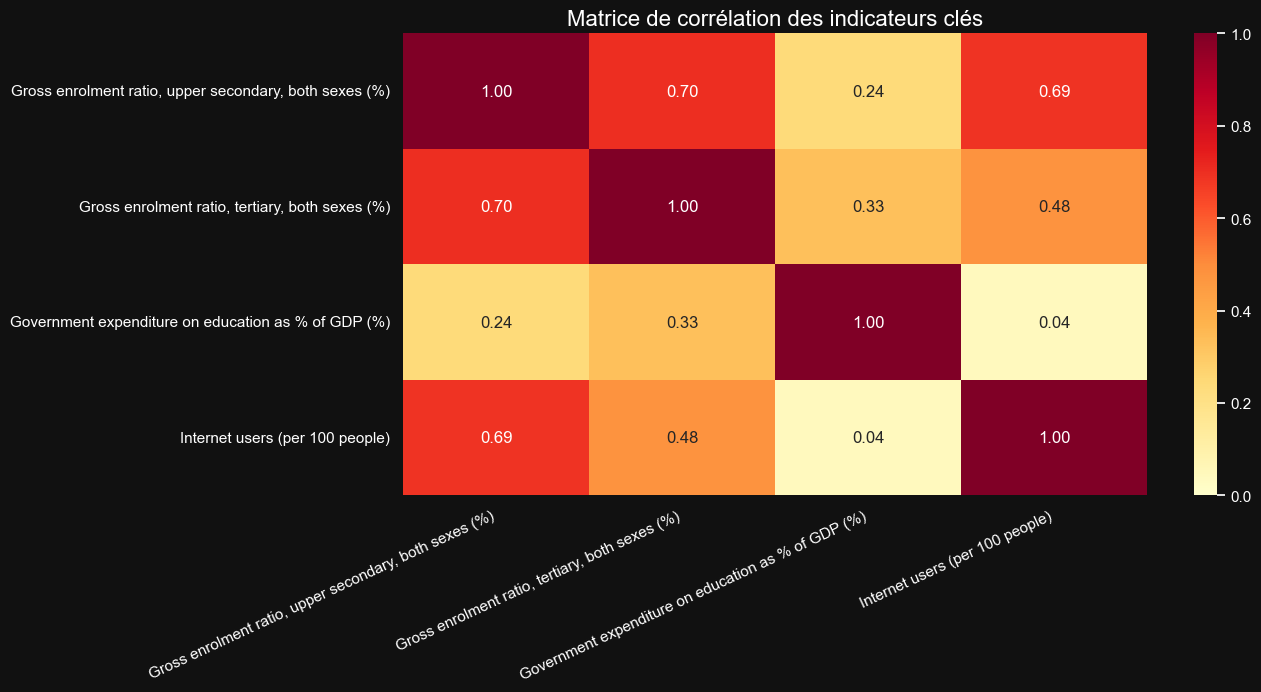

In [203]:
# Heatmap de la matrice de corrélation
plt.figure(figsize=(12, 6), facecolor="#111111")
heatmap = sns.heatmap(cor_matrix, 
            annot=True,                # Affiche les valeurs numériques
            cmap="YlOrRd",           # Palette de couleurs
            fmt=".2f",                 # Format des valeurs affichées
            cbar=True,                 # Afficher la barre de couleur
            vmin=0,                    # Minimum de l'échelle à 0
            vmax=1                     # Maximum de l'échelle à 1
           )

# Change la couleur des graduations et labels de la colorbar
cbar = heatmap.collections[0].colorbar  # Accès à la colorbar
cbar.ax.yaxis.set_tick_params(color="white")  # Couleur des ticks (graduations)
plt.setp(cbar.ax.yaxis.get_majorticklabels(), color="white")  # Couleur des labels des ticks

plt.title("Matrice de corrélation des indicateurs clés", color="white", fontsize=16)
plt.xticks(color="white", rotation=25, ha="right")
plt.yticks(color="white")
plt.show()

##### **C) Interprétation des résultats**

Corrélation entre les taux d'inscription (enseignement secondaire et tertiaire) :

- **0.70 :** Il existe une corrélation positive modérée entre le taux d'inscription au secondaire et au tertiaire.
- **Interprétation :** Les pays ayant un fort taux d'inscription au secondaire ont également tendance à avoir un bon taux d'inscription au tertiaire.

Corrélation entre le taux d'inscription tertiaire et les utilisateurs d'Internet :

- **0.48 :** Une corrélation positive modérée indique que l'accès à Internet est un facteur favorable à l'enseignement tertiaire.
- **Interprétation :** Les pays ayant une connectivité Internet élevée tendent à avoir un accès amélioré à l'enseignement supérieur.

Corrélation entre le taux d'inscription secondaire et les utilisateurs d'Internet :

- **0.69 :** Une corrélation positive modérée est également observée entre ces deux indicateurs.
- **Interprétation :** L'accès à Internet semble également jouer un rôle dans l'accès à l'enseignement secondaire.

Corrélation entre les dépenses publiques en éducation et les autres indicateurs :

- **Faibles corrélations avec les autres variables :**
  - 0.33 avec le taux d'inscription tertiaire.
  - 0.24 avec le taux d'inscription secondaire.
  - 0.04 avec les utilisateurs d'Internet.
- **Interprétation :** Les dépenses publiques en éducation ne semblent pas être fortement liées à ces indicateurs. Cela peut indiquer que d'autres facteurs (infrastructure, politiques éducatives, etc.) jouent un rôle important.

#### 4.3.2. Représentations visuelles bivariées

##### **A) Nuages de points**

L'objectif d'une représentation à l'aide d'un nuage de points est de visualiser la relation entre deux variables quantitatives et de voir, si une relation existe, la forme de celle-ci (linéaire, non-linéaire ou inexistante). 

Dans notre matrice de corrélation précédente, nous avions pu constater qu'une corrélation semblait fortement exister entre le taux d'inscription tertiaire et le pourcentage de la population utilisatrice d'Internet. Nous allons donc nous pencher sur ce cas et représenter le nuage de point de ces deux indicateurs à partir du dataframe de l'année 2013.

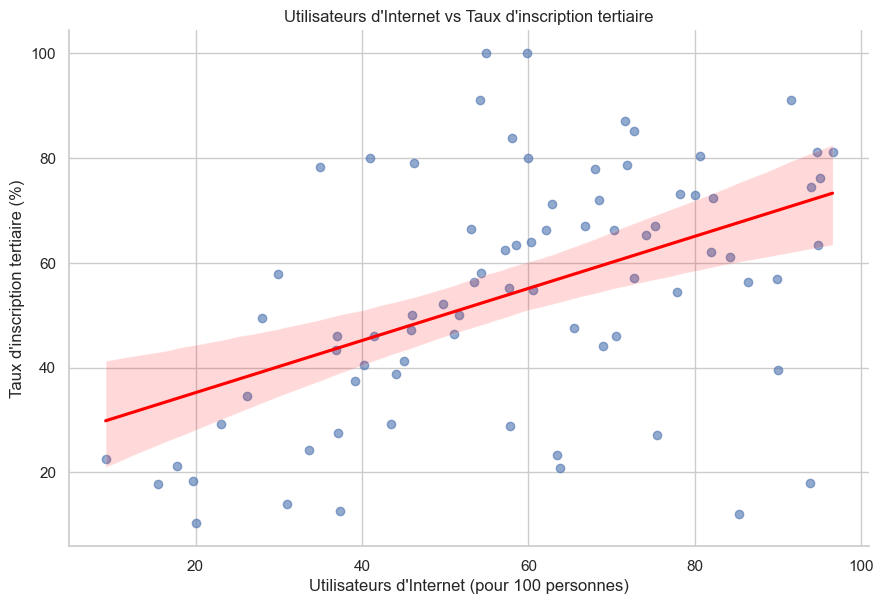

In [209]:
# Relation entre le taux d'inscription secondaire et les utilisateurs d'Internet
sns.lmplot(x="Internet users (per 100 people)", 
           y="Gross enrolment ratio, tertiary, both sexes (%)", 
           data=df_regions.loc[df_regions["Year"]==2013], 
           height=6,                        # hauteur 
           aspect=1.5,                      # rapport hauteur/largeur
           line_kws={"color": "red"},       # personnalise la droite de régression
           scatter_kws={"alpha": 0.6})      # personnalise les points du nuage avec une opacité de 60 %.
plt.title("Utilisateurs d'Internet vs Taux d'inscription tertiaire")
plt.xlabel("Utilisateurs d'Internet (pour 100 personnes)")
plt.ylabel("Taux d'inscription tertiaire (%)")
plt.show()

Ce graphique illustre la relation entre le nombre d'utilisateurs d'Internet (par 100 personnes) (axe des abscisses) et le taux d'inscription tertiaire (%) (axe des ordonnées). Voici une interprétation succincte :

- **Relation positive modérée :**

La pente de la droite rouge indique une corrélation positive : à mesure que le nombre d'utilisateurs d'Internet augmente, le taux d'inscription à l'enseignement tertiaire tend également à augmenter.

Cela suggère que l'accès à Internet pourrait être un facteur facilitant ou complémentaire à l'accès à l'éducation supérieure.

- **Dispersion modérée :**

Les points ne sont pas parfaitement alignés autour de la droite de régression, ce qui reflète une variabilité. Cela indique que d'autres facteurs (en plus de l'accès à Internet) influencent le taux d'inscription tertiaire.

- **Zone d'incertitude :**

La zone rouge (intervalle de confiance) est plus large aux extrémités (faible ou forte utilisation d'Internet), ce qui reflète une plus grande incertitude dans ces plages.

- **Observation globale :**

La relation positive et les tendances observées justifient l'idée que des initiatives d'amélioration de l'accès à Internet pourraient également stimuler l'éducation supérieure dans certaines régions.

**Conclusion :**

L'accès à Internet semble avoir un impact positif sur l'inscription à l'enseignement tertiaire, mais cette relation est loin d'être exclusive. Ce graphique peut orienter Academy dans le choix des régions où développer des solutions numériques favorisant l'éducation supérieure.

##### **B) Barplots groupés**

Un barplot permet de visualiser des données catégorielles ou comparatives.

Dans un barplot, l'axe horizontal (x) représente les catégories (par exemple les pays dans une région). L'axe vertical (y) représente les valeurs associées à ces catégories (par exemple le nombre d'utilisateurs d'Internet pour chaque pays). La hauteur des barres permet de comparer rapidement les valeurs d'une catégorie par rapport aux autres.

**Objectifs :**
- Analyser chaque région en exécutant la fonction get_barplot() pour nos 3 régions.
- Identifier visuellement les 3 pays ayant les indicateurs les plus prometteurs dans chaque région.
- Faire une sélection éclairée pour aider Academy à concentrer ses efforts sur les pays présentant un fort potentiel en matière d'accès à Internet, à l'éducation et d'investissement gouvernemental.

In [213]:
# Moyenne des utilisateurs d'Internet par année

# Filtre des données pour l'année 2013
df_2013 = df_regions.loc[df_regions["Year"] == 2013]

# Fonction pour créer un graphique de barres par région
def get_barplot(region, indicator):

    # Tri des données par valeur croissante
    df_ind = df_2013.sort_values(by=indicator, ascending=True)
    
    # Filtre des données pour la région actuelle
    region_data = df_ind[df_ind["Region"] == region].dropna(subset=[indicator])
    
    # Création du graphique de barres pour la région
    plt.figure(figsize=(12, 8))
    ax = sns.barplot(
        x="Country Name", 
        y=indicator, 
        data=region_data,
        alpha=0.8
    )

    # Calcul de la hauteur maximale pour ajuster les annotations
    max_height = region_data[indicator].max()  # Valeur maximale de l'indicateur
    offset = max_height * 0.03  # 3% de la hauteur maximale

    # Ajout des valeurs sur chaque barre
    for p in ax.patches:  # Parcourt chaque barre
        height = p.get_height()  # Récupère la hauteur de la barre
        ax.text(
            x=p.get_x() + p.get_width() / 2,  # Position x (centre de la barre)
            y=height - offset,  # Position y (3% en dessous de la hauteur maximale)
            s=f'{int(height)}',  # Texte avec 2 décimales
            ha='center',  # Centré horizontalement
            va='bottom',  # Aligné en bas
            fontsize=9,  # Taille de police
            color="white"  # Couleur du texte
        )

    # Personnalisation du graphique
    plt.title(f"{indicator} dans la région {region} (2013)")
    plt.xlabel("Pays")
    plt.ylabel(indicator)
    plt.xticks(rotation=45, ha="right")
    plt.grid(axis='y', linestyle='--', alpha=1, color="black") # Rajoute des pointillés pour améliorer la lisibilité
    plt.tight_layout() # Ajuste les marges pour que les noms de pays ne se chevauchent pas
    plt.show()

**a) Europe :**

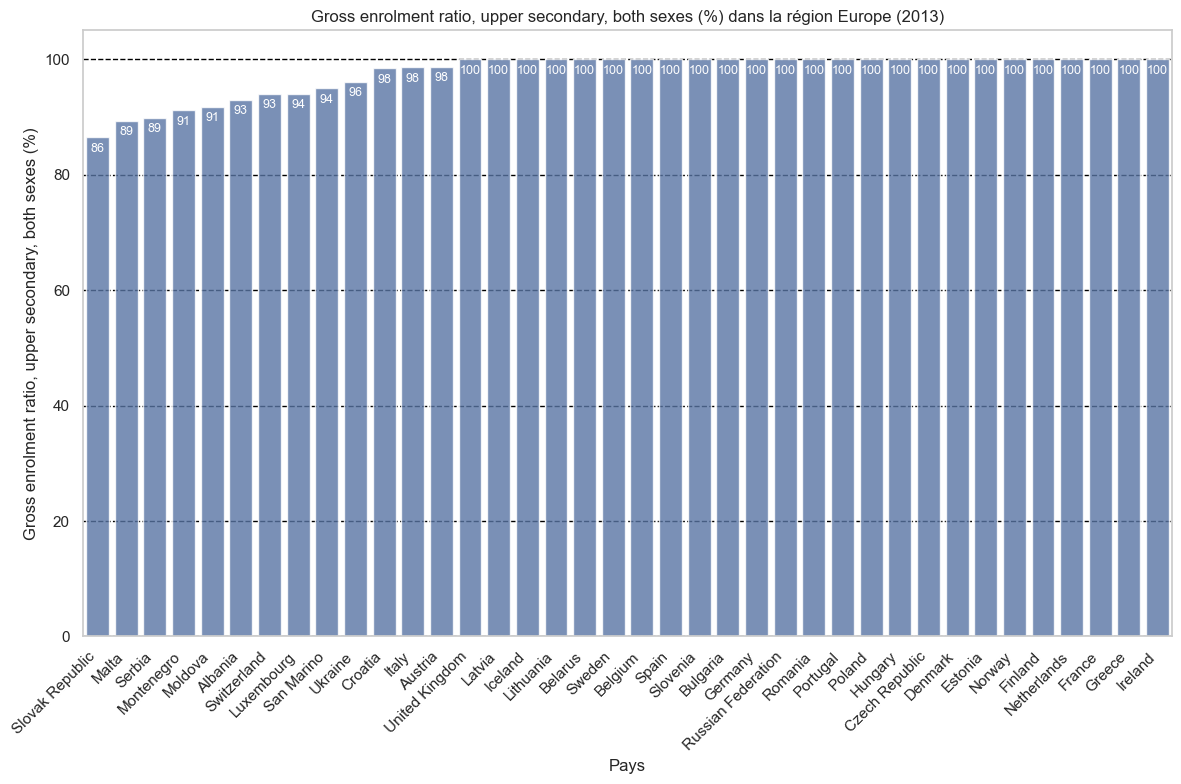

In [215]:
get_barplot("Europe", "Gross enrolment ratio, upper secondary, both sexes (%)")

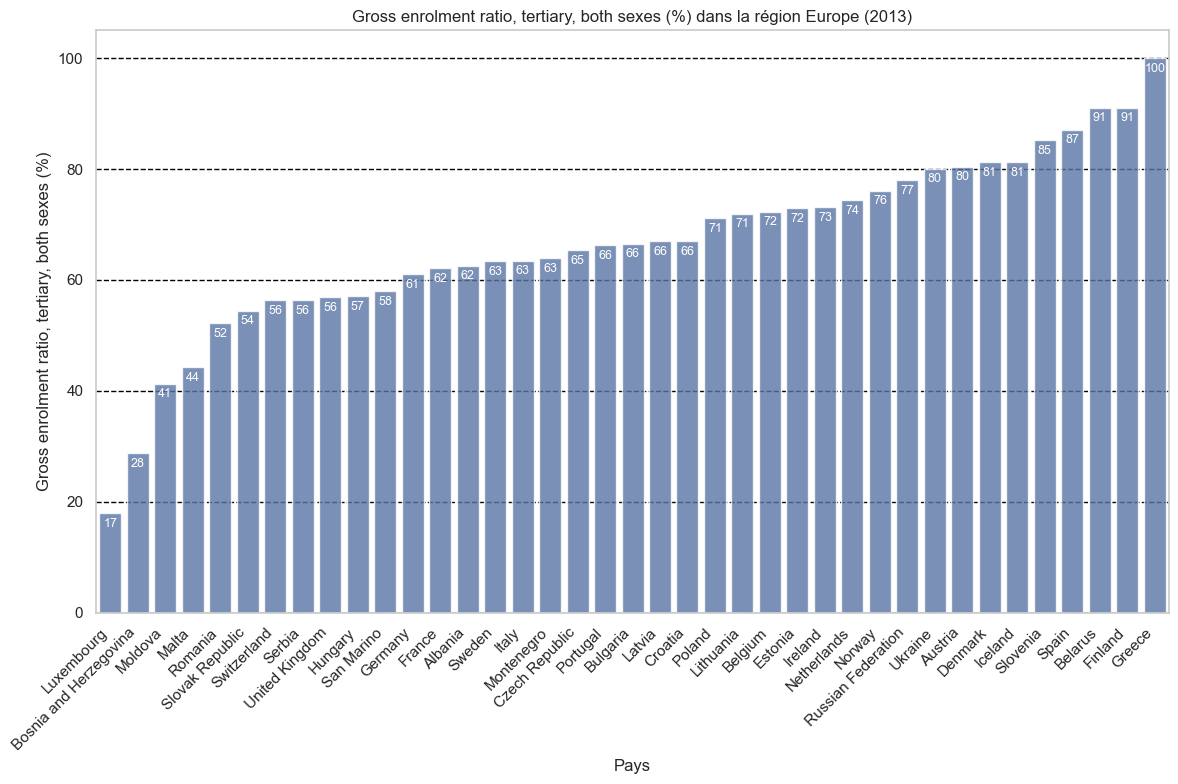

In [216]:
get_barplot("Europe", "Gross enrolment ratio, tertiary, both sexes (%)")

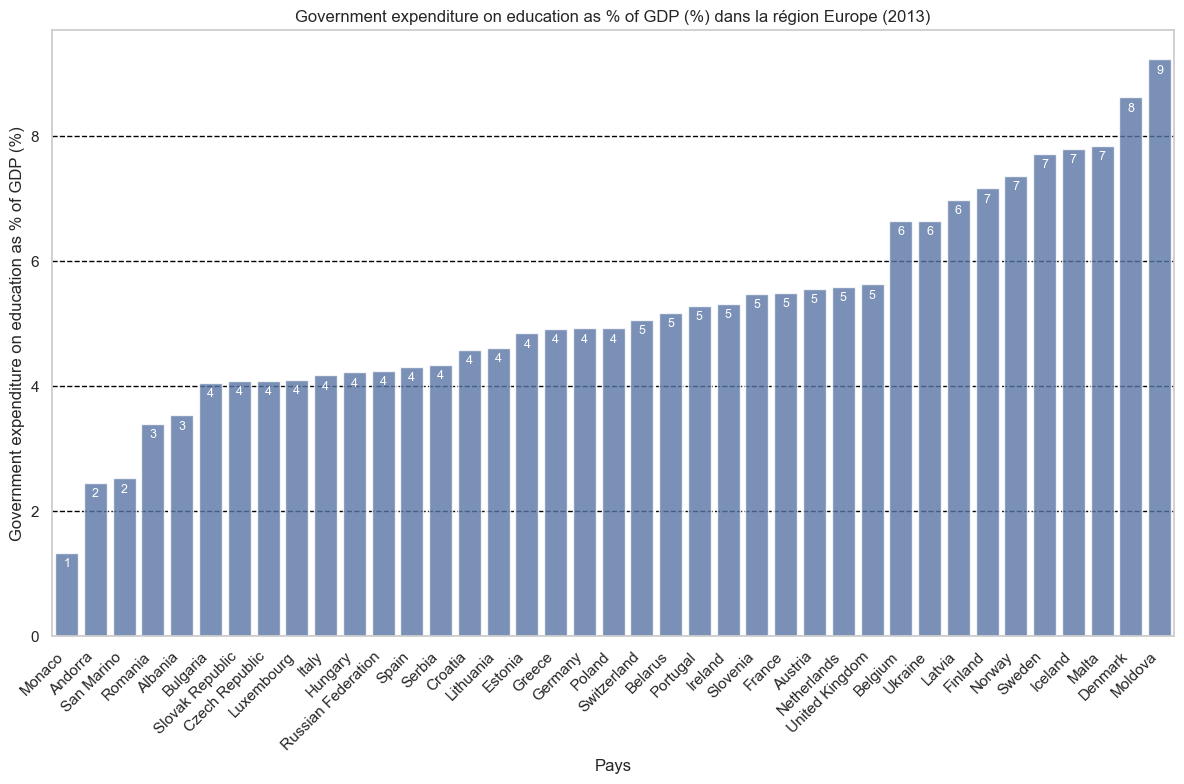

In [217]:
get_barplot("Europe", "Government expenditure on education as % of GDP (%)")

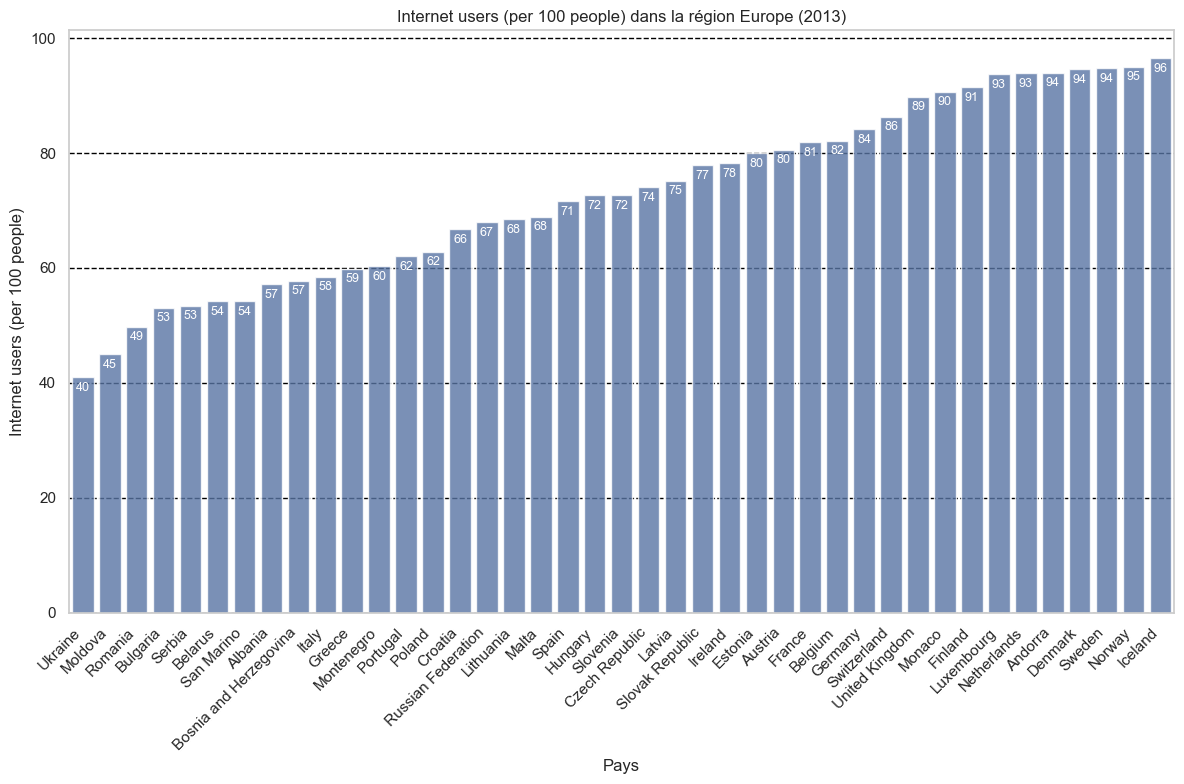

In [218]:
get_barplot("Europe", "Internet users (per 100 people)")

**Synthèse des résultats**

Pays avec des scores élevés dans tous les indicateurs :

- **Norway :**

  - Taux d'inscription secondaire : 100 %
  - Taux d'inscription tertiaire : 76.12 %
  - Dépenses publiques en éducation : 7.37 % (élevé)
  - Utilisateurs d'Internet : 95.05 (très élevé).

La Norvège représente un marché mature avec des infrastructures solides et un fort engagement envers l'éducation.

- **Finland :**

  - Taux d'inscription secondaire : 100 %
  - Taux d'inscription tertiaire : 91.07 %
  - Dépenses publiques en éducation : 7.17 %
  - Utilisateurs d'Internet : 91.51.

La Finlande est un leader éducatif avec des investissements élevés et une forte connectivité. C’est une référence mondiale pour les solutions éducatives innovantes.

- **Sweden :**

  - Taux d'inscription secondaire : 100 %
  - Taux d'inscription tertiaire : 63.39 %
  - Dépenses publiques en éducation : 7.72 % (très élevé)
  - Utilisateurs d'Internet : 94.78.

La Suède combine une connectivité excellente, des investissements significatifs dans l'éducation, et un taux d’inscription tertiaire en croissance.

**Analyse finale des pays choisis :**

In [220]:
df_eu = df_regions[df_regions["Country Name"].isin(["Norway","Finland","Sweden"])]
df_eu.head()

,Year,Country Name,Expenditure on education as % of total government expenditure (%),"GNI, PPP (current international $)",Government expenditure on education as % of GDP (%),Government expenditure on secondary education as % of GDP (%),Government expenditure on tertiary education as % of GDP (%),Government expenditure per tertiary student (PPP$),Government expenditure per upper secondary student (PPP$),"Gross enrolment ratio, tertiary, both sexes (%)","Gross enrolment ratio, upper secondary, both sexes (%)",Internet users (per 100 people),Percentage of enrolment in tertiary education in private institutions (%),Percentage of enrolment in upper secondary education in private institutions (%),Personal computers (per 100 people),Region
68,1999,Finland,11.76006,1.266606e+11,5.86605,2.316600,1.98576,9560.081055,6001.737305,81.492020,100.0,32.295092,11.451180,7.52659,36.013151,Europe
154,1999,Norway,14.85471,1.352144e+11,6.94283,2.621851,1.88813,13664.045898,12584.160653,66.427391,100.0,40.000000,12.120999,10.10380,44.778111,Europe
196,1999,Sweden,12.43410,2.399598e+11,6.92362,2.660680,1.86952,13433.076172,7130.682617,63.579910,100.0,41.432783,6.139820,1.49887,45.128416,Europe
305,2000,Finland,12.17092,1.375099e+11,5.72785,2.217140,1.94548,9866.823242,5822.427246,82.439072,100.0,37.248462,10.794460,10.39011,39.602185,Europe
393,2000,Norway,15.48646,1.636446e+11,6.45563,2.592608,1.64210,14212.673828,13148.597579,69.342293,100.0,52.000000,12.339863,10.88668,48.980624,Europe


La Norvège, la Finlande, et la Suède présentent des niveaux élevés et homogènes dans les quatre indicateurs :

- Une accessibilité quasi universelle à l’enseignement secondaire.
- Un taux d’inscription tertiaire significatif, indiquant un marché éducatif actif.
- Des dépenses publiques parmi les plus élevées en Europe, favorisant un environnement favorable pour *Academy*.
- Une très forte connectivité Internet, essentielle pour des solutions EdTech numériques.

**Conclusion :** Ces trois pays offrent une combinaison optimale de maturité éducative, de connectivité technologique et d’investissements financiers, permettant à *Academy* de proposer des solutions innovantes et interactives avec une forte chance de succès.

**b) Amérique Latine & Caraïbes**

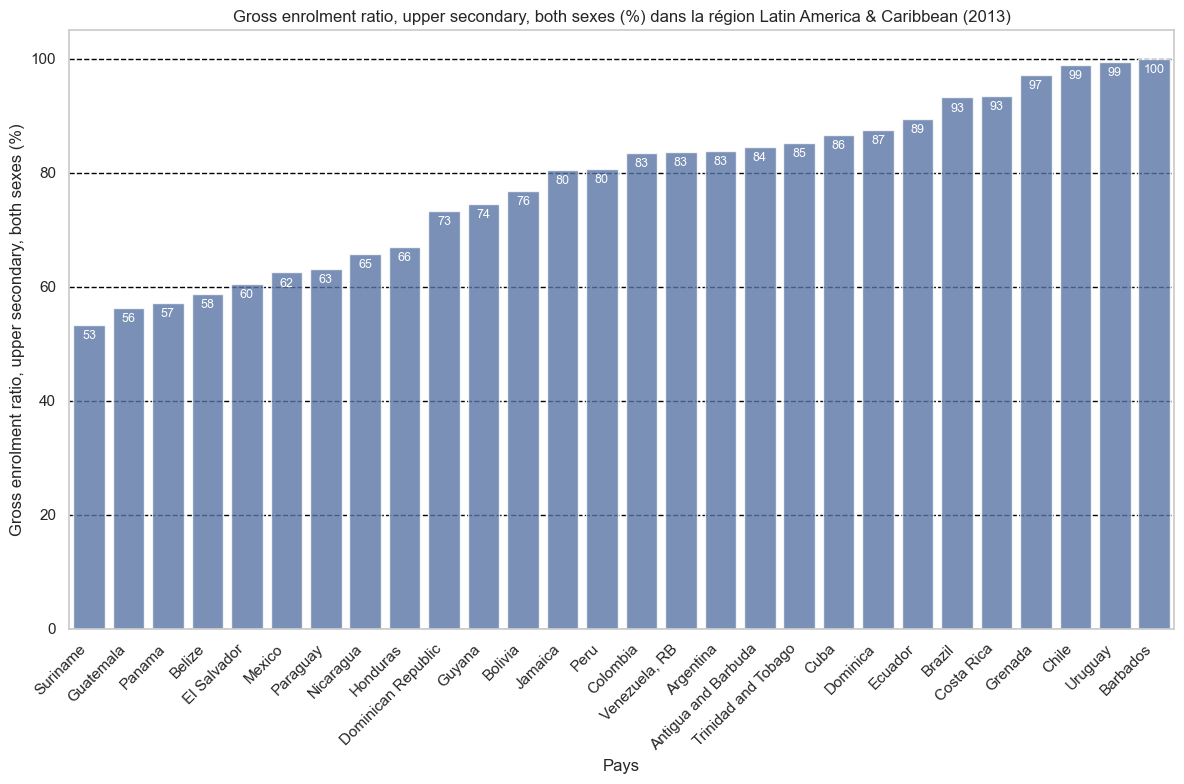

In [223]:
get_barplot("Latin America & Caribbean", "Gross enrolment ratio, upper secondary, both sexes (%)")

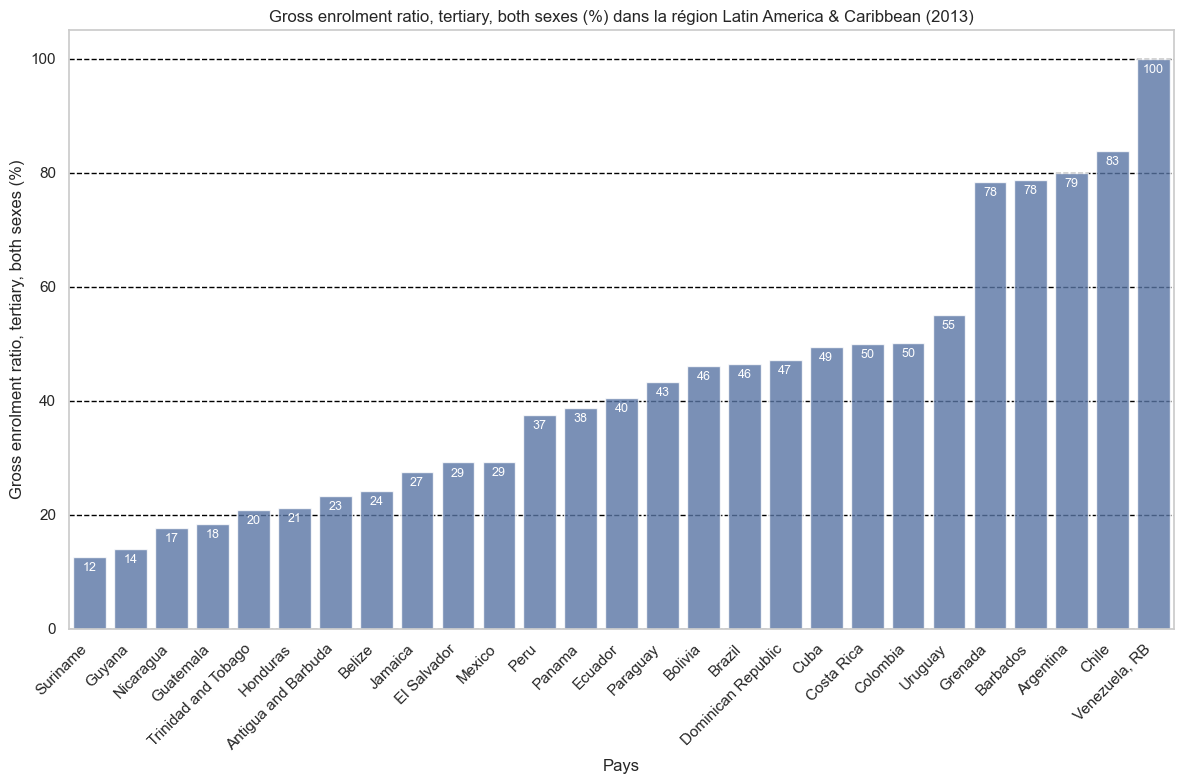

In [224]:
get_barplot("Latin America & Caribbean", "Gross enrolment ratio, tertiary, both sexes (%)")

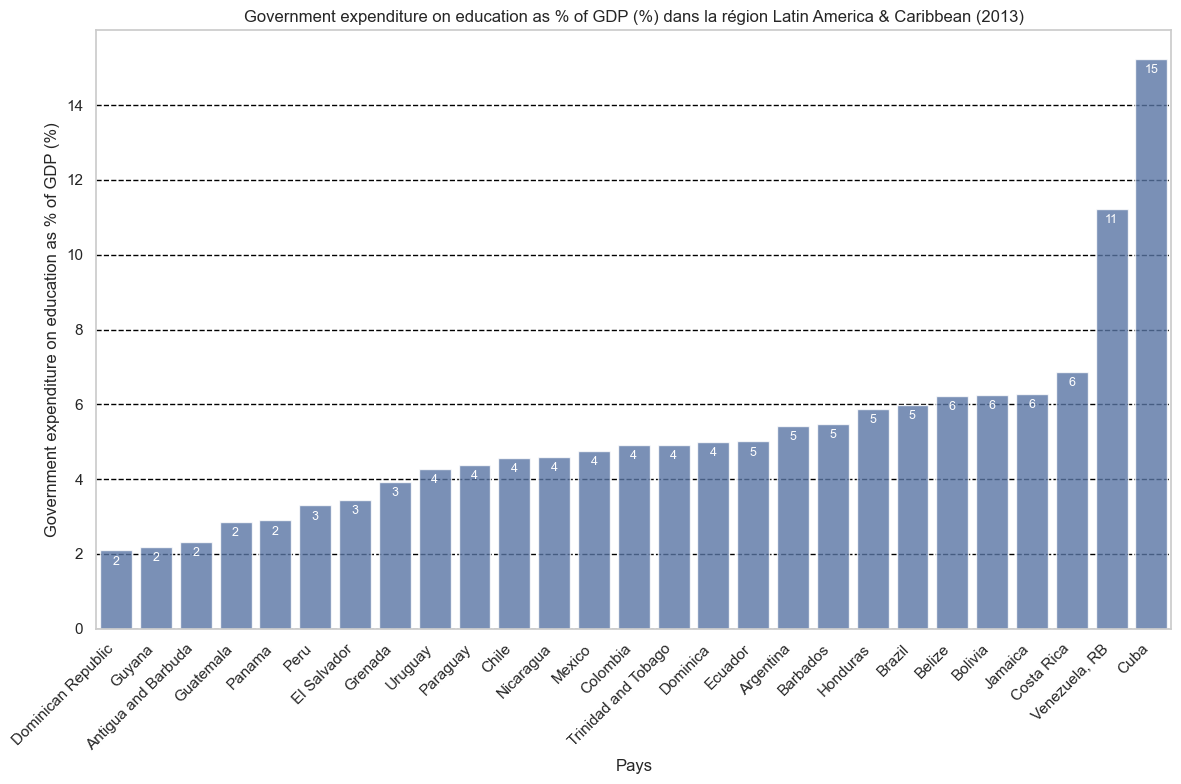

In [225]:
get_barplot("Latin America & Caribbean", "Government expenditure on education as % of GDP (%)")

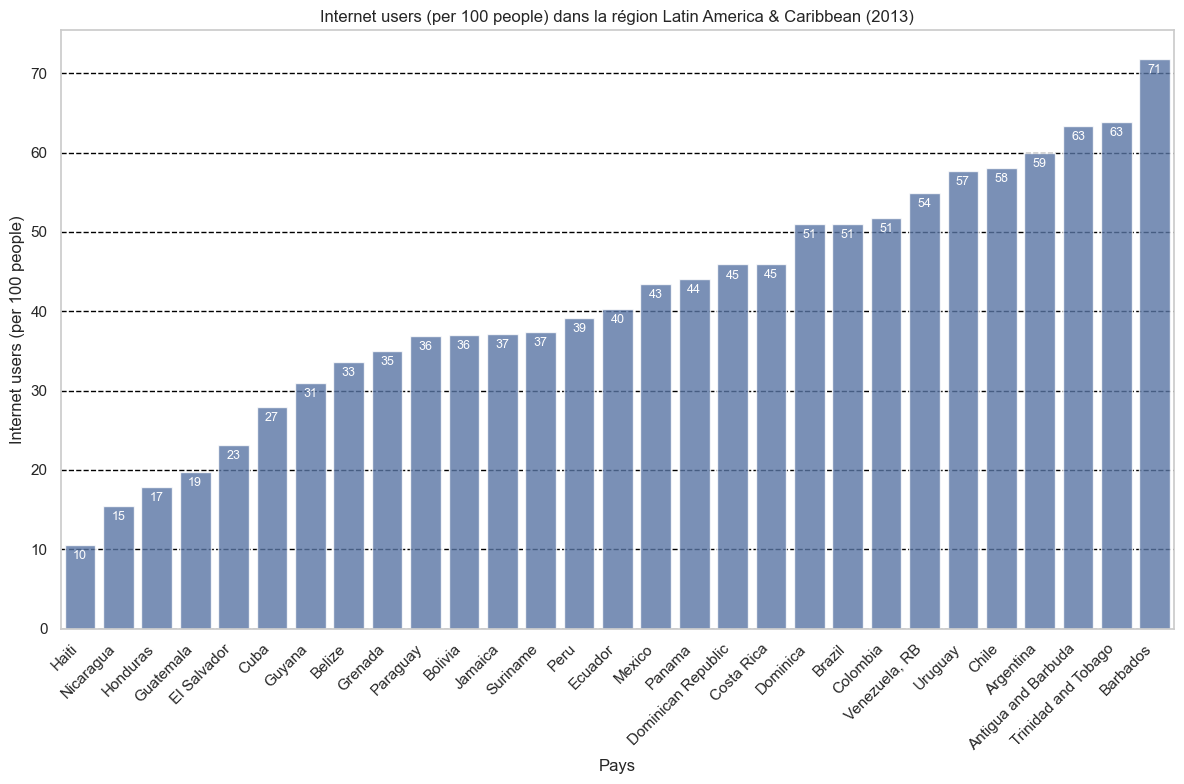

In [226]:
get_barplot("Latin America & Caribbean", "Internet users (per 100 people)")

**Synthèse des résultats**

Pays avec des scores élevés dans tous les indicateurs :

- **Chile :**

  - Taux d'inscription secondaire : 99.02%
  - Taux d'inscription tertiaire : 83.82%
  - Dépenses publiques : 4.56%
  - Utilisateurs d'Internet : 58.0

Le Chili combine un excellent accès à l'éducation secondaire et tertiaire, ainsi qu'une connectivité Internet élevée.

- **Brazil :**

  - Taux d'inscription secondaire : 93.23 %
  - Taux d'inscription tertiaire : 46.45% (modéré mais prometteur)
  - Dépenses publiques en éducation : 5.99%
  - Utilisateurs d'Internet : 51.04
  - **Population estimée :** ~214 millions d'habitants (2023).

Le Brésil pourrait être un choix stratégique pour cibler une population plus large tout en maintenant des indicateurs éducatifs solides.

- **Costa Rica :**

  - Taux d'inscription secondaire : 93.5%
  - Taux d'inscription tertiaire : 50.01%
  - Dépenses publiques en éducation : 6.87%
  - Utilisateurs d'Internet : 45.96

Le Costa Rica présente des investissements élevés en éducation, des taux d'inscription stables et un potentiel de croissance en connectivité Internet.

**Analyse finale des pays choisis :**

In [228]:
df_lat = df_regions[df_regions["Country Name"].isin(["Chile","Brazil","Costa Rica"])]
df_lat.head()

,Year,Country Name,Expenditure on education as % of total government expenditure (%),"GNI, PPP (current international $)",Government expenditure on education as % of GDP (%),Government expenditure on secondary education as % of GDP (%),Government expenditure on tertiary education as % of GDP (%),Government expenditure per tertiary student (PPP$),Government expenditure per upper secondary student (PPP$),"Gross enrolment ratio, tertiary, both sexes (%)","Gross enrolment ratio, upper secondary, both sexes (%)",Internet users (per 100 people),Percentage of enrolment in tertiary education in private institutions (%),Percentage of enrolment in upper secondary education in private institutions (%),Personal computers (per 100 people),Region
25,1999,Brazil,9.600270,1.406158e+12,3.79264,1.349530,0.797310,4818.514160,0.000000,16.084160,87.137042,2.038732,63.055820,13.396817,3.546380,Latin America & Caribbean
37,1999,Chile,15.633220,1.325813e+11,3.84451,1.305754,0.295347,969.023682,868.373837,37.308781,78.853371,4.103419,70.224343,52.865581,7.559512,Latin America & Caribbean
43,1999,Costa Rica,21.923691,2.525228e+10,5.41074,1.420320,0.841450,2217.796591,1448.913696,15.812412,42.713291,3.904323,51.591592,17.103621,10.411965,Latin America & Caribbean
262,2000,Brazil,11.452160,1.511051e+12,3.94594,1.513910,0.869290,4954.514648,0.000000,16.156225,87.448998,2.870685,65.420982,13.609881,4.870923,Latin America & Caribbean
274,2000,Chile,16.401489,1.414935e+11,3.70572,1.270030,0.538650,1779.847412,1388.046997,37.147419,80.104088,16.600000,72.440437,53.537968,9.188321,Latin America & Caribbean


**Conclusion :** Les pays choisis (Chili, Brésil, Costa Rica) représentent des marchés prometteurs pour *Academy*, avec des infrastructures éducatives solides, des investissements publics significatifs, et une connectivité numérique suffisante pour soutenir des solutions EdTech. 

**c) Moyen Orient**

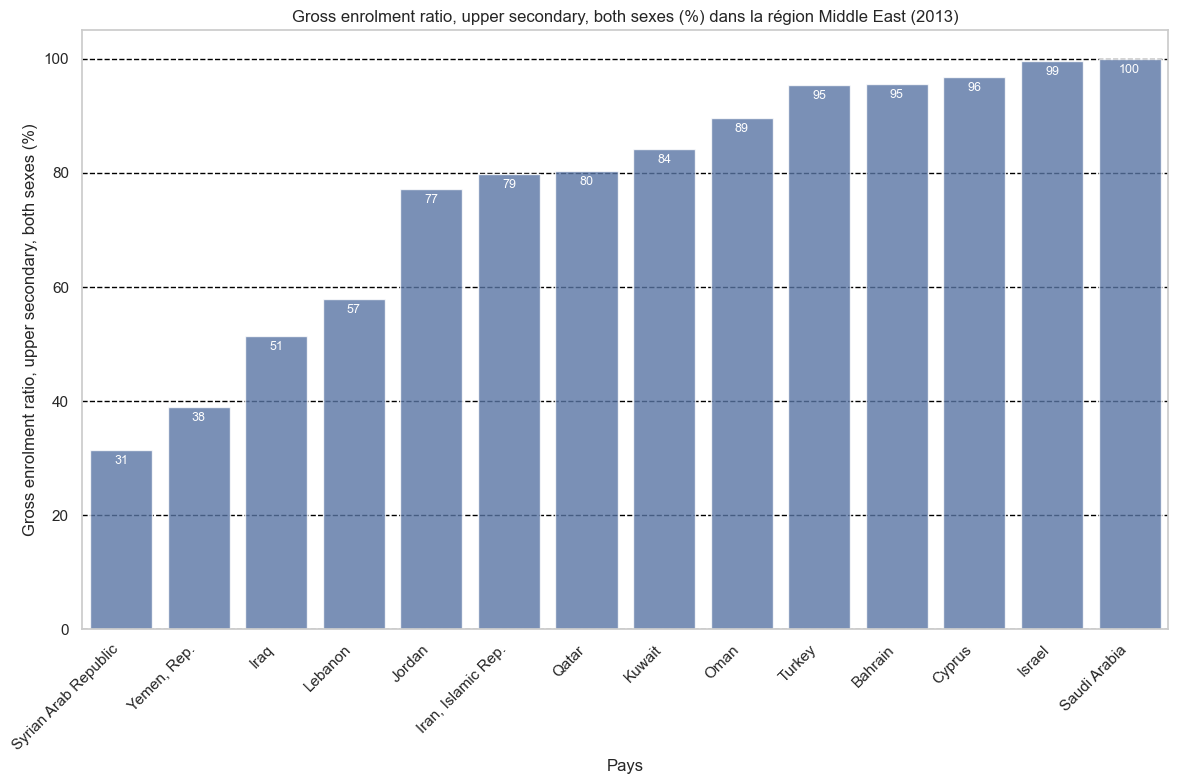

In [231]:
get_barplot("Middle East", "Gross enrolment ratio, upper secondary, both sexes (%)")

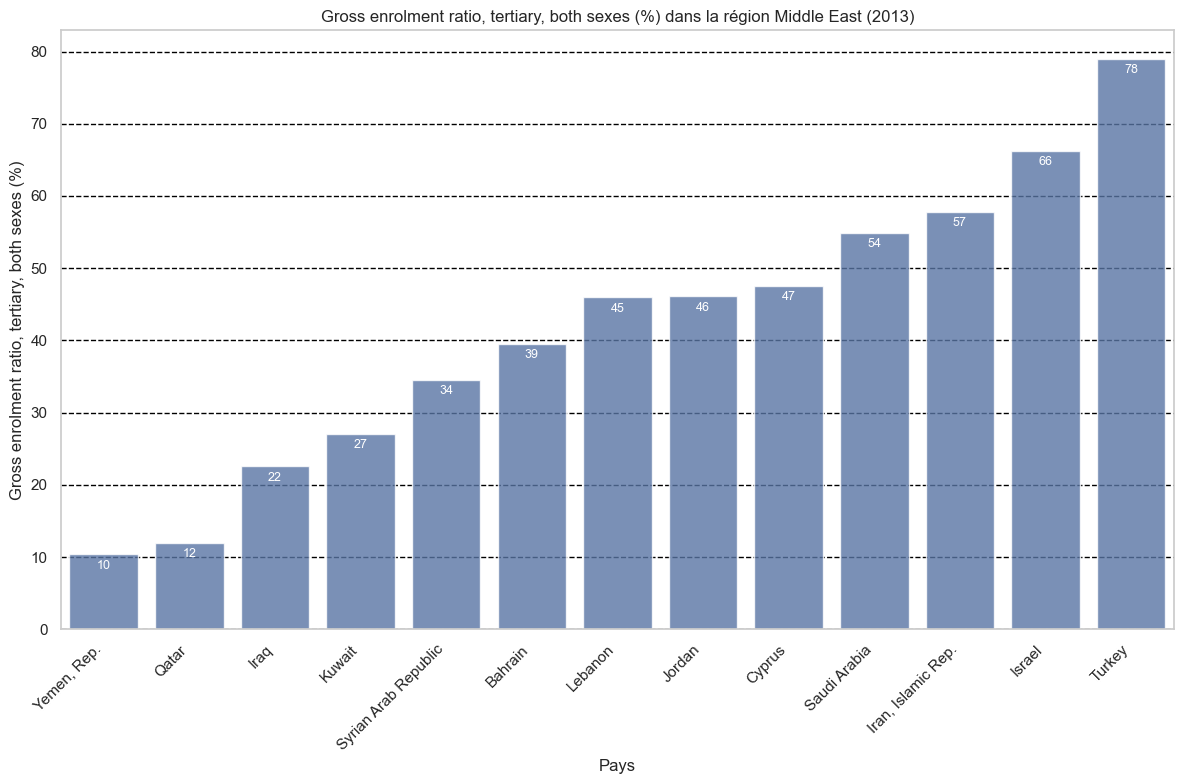

In [232]:
get_barplot("Middle East", "Gross enrolment ratio, tertiary, both sexes (%)")

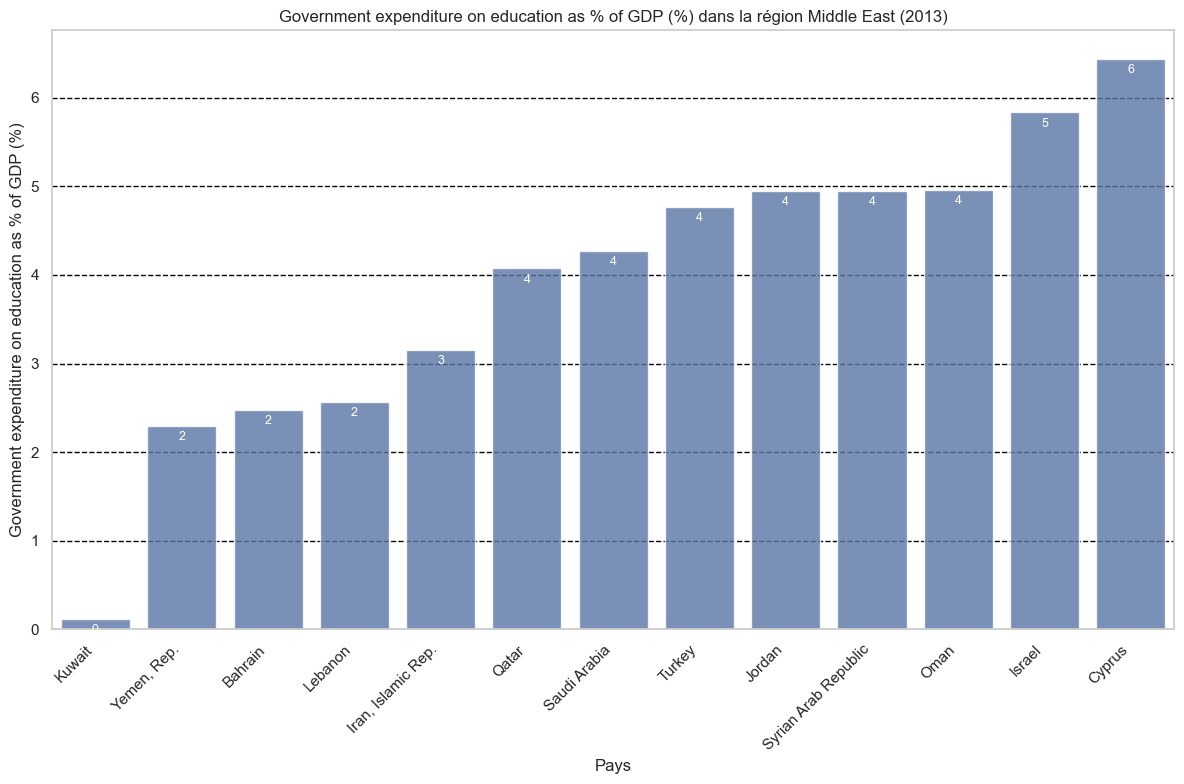

In [233]:
get_barplot("Middle East", "Government expenditure on education as % of GDP (%)")

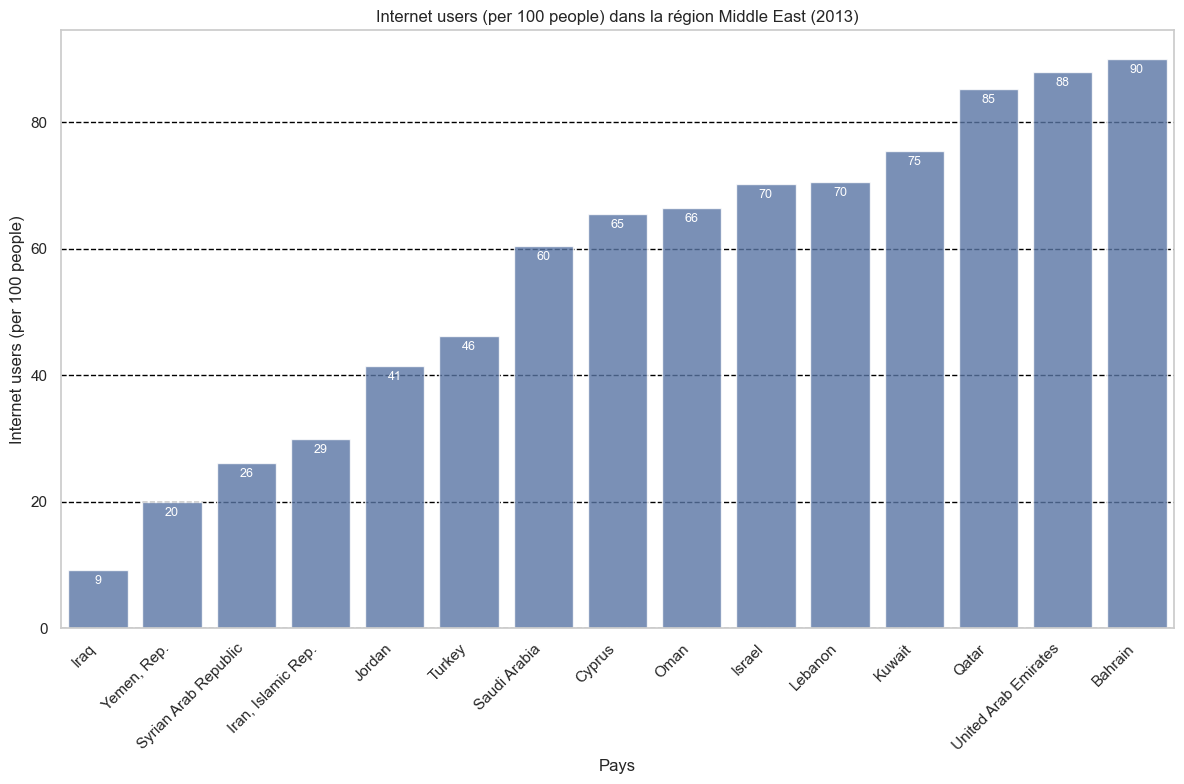

In [234]:
get_barplot("Middle East", "Internet users (per 100 people)")

**Synthèse des résultats**

Pays avec des scores élevés dans tous les indicateurs :

- **Israel :**

  - Taux d'inscription secondaire : 99.66%
  - Taux d'inscription tertiaire : 66.28%
  - Dépenses publiques : 5.83%
  - Utilisateurs d'Internet : 70.25

Israël offre des indicateurs solides et un environnement propice à des solutions éducatives innovantes.

- **Turkey :**

  - Taux d'inscription secondaire : 95.42%
  - Taux d'inscription tertiaire : 78.98%
  - Dépenses publiques en éducation : 4.77%
  - Utilisateurs d'Internet : 46.25

La Turquie combine une population nombreuse, un bon accès à l’éducation, et un potentiel de croissance numérique.

- **Cyprus :**

  - Taux d'inscription secondaire : 96.77%
  - Taux d'inscription tertiaire : 47.53%
  - Dépenses publiques en éducation : 6.44%
  - Utilisateurs d'Internet : 65.45

Chypre présente un bon équilibre entre investissement public, connectivité Internet, et accès éducatif.

**Analyse finale des pays choisis :**

In [236]:
df_mo = df_regions[df_regions["Country Name"].isin(["Israel","Turkey","Cyprus"])]
df_mo.head()

,Year,Country Name,Expenditure on education as % of total government expenditure (%),"GNI, PPP (current international $)",Government expenditure on education as % of GDP (%),Government expenditure on secondary education as % of GDP (%),Government expenditure on tertiary education as % of GDP (%),Government expenditure per tertiary student (PPP$),Government expenditure per upper secondary student (PPP$),"Gross enrolment ratio, tertiary, both sexes (%)","Gross enrolment ratio, upper secondary, both sexes (%)",Internet users (per 100 people),Percentage of enrolment in tertiary education in private institutions (%),Percentage of enrolment in upper secondary education in private institutions (%),Personal computers (per 100 people),Region
47,1999,Cyprus,13.904120,1.319989e+10,4.71968,2.42493,0.70771,8611.295898,5400.008012,21.032419,90.108948,11.342399,66.731006,11.009630,14.046598,Middle East
97,1999,Israel,12.433152,1.324709e+11,6.42082,1.92282,1.17801,6608.349121,11072.306641,48.447578,100.000000,13.436122,69.911186,5.364631,23.085033,Middle East
206,1999,Turkey,5.892579,5.378991e+11,2.94614,NaN,0.82506,2916.348145,1187.977173,23.511681,64.632980,2.292118,2.682248,1.735890,3.534490,Middle East
284,2000,Cyprus,14.268310,1.425543e+10,4.89278,2.52349,0.85954,11875.951172,6216.262207,19.562321,88.892723,15.255394,56.222389,10.503690,15.901841,Middle East
334,2000,Israel,12.918410,1.470096e+11,6.11352,1.83672,1.11926,6846.749023,11072.306641,49.471531,100.000000,20.873790,70.315880,5.421399,26.439581,Middle East


**Conclusion :** Ces pays se distinguent par des infrastructures éducatives solides, des investissements significatifs en éducation, et un bon niveau de connectivité numérique, ce qui en fait des marchés prometteurs pour *Academy*.

#### 4.3.3. Statistiques avancées

##### **A) Analyse avec le chi²**

Le test du chi² (chi-square) est utilisé pour mesurer la relation entre deux variables catégoriques. Il permet de tester l’hypothèse d’indépendance entre les variables, c’est-à-dire si elles sont statistiquement liées ou non.

Dans notre analyse, nous allons tester si les variables de région géographique et de tranche du poucentage d'inscription dans le secondaire dans le privé sont liées.

On va donc catégoriser les pays en trois classes ("Faible", "Modéré" et "Élevé") en fonction du pourcentage d'inscription dans l'enseignement secondaire privé. Les valeurs seront regroupées en tranches définies par des intervalles (`[0, 15]`, `[15, 30]`, `[30, 100]`).

In [241]:
df_2013 = df_2013.copy()  # Crée une copie explicite

# Création d'une variable catégorique par tranche
df_2013["Enrollment_Class"] = pd.cut(
    df["Percentage of enrolment in upper secondary education in private institutions (%)"],
    bins=[0, 15, 30, 100],  # Définit les tranches
    labels=["Faible", "Modéré", "Élevé"]
)

df_2013["Enrollment_Class"].value_counts()

Enrollment_Class
Faible    40
Modéré    26
Élevé     14
Name: count, dtype: int64

On crée ensuite un tableau de contingence qui affiche le nombre d'occurrences des classes d'inscription dans l'enseignement secondaire privé par région, avec des totaux globaux.

In [243]:
X = "Region"
Y = "Enrollment_Class"

cont = df_2013[[X, Y]].pivot_table(
    index=X,
    columns=Y,
    aggfunc=len,
    margins=True,
    margins_name="Total",
    observed=False  # Inclut toutes les catégories, même non observées
)

cont

Enrollment_Class,Faible,Modéré,Élevé,Total
Region,,,,
Europe,26,11,3,40
Latin America & Caribbean,8,11,7,26
Middle East,6,4,4,14
Total,40,26,14,80


On calcule la matrice des fréquences attendues, montrant les valeurs théoriques si les deux variables étaient indépendantes.

In [245]:
# Fréquences attendues si les deux variables étaient indépendantes

tx = cont.loc[:, ["Total"]]                              # Totaux par ligne
ty = cont.loc[["Total"], :]                              # Totaux par colonne
n = len(df_2013[~df_2013["Enrollment_Class"].isna()])    # Nombre total d'observations

indep = tx.dot(ty) / n    # Matrice des fréquences attendues si les variables étaient indépendantes

indep

Enrollment_Class,Faible,Modéré,Élevé,Total
Region,,,,
Europe,20.0,13.00,7.00,40.0
Latin America & Caribbean,13.0,8.45,4.55,26.0
Middle East,7.0,4.55,2.45,14.0
Total,40.0,26.00,14.00,80.0


Maintenant que la matrice des fréquences attendues est créée, oncalcule les contributions individuelles normalisées au chi², indiquant l'importance de chaque cellule dans la déviation par rapport à l'indépendance théorique entre les variables.

In [247]:
# Calcul des contributions au chi²

c = cont.fillna(0)                  # Remplace les valeurs nulles par 0
measure = (c - indep)**2 / indep    # Contributions individuelles au chi² pour chaque cellule
xi_n = measure.sum().sum()          # Valeur totale du chi² (somme de toutes les contributions)

# Normalisation des contributions

table = measure / xi_n

table

Enrollment_Class,Faible,Modéré,Élevé,Total
Region,,,,
Europe,0.187594,0.032067,0.238214,0.0
Latin America & Caribbean,0.200421,0.080199,0.137489,0.0
Middle East,0.014888,0.006929,0.102198,0.0
Total,0.000000,0.000000,0.000000,0.0


On visualise enfin les contributions normalisées au chi² sous forme de carte de chaleur pour identifier les cellules qui dévient le plus des fréquences attendues, facilitant l'analyse des associations entre les variables.

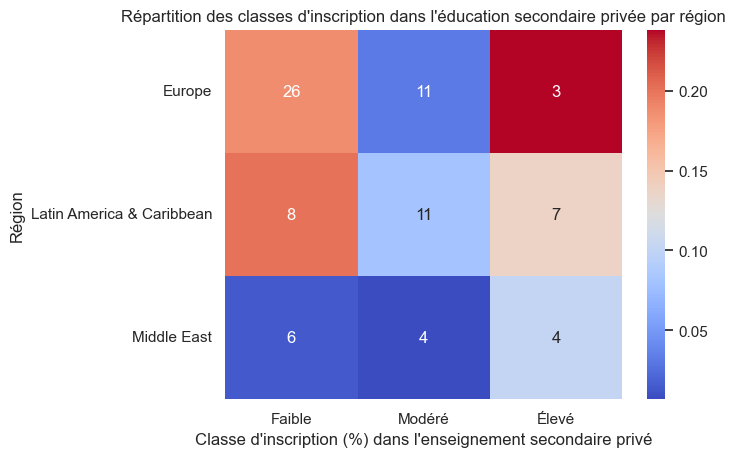

In [249]:
# Visualisation avec une carte de chaleur des contributions normalisées

sns.heatmap(table.iloc[:-1, :-1], annot=c.iloc[:-1, :-1], cmap="coolwarm")    # Exclut la dernière ligne et colonne (totaux).
plt.title("Répartition des classes d'inscription dans l'éducation secondaire privée par région")
plt.xlabel("Classe d'inscription (%) dans l'enseignement secondaire privé")  # Label plus précis
plt.ylabel("Région")  # Conserve le label de l'axe y
plt.show()

**Lien entre les couleurs et les fréquences attendues :**

- **Couleurs froides (bleu foncé) :**

  - Elles représentent les cases où les effectifs observés sont très proches des effectifs attendus (selon l'hypothèse d'indépendance).
  - Cela signifie que ces cases ne contribuent pas beaucoup à la non-indépendance entre les deux variables.

- **Couleurs chaudes (rouge/orange) :**

  - Elles signalent les cases où les effectifs observés s’éloignent fortement des effectifs attendus.
  - Cela indique une contribution élevée à la non-indépendance entre les deux variables, c'est-à-dire que ces cases dérogent à l'hypothèse d'indépendance.

**Interprétation en pratique :**

- **Case avec couleur froide :** Les effectifs correspondent quasiment à ce que l'on attendrait si les deux variables (région et classe d'inscription) étaient indépendantes.

→ Il y a peu de lien entre les deux variables dans cette case.

- **Case avec couleur chaude :** Les effectifs observés sont très différents de ce qui serait attendu sous l'hypothèse d'indépendance.

→ Cela met en lumière un lien fort ou une surreprésentation entre les deux variables dans cette case.

**Analyse du graphique :**

1. Europe :

  - Il y a beaucoup plus de pays dans la classe "Faible" que ce que l’on aurait attendu sous l’hypothèse d’indépendance.
  - Cela signifie que l’Europe tend à concentrer une proportion anormalement élevée de pays dans la catégorie "Faible".

2. Latin America & Caribbean :

  - Il y a plus de pays dans la classe élevé que prévu sous l'hypothèsee d'indépendance.
  - Cela sous entend que l'Amérique Latine tend à avoir une forte proportion de pays dans la catégorie "Élevé"

4. Middle East :

  - Les effectifs observés sont proches des valeurs attendues.
  - Cela indique que le lien entre la région Middle East et notre indicateur est faible.

**Conclusion :**

- **Europe :** Cette région ayant un faible taux d'inscription dans le privé pour l'enseignement secondaire, il serait intéressant de se positionner vers un développement et un subventionnement envers l'enseignement public.
- **Latin America & Caribbean :** Avec une concentration élevée de pays favorisant l'enseignement secondaire privé, *Academy* pourrait tenter d'adapter ses solutions et sa communication pour les établissements privés.
- **Middle East :** Les taux d'inscription conformes à la théorie d'indépendance des deux variables, cette région serait idééale pour tester les deux modèles de l'Europe et de l'Amérique Latine.

##### **B) Coefficient η²**

Le coefficient η² (Eta Squared) est utilisé pour mesurer l’effet d’une variable catégorique sur une variable quantitative. Il évalue la proportion de la variance d’une variable quantitative qui est expliquée par une variable catégorique.

**Étapes pour le calcul de η²**
 
1. Décomposer la variance de la variable quantitative :

- **SST :** La variance totale (somme des carrés des écarts par rapport à la moyenne générale).
- **SSB :** La variance expliquée par le modèle (somme des carrés des écarts des moyennes des groupes par rapport à la moyenne générale).
- **SSW :** La variance résiduelle (somme des carrés des écarts à l'intérieur des groupes).

La relation suivante doit être vérifiée : **SST=SSB+SSW**

2. Calcul de η² : **η² = SST/SSB**
​
 
Cela donne la proportion de la variance totale expliquée par la variable catégorique.



In [253]:
# Supprime les lignes avec des valeurs manquantes dans la variable quantitative
df_2013_clean = df_2013.dropna(subset=[Y])

# Variables catégorique et quantitative
X = "Region"  # Variable catégorique
Y = "Gross enrolment ratio, tertiary, both sexes (%)"  # Variable quantitative

# Calcul des moyennes
overall_mean = df_2013_clean[Y].mean()  # Moyenne générale
group_means = df_2013_clean.groupby(X)[Y].mean()  # Moyennes par groupe

# Calcul de SST (variance totale)
SST = sum((df_2013_clean[Y] - overall_mean)**2)

# Calcul de SSB (variance entre groupes)
SSB = sum(df_2013_clean.groupby(X).size() * (group_means - overall_mean)**2)

# Calcul de SSW (variance intra-groupe)
SSW = SST - SSB

# Calcul de η²
eta_squared = SSB / SST
print(f"Coefficient η² : {eta_squared:.2f}")

Coefficient η² : nan


Une interprétation de η² peut être donnée par la règle empirique de Cohen, nous présentant les relations entre variables catégoriques et quantitatives. Celle-ci nous dit que :

- η² < .01 → petite
- η² < .06 → moyenne
- η² > .14 → large

Avec un coefficient η² = 0.28, la relation est dans la catégorie **large** selon la règle empirique de Cohen (>0.14).

**Interprétation des résultats :**

1. **Relation entre les deux variables :**

Un η² d'environ 0.28 indique qu'environ 28% de la variance de la variable quantitative *Y* peut être expliquée par les différences entre les catégories de la variable catégorique *X*.

2. **Signification :**

  - Il existe une **corrélation importante** entre la variable catégorique et la variable quantitative. Les groupes définis par *X* ont des moyennes suffisamment différentes pour expliquer une proportion significative de la variance de *Y*.
  - Cette relation suggère que la catégorisation choisie pour *X* est pertinente pour expliquer les variations de *Y*.

3. **Application à nos variables :**

*X* représentant la région géographique et *Y* le taux d'inscription dans le milieu universitaire, cela signifie que certaines régions peuvent avoir des infrastructures éducatives supérieures, des politiques publiques plus inclusives, ou une économie qui soutient davantage l'accès à l'enseignement supérieur.

Les résultats de η² montrent que les politiques éducatives régionales jouent un rôle important. *Academy* pourrait collaborer avec les gouvernements locaux ou les institutions éducatives pour proposer des solutions alignées sur les besoins spécifiques de chaque région.

### 4.4. Analyse temporelle et prévisions

Pour mieux comprendre les politiques éducatives des pays prometteurs, nous allons analyser l’indicateur "Dépenses publiques en éducation en pourcentage du PIB (%)". Cet indicateur reflète directement l’engagement des gouvernements dans l’éducation et donne une idée des opportunités potentielles pour *Academy*.

**Pourquoi cet indicateur ?**

- **Engagement gouvernemental :** Plus les dépenses sont élevées ou en croissance, plus un pays investit dans son système éducatif, ce qui est favorable à des solutions EdTech comme celles d’*Academy*.
- **Comparaison équitable :** Exprimé en pourcentage du PIB, il est comparable entre pays, quel que soit leur niveau de développement.

**Objectif :**

- **Repérer les tendances :** Identifier les pays où les dépenses augmentent ou stagnent.
- **Cibler les opportunités :** Prioriser les pays qui montrent un engagement croissant en faveur de l’éducation.
- **Prendre des décisions stratégiques :** Utiliser ces informations pour affiner les recommandations et investir dans les bons marchés.

Nous allons donc réaliser une comparaison des coefficients des droites de régression afin d'estimer dans quel pays il serait intéressant de se positionner. Cette approche nous permettra de visualiser l’évolution temporelle pour chaque pays, d’analyser les trajectoires, et de mieux appuyer les choix stratégiques finaux.

In [257]:
def plot_indicator_evolution(indicator, df_region):
    """
    Fonction pour tracer l'évolution temporelle d'un indicateur pour les pays d'une région.
    Affiche les équations des droites de régression pour chaque pays.

    :param indicator: Nom de la colonne de l'indicateur
    :param df_region: DataFrame filtré pour la région concernée
    """
    countries = df_region["Country Name"].unique()  # Liste des pays uniques
    region = df_region["Region"].unique()[0]
    plt.figure(figsize=(12, 8))
    
    equations = []  # Stockage des équations pour chaque pays
    
    for country in countries:
        # Filtre des données pour le pays
        country_data = df_region[df_region["Country Name"] == country]
        years = country_data["Year"]
        values = country_data[indicator]
        
        # Régression linéaire
        coef = np.polyfit(years, values, 1)  # Coefficients a et b
        trendline = np.polyval(coef, years)  # Droite de régression
        
        # Ajout de l'équation dans la liste
        equations.append(f"{country}: y = {coef[0]:.2f}x + {coef[1]:.2f}")
        
        # Tracé de la série temporelle et de la droite de régression
        plt.plot(years, values, marker="o", label=f"{country} (data)")
        plt.plot(years, trendline, linestyle="--", label=f"{country} (fit)")
    
    # Ajout du titre et des légendes
    plt.title(f"Évolution de {indicator} pour les pays de la région {region}")
    plt.xlabel("Année")
    plt.ylabel(indicator)
    plt.legend(bbox_to_anchor=(1, 1), loc="upper left")
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    
    # Affichage des équations des droites
    print("\nÉquations des droites de régression :")
    for eq in equations:
        print(eq)
    
    plt.show()

#### A) Europe


Équations des droites de régression :
Finland: y = 0.09x + -171.02
Norway: y = 0.00x + 4.21
Sweden: y = 0.04x + -74.45


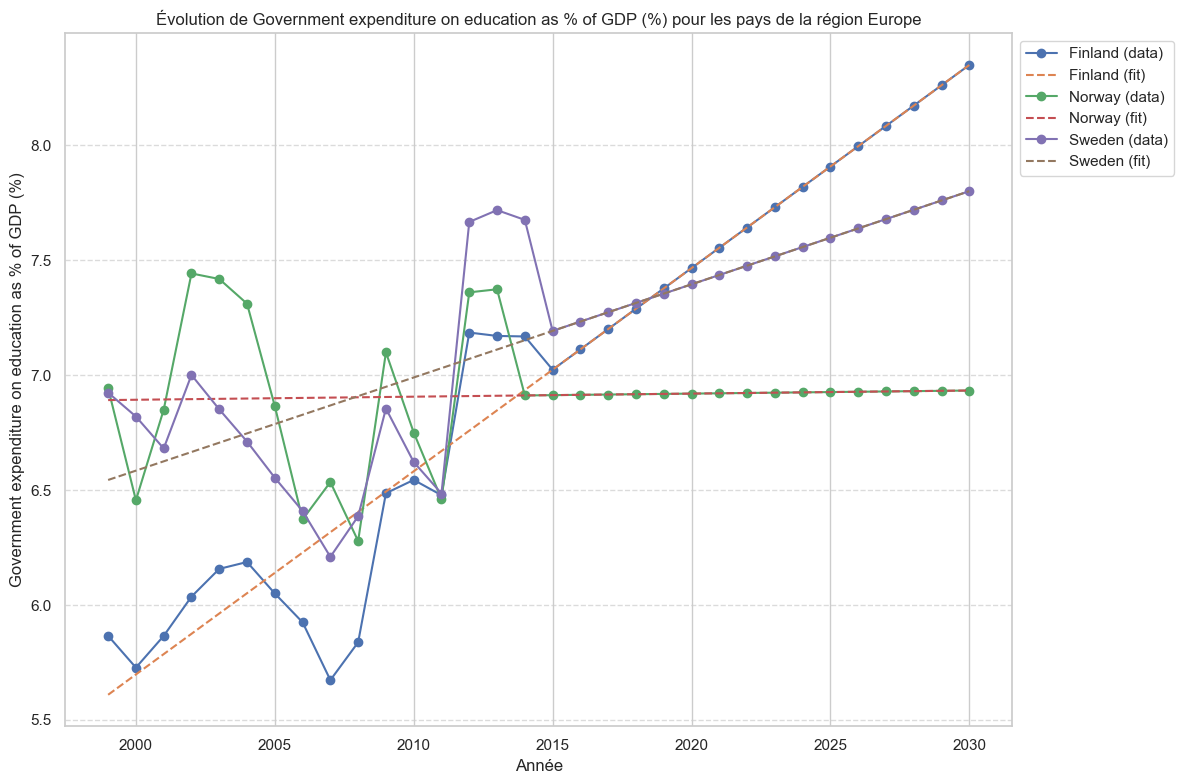

In [259]:
plot_indicator_evolution("Government expenditure on education as % of GDP (%)", df_eu)

Grâce aux équations de droite et au graphique d'évolution des investissements gouvernementaux dans l'éducation, il est possible d'identifier la Finlande comme un pays prioritaire.

1. **Tendance croissante des investissements :** La droite de régression pour la Finlande montre une pente positive (**y = 0.09x − 171.02**), indiquant une augmentation régulière des dépenses publiques en éducation au fil des années. Contrairement à la Norvège (**y = 0.00x + 4.21**) et à la Suède (**y = 0.04x − 74.45**), où les variations sont faibles ou modérées, la Finlande se distingue par une dynamique forte en faveur de l’éducation.

2. **Investissement maximal prévu en 2019 :** En 2019, la Finlande est projetée comme ayant le plus gros pourcentage d'investissement en éducation parmi les trois pays. Cela reflète un engagement significatif et durable de la part du gouvernement, renforçant la pertinence d'y déployer les solutions d’*Academy*.

3. **Marché stable et prometteur :** La Finlande est réputée pour son système éducatif de pointe et sa culture d'innovation. Avec des dépenses publiques croissantes, elle représente un marché idéal pour *Academy*, notamment pour tester et développer des produits éducatifs avancés.

**Conclusion :**

La Finlande, avec sa dynamique d’augmentation des dépenses, son engagement gouvernemental, et sa position de leader éducatif, constitue une priorité stratégique pour *Academy*.








#### B) Amérique Latine et Caraïbes


Équations des droites de régression :
Brazil: y = 0.18x + -356.42
Chile: y = 0.08x + -148.53
Costa Rica: y = 0.15x + -296.45


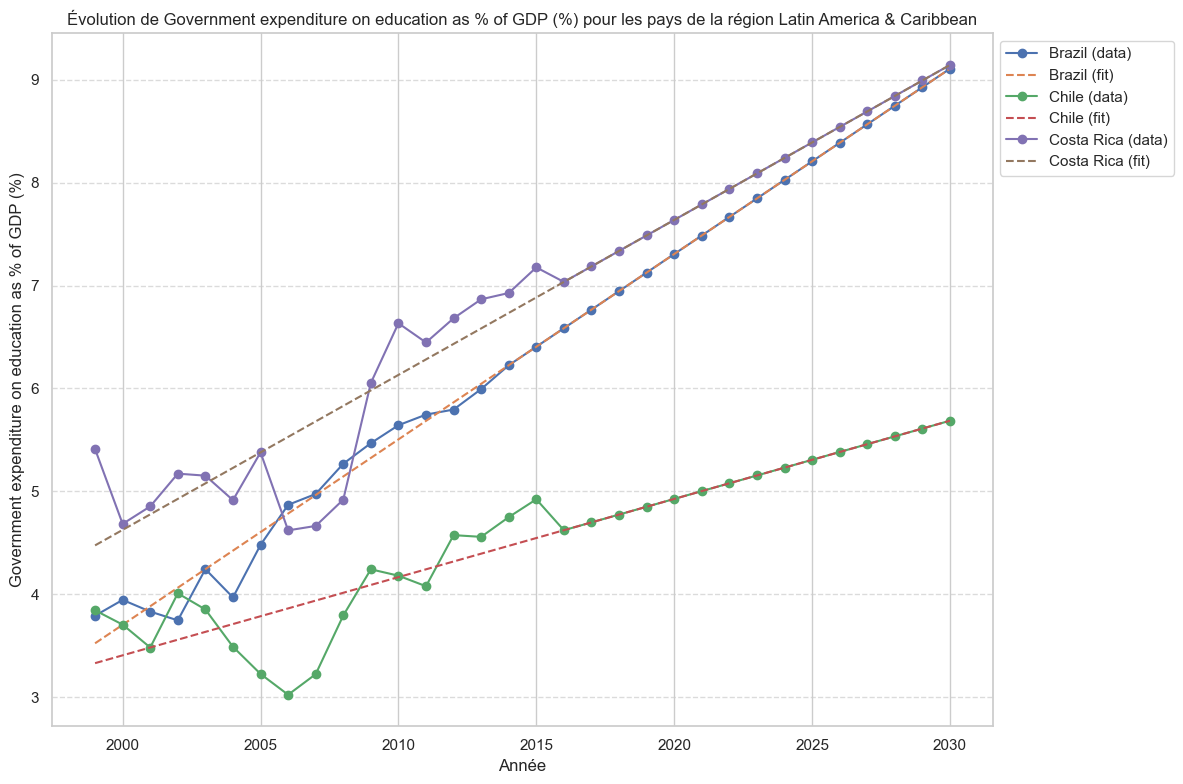

In [262]:
plot_indicator_evolution("Government expenditure on education as % of GDP (%)", df_lat)

Grâce aux équations de droite et au graphique d'évolution des investissements gouvernementaux dans l'éducation, il est possible d'identifier le Brésil comme un choix prioritaire.

1. **Meilleur coefficient de croissance :** La droite de régression du Brésil montre la pente la plus élevée parmi les trois pays (**y = 0.18x − 356.42**), indiquant une croissance rapide et régulière des investissements publics en éducation au fil des années. Même si le Costa Rica (**y = 0.15x − 296.45**) a un taux d'investissement légèrement supérieur en 2015, le Brésil compense cette différence par une dynamique beaucoup plus forte.

2. **Portée démographique importante :** Le Brésil, avec sa grande population, offre un marché beaucoup plus vaste pour *Academy* par rapport au Costa Rica. Cette portée démographique amplifie l'impact potentiel des solutions éducatives d'*Academy*, en permettant d'atteindre un public plus large.

3. **Comparaison avec le Chili et le Costa Rica :**
   - Chili (**y = 0.08x − 148.53**) : Bien que prometteur, le Chili montre une croissance des investissements nettement plus modérée.
   - Costa Rica (**y = 0.15x − 296.45**) : Bien que les taux actuels soient élevés, la croissance est légèrement inférieure à celle du Brésil, et sa population réduite limite l’impact potentiel.

**Conclusion :**

Le Brésil, grâce à sa croissance rapide des investissements, sa grande population, et son potentiel de marché, constitue un choix stratégique pour *Academy*. Il combine une dynamique favorable et une portée significative, en faisant un pays prioritaire dans la région.

#### C) Moyen Orient


Équations des droites de régression :
Cyprus: y = 0.11x + -219.73
Israel: y = -0.06x + 116.71
Turkey: y = 0.13x + -259.30


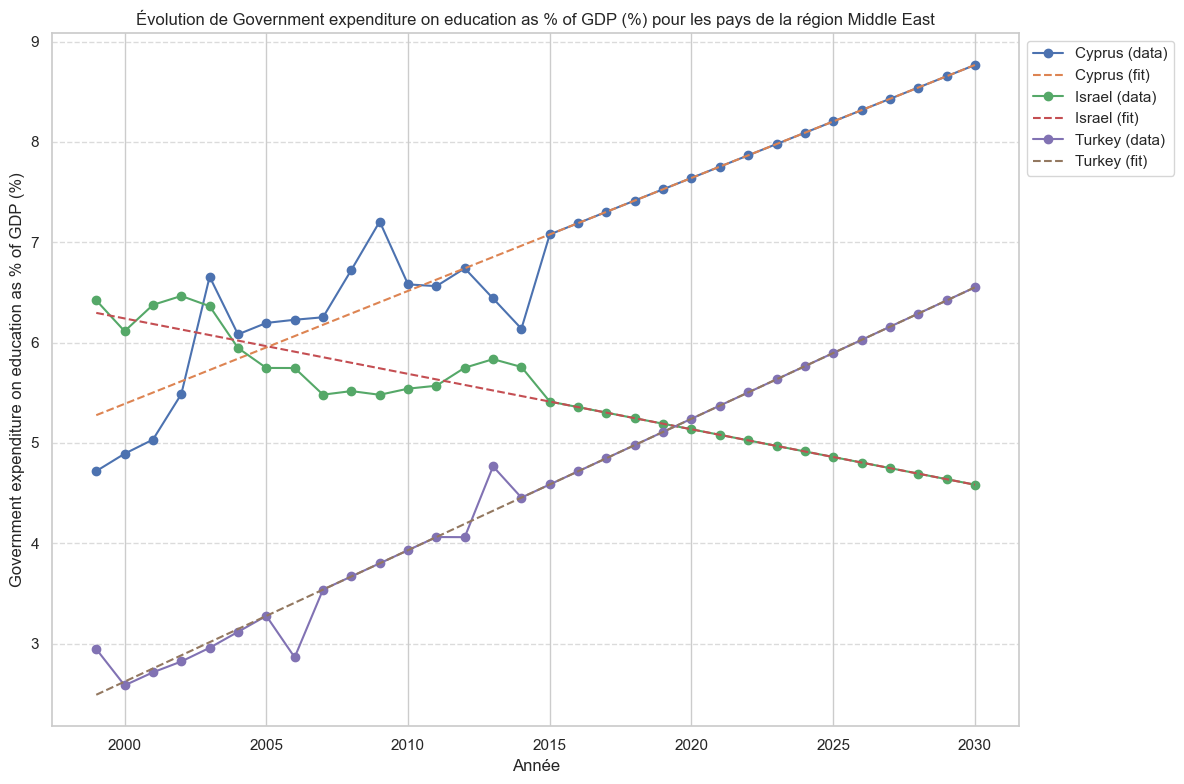

In [265]:
plot_indicator_evolution("Government expenditure on education as % of GDP (%)", df_mo)

Grâce aux équations de droite et au graphique d'évolution des investissements gouvernementaux dans l'éducation, la Turquie apparaît comme un choix stratégique pour *Academy* dans la région du Moyen-Orient.

1. **Croissance la plus rapide des investissements :**
  - La Turquie montre une pente de régression positive et significative (**y = 0.13x − 259.30**), la plus élevée parmi les trois pays, indiquant une croissance rapide des investissements en éducation.
  - En comparaison, Chypre (**y = 0.11x − 219.73**) affiche une croissance modérée, tandis qu'Israël (**y = −0.06x + 116.71**) montre une baisse des investissements au fil du temps.

2. **Portée démographique exceptionnelle :** Avec une population bien plus importante que Chypre et Israël, la Turquie offre un marché considérablement plus vaste pour *Academy*. Cette grande population multiplie les opportunités d’impact et d’adoption des solutions éducatives numériques, surtout dans une phase d'expansion.

3. **Investissement actuel modéré mais en forte progression :** Bien que le taux d'investissement mesuré (4.6 % en 2015) soit inférieur à celui de Chypre (7 %), la croissance rapide de ce taux en Turquie laisse présager une augmentation significative à moyen terme. Cela reflète un engagement croissant de la part du gouvernement turc pour améliorer l'éducation.

4. Comparaison avec Chypre et Israël :
  - Chypre : Un investissement élevé (7 %) et une croissance positive, mais sa faible population limite le potentiel de marché pour *Academy*.
  - Israël : Bien qu'ayant historiquement un investissement important, la pente négative (**y = −0.06x + 116.71**) indique une réduction des ressources dédiées à l'éducation.

**Conclusion :**

La Turquie est le choix le plus prometteur pour *Academy* dans le Moyen-Orient grâce à :
- Sa croissance rapide des investissements.
- Sa grande population, qui en fait un marché prioritaire.
- Son engagement gouvernemental en constante progression.

*Academy* pourrait bénéficier de ce contexte favorable pour développer et tester des solutions éducatives adaptées aux besoins d'une population nombreuse et en pleine expansion éducative.

###  4.5. Conclusion

Dans le cadre de ma mission d’analyse exploratoire pour orienter l’expansion internationale d’*Academy*, trois pays ont été sélectionnés pour leur potentiel éducatif, leur évolution prometteuse des indicateurs clés et leur alignement avec les objectifs stratégiques de l’entreprise. Les données sur l’éducation fournies par la Banque mondiale ont permis d’identifier **la Finlande**, **le Brésil**, et **la Turquie** comme des marchés prioritaires. Voici pourquoi ces pays répondent au mieux aux besoins d’*Academy* :

#### 1. La Finlande : Un leader éducatif mondial

**Pourquoi la Finlande ?**

- **Croissance continue des investissements en éducation :** Avec une pente de régression positive, la Finlande montre une augmentation régulière des dépenses publiques en éducation, atteignant un des niveaux les plus élevés parmi les pays européens.
- **Un marché stable et mature :** Reconnue pour son système éducatif innovant et performant, la Finlande offre une opportunité unique pour *Academy* de tester des contenus spécialisés et des solutions éducatives numériques avancées.
- **Alignement stratégique :** La forte adoption des technologies et l’engagement envers l’apprentissage en ligne en font un terrain propice pour *Academy*.

**Impact attendu :** *Academy* pourrait y développer des programmes avancés adaptés à des apprenants déjà bien intégrés dans un système éducatif performant.

#### 2. Le Brésil : Un marché vaste et dynamique

**Pourquoi le Brésil ?**

- **Croissance rapide des investissements éducatifs :** Avec la pente la plus élevée parmi les pays analysés, le Brésil montre un fort engagement à renforcer son système éducatif.
- **Un marché démographique exceptionnel :** En tant que l’un des pays les plus peuplés au monde, le Brésil représente une opportunité considérable pour *Academy* de toucher un large public, notamment dans les milieux scolaires et universitaires.
- **Un besoin croissant de solutions EdTech :** La disparité des infrastructures éducatives au Brésil laisse entrevoir un besoin crucial de solutions numériques pour combler les écarts et offrir un accès élargi à l’apprentissage.

**Impact attendu :** *Academy* pourrait cibler des segments spécifiques du marché brésilien, notamment en proposant des solutions hybrides ou mobiles adaptées à ses divers contextes éducatifs.

#### 3. La Turquie : Une croissance éducative rapide dans une région stratégique

**Pourquoi la Turquie ?**

- **Taux de croissance des investissements parmi les plus rapides :** Avec une pente de régression significative, la Turquie affiche une progression soutenue des investissements publics en éducation.
- **Un marché émergent à fort potentiel :** Grâce à sa grande population et à sa position de carrefour entre l’Europe et l’Asie, la Turquie constitue un marché stratégique pour *Academy*.
- **Perspectives de développement à moyen terme :** L’engagement croissant du gouvernement turc envers l’éducation en fait une destination idéale pour le déploiement de programmes accessibles et adaptés aux besoins éducatifs locaux.

**Impact attendu :** *Academy* pourrait renforcer son impact en Turquie en proposant des plateformes numériques innovantes et adaptées aux besoins des lycéens et étudiants universitaires.

#### Conclusion générale

Ces trois pays ont été sélectionnés car ils combinent :

- Un engagement significatif en faveur de l’éducation (avec des indicateurs d’investissement en croissance ou déjà élevés).
- Des opportunités stratégiques de marché (en termes de population, de maturité du système éducatif et de besoin en solutions EdTech).
- Une complémentarité régionale : L’Europe (Finlande), l’Amérique latine (Brésil), et le Moyen-Orient (Turquie) permettent à *Academy* de diversifier son implantation et de répondre à des besoins variés.

*Prochaine étape :*
Academy peut désormais orienter ses efforts pour développer des collaborations stratégiques, adapter ses contenus éducatifs aux besoins spécifiques de chaque pays, et maximiser son impact sur ces marchés clés.